# HCP Young Adult dataset analiza

## Pojmovi

**Ispitanik** — jedan učesnik HCP studije. Ovde ih je 30 i podela na skupove ide isključivo po njima, nikada po prozorima.

**Zadatak** — jedna od sedam kognitivnih paradigmi (EMOTION, GAMBLING, LANGUAGE, MOTOR, RELATIONAL, SOCIAL, WM). To je oznaka klase koju klasifikator predviđa.

**Run** — jedno neprekidno snimanje jednog zadatka kod jednog ispitanika, u jednom smeru kodiranja faze. Svaki ispitanik ima 14 runova (7 zadataka × 2 smera), ukupno 419. Dužina run-a zavisi od zadatka i kreće se od 176 do 405 frejmova.

**Kodiranje faze (LR / RL)** — smer kodiranja faze pri snimanju. Svaki zadatak se snima dvaput, jednom u svakom smeru, jer se time poništava deo geometrijskog izobličenja koje zavisi od smera.

**Frejm i TR** — frejm je snimak celog mozga u jednom trenutku. TR = 0.72 s je razmak između dva frejma, pa run od 176 frejmova traje 126.7 s.

**Region** — jedna od 87 anatomskih parcela. Signal regiona je prosek signala svih voksela u njemu, čime se run oblika (T frejmova × 902 629 voksela) svodi na (T × 87).

**Prozor** — isečak od 176 uzastopnih frejmova iz jednog run-a, uzet sa korakom od 88. Prozor je jedinica klasifikacije: nosi oznaku zadatka svog run-a i iz njega se računaju sva obeležja. Ukupno ih je 1077.

**Obeležje** — jedan broj izračunat iz jednog prozora i jednog regiona, na primer relativna snaga u opsegu D2 u regionu `L_fusiform`. Skup A ima 9 obeležja po regionu, dakle 783 ukupno.

**Podopseg** — frekvencijski opseg iz talasićnog razlaganja. `A4` je aproksimacioni deo, koji nosi najsporije promene, a `D1` do `D4` su detaljni delovi, od najbržih ka sporijim.

**Fold i LOSO** — fold je jedna podela na deo za obučavanje i deo za proveru. LOSO (*leave-one-subject-out*) je shema sa 30 foldova u kojoj se u svakom izostavi tačno jedan ispitanik, pa se na njemu meri tačnost.

**Većinska klasa** — udeo najbrojnije klase, ovde 0.223. To je tačnost koju postiže klasifikator koji uvek predviđa istu klasu, i s njom se porede svi rezultati.

**Lučna težina** (*arc weight*) — koeficijent kojim region *s* učestvuje u linearnoj rekonstrukciji signala regiona *r*. Skup svih takvih koeficijenata za jedan prozor čini njegovu mesh mrežu.

## Inicijalizacija projekta i podataka

Sinhronizuje okruženje prema `pyproject.toml`.

In [1]:
!uv sync

Resolved 73 packages in 17ms
Audited 68 packages in 18ms


Uvoz biblioteka

In [2]:
import glob, numpy as np, nibabel as nib, collections, pywt, matplotlib.pyplot as plt, re as _re
from pathlib import Path
from nibabel.cifti2.cifti2 import Cifti2Image
from PyEMD import EMD as _EMD
from scipy.signal import welch, butter, filtfilt, detrend, spectrogram as _spec, hilbert as _hilbert
from scipy.stats import wilcoxon
from sklearn.model_selection import GroupKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.mixture import GaussianMixture as _GM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, adjusted_rand_score as _ari, normalized_mutual_info_score as _nmi
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.svm import LinearSVC
from nilearn import plotting, image

Pronalazi root folder projekta i CIFTI fajlove.

In [3]:
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
files = sorted(ROOT.glob("data/*/MNINonLinear/Results/tfMRI_*_??/*dtseries.nii"))

Definiše 68 kortikalnih parcela Desikan-Killiany atlasa i 19 potkortikalnih struktura — ukupno 87 regiona sa imenima.

In [4]:
DESIKAN = ["bankssts", "caudalanteriorcingulate", "caudalmiddlefrontal", None, "cuneus",
           "entorhinal", "fusiform", "inferiorparietal", "inferiortemporal",
           "isthmuscingulate", "lateraloccipital", "lateralorbitofrontal", "lingual",
           "medialorbitofrontal", "middletemporal", "parahippocampal", "paracentral",
           "parsopercularis", "parsorbitalis", "parstriangularis", "pericalcarine",
           "postcentral", "posteriorcingulate", "precentral", "precuneus",
           "rostralanteriorcingulate", "rostralmiddlefrontal", "superiorfrontal",
           "superiorparietal", "superiortemporal", "supramarginal", "frontalpole",
           "temporalpole", "transversetemporal", "insula"]      # None = corpus callosum

CODES = {c: f"{h}_{nm}" for k, nm in enumerate(DESIKAN) if nm
         for c, h in ((1001 + k, "L"), (2001 + k, "R"))}
CODES.update({8: "L_cerebellum", 10: "L_thalamus", 11: "L_caudate", 12: "L_putamen",
              13: "L_pallidum", 17: "L_hippocampus", 18: "L_amygdala", 26: "L_accumbens",
              28: "L_ventralDC", 47: "R_cerebellum", 49: "R_thalamus", 50: "R_caudate",
              51: "R_putamen", 52: "R_pallidum", 53: "R_hippocampus", 54: "R_amygdala",
              58: "R_accumbens", 60: "R_ventralDC", 16: "brainstem"})

CODE_LIST = sorted(CODES)
names = [CODES[c] for c in CODE_LIST]
R = len(CODE_LIST)
print(R, "regiona:", names[:3], "...", names[-3:])

87 regiona: ['L_cerebellum', 'L_thalamus', 'L_caudate'] ... ['R_temporalpole', 'R_transversetemporal', 'R_insula']


Pronalazi volumetrijske fajlove svih runova, sedam zadataka i dva kodiranja faze po ispitaniku.

In [5]:
vol_files = sorted(ROOT.glob(
    "data/*/MNINonLinear/Results/tfMRI_*_??/*_hp0_clean_rclean_tclean.nii.gz"))
print(len(vol_files), "runova")
print(vol_files[0].parts[-5], vol_files[0].parts[-2])

419 runova
111211 tfMRI_EMOTION_LR


Parcelacija: svodi svaki run na 87 regionalnih nizova usrednjavanjem voksela. Rezultat se kešira, pa naredna pokretanja kreću za nekoliko sekundi.

In [6]:
READY = {p.parts[-4] for p in ROOT.glob("data/*/MNINonLinear/ROIs/wmparc.2.nii.gz")}
skipped = sorted({f.parts[-5] for f in vol_files} - READY)
if skipped:
     print(f"preskačem {len(skipped)} ispitanika bez wmparc.2:", " ".join(skipped))
vol_files = [f for f in vol_files if f.parts[-5] in READY]

CACHE = ROOT / "data" / "_cache" / "regions.npz"

if CACHE.exists() and list(np.load(CACHE)["names"]) == names:
    z    = np.load(CACHE)
    runs = np.split(z["flat"], np.cumsum(z["lens"])[:-1])
    meta = [tuple(m) for m in z["meta"]]
    print(f"iz keša: {len(runs)} runova, {CACHE.stat().st_size / 1e6:.0f} MB")
else:
    runs, meta, current = [], [], None

    for f in vol_files:
        subject, task, enc = f.parts[-5], *f.parts[-2].split("_")[1:3]

        if subject != current:                          # parcelacija je po ispitaniku
            w = nib.load(str(ROOT / "data" / subject / "MNINonLinear/ROIs/wmparc.2.nii.gz"))
            codes = w.get_fdata().astype(np.int32).ravel()
            lab = np.zeros(codes.shape, dtype=np.int32)
            for i, c in enumerate(CODE_LIST, start=1):
                lab[codes == c] = i
            vox, lab_v = np.flatnonzero(lab), None
            lab_v = lab[vox]
            counts = np.bincount(lab_v, minlength=R + 1)[1:]
            current = subject

        img = nib.load(str(f))
        nt  = img.shape[3]
        x   = img.get_fdata(dtype=np.float32).reshape(-1, nt)[vox]
        runs.append(np.stack([np.bincount(lab_v, weights=x[:, j], minlength=R + 1)[1:] / counts
                              for j in range(nt)]).astype(np.float32))
        meta.append((subject, task, enc))
        print(f"{len(runs):3d}/{len(vol_files)}  {subject} {task}_{enc}  {runs[-1].shape}",
              flush=True)

    CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(CACHE,
                        flat=np.concatenate(runs).astype(np.float32),
                        lens=np.array([r.shape[0] for r in runs]),
                        meta=np.array(meta), names=np.array(names))
    print("keš snimljen:", CACHE)

iz keša: 419 runova, 34 MB


## Pomoćne funkcije

Postupci koji se u svesci ponavljaju — deljenje na prozore, gradnja oba skupa obeležja, ocena tačnosti, uparena poređenja i lučne težine mesh mreže — definisani su ovde jednom, pa ih ćelije niže samo pozivaju.

In [7]:
# Postupci koje sveska ponavlja iz ćelije u ćeliju, skupljeni na jedno mesto: deljenje na
# prozore, gradnja oba skupa obeležja, ocena tačnosti i lučne težine mesh mreže. Podrazumevani
# argumenti se čitaju iz globalnih promenljivih u trenutku poziva, pa glavne ćelije zovu
# funkciju bez argumenata, a kontrolne joj prosleđuju svoje nizove (drugu dužinu prozora,
# pomerene pozicije, fazno randomizovane runove).

# Deli runove na prozore i z-skorira svaki po regionu.
#   W       dužina prozora u frejmovima (podrazumevano WIN)
#   korak   pomak između susednih prozora (podrazumevano polovina prozora)
#   rng     ako je dat, pozicije su nasumične umesto pravilnih — kontrola poravnanja,
#           uz isti broj prozora po runu, dakle isto n i isti odnos klasa
# Vraća (X, oznake, ispitanici, izvor) gde je izvor par (indeks runa, početni frejm).
def prozori(izvor, W=None, korak=None, rng=None):
    W     = WIN if W is None else W
    korak = W // 2 if korak is None else korak
    X, ozn, isp, izv = [], [], [], []
    for i, rn in enumerate(izvor):
        poc = list(range(0, rn.shape[0] - W + 1, korak))
        if poc[-1] != rn.shape[0] - W:
            poc.append(rn.shape[0] - W)                       # rep run-a
        if rng is not None:
            poc = [int(rng.integers(0, rn.shape[0] - W + 1)) for _ in poc]
        for s in poc:
            seg = rn[s:s + W]
            X.append((seg - seg.mean(0)) / np.where(seg.std(0) > 0, seg.std(0), 1))
            ozn.append(y[i]); isp.append(subjects[i]); izv.append((i, s))
    return np.stack(X).astype(np.float32), np.array(ozn), np.array(isp), np.array(izv)


# Leave-one-subject-out podela za date grupe prozora.
def loso(ispitanici):
    return list(LeaveOneGroupOut().split(np.zeros(len(ispitanici)), None, ispitanici))


# Uklanja srednju vrednost, pa po izboru linearni trend, spore komponente i globalni signal.
#   hp   granica visokopropusnog filtra u hercima, None znači bez filtriranja
def obradi_runove(izvor, trend=False, hp=None, globalni=False):
    out = []
    for rn in izvor:
        z = rn.astype(np.float64) - rn.mean(0)
        if trend:
            z = detrend(z, axis=0, type="linear")
        if hp:
            b_, a_ = butter(2, hp / (0.5 / TR), btype="highpass")
            z = filtfilt(b_, a_, z, axis=0)
        if globalni:
            z = z - z.mean(1, keepdims=True)                  # globalni signal po trenutku
        out.append(z.astype(np.float32))
    return out


# Skup A: snaga po diadskim opsezima, spektralna entropija i težište, autokorelacije 1 i 5.
def standardna_obelezja(X, blokovi=False):
    fr, P = welch(X, fs=1 / TR, nperseg=X.shape[1], axis=1)
    pr    = P / P.sum(axis=1, keepdims=True)                  # relativna snaga
    bl    = [pr[:, (fr >= lo) & (fr < hi), :].sum(axis=1) for lo, hi in BANDS]
    bl   += [-(pr * np.log(pr + 1e-12)).sum(axis=1),          # spektralna entropija
             (fr[None, :, None] * pr).sum(axis=1),            # spektralno težište
             (X[:, :-1] * X[:, 1:]).mean(axis=1),             # autokorelacija lag 1
             (X[:, :-5] * X[:, 5:]).mean(axis=1)]             # autokorelacija lag 5
    F = np.concatenate(bl, axis=1).astype(np.float32)
    return (F, bl) if blokovi else F


# Relativna energija i entropija koeficijenata, po podopsegu.
def dwt_blokovi(koef):
    en  = [(c ** 2).sum(axis=1) for c in koef]
    tot = np.maximum(np.sum(en, axis=0), 1e-12)
    rl  = [e / tot for e in en]
    ha  = []
    for c in koef:
        q = c ** 2
        q = q / np.maximum(q.sum(axis=1, keepdims=True), 1e-12)
        ha.append(-(q * np.log(q + 1e-12)).sum(axis=1))
    return rl, ha


# Skup C: DWT razlaganje prozora, pa relativna energija i entropija po podopsegu.
def dwt_obelezja(X, talasic=None, nivoa=None, blokovi=False):
    talasic = WAVELET if talasic is None else talasic
    nivoa   = pywt.dwt_max_level(X.shape[1], pywt.Wavelet(talasic).dec_len) if nivoa is None else nivoa
    rl, ha  = dwt_blokovi(pywt.wavedec(X, talasic, level=nivoa, axis=1))
    F = np.concatenate(rl + ha, axis=1).astype(np.float32)
    return (F, rl, ha) if blokovi else F
# Frekvencijski opseg podopsega, u hercima: A_l pokriva sve ispod, D_l jedan oktavni pojas.
def opseg(oznaka, nivoa=None):
    k = int(oznaka[1:])
    return (0, NYQ / 2 ** k) if oznaka[0] == "A" else (NYQ / 2 ** k, NYQ / 2 ** (k - 1))


# Podrazumevani klasifikator sveske je naivni Bayes. `model` može biti gotov sklearn
# ocenjivač, koji se kopira kroz clone, ili funkcija koja pravi novi.
def klasifikator(model=None):
    if model is None:
        return GaussianNB()
    return clone(model) if hasattr(model, "fit") else model()


# Tačnost po foldovima leave-one-subject-out.
def loso_tacnost(F, oznake=None, podela=None, model=None):
    oznake = yw if oznake is None else oznake
    podela = LOSO if podela is None else podela
    return np.array([klasifikator(model).fit(F[tr], oznake[tr]).score(F[te], oznake[te])
                     for tr, te in podela])


# Tačnost na jednom delu podele (val ili test), sa modelom naučenim na trening delu.
def tacnost_na(F, deo, oznake=None, model=None):
    oznake = yw if oznake is None else oznake
    m = klasifikator(model).fit(F[IDX["train"]], oznake[IDX["train"]])
    return m.score(F[IDX[deo]], oznake[IDX[deo]])


# Uparena razlika dva niza tačnosti po foldovima, sa Vilkoksonovim testom.
# Vraća (razlike, p) da ćelija može da ih dalje koristi.
def uparena_razlika(a, b, opis, zero_method="wilcox", sirina=34):
    a, b = np.asarray(a), np.asarray(b)
    d    = a - b
    p    = 1.0 if np.allclose(d, 0) else wilcoxon(a, b, zero_method=zero_method).pvalue
    print(f"{opis:{sirina}s} {d.mean():+.3f} ± {d.std():.3f}   "
          f"pozitivnih {(d > 0).sum()}/{len(d)}   p={p:.3f}")
    return d, p


# Gramova matrica z-skoriranih nizova, po prozoru: (n, R, R).
def gram(X):
    Z = X - X.mean(1, keepdims=True)
    Z = Z / np.where(Z.std(1, keepdims=True) > 0, Z.std(1, keepdims=True), 1)
    return np.einsum("ntr,nts->nrs", Z, Z)


# Za svaki region, p najkorelisanijih regiona osim njega samog.
def susedi(G, p):
    return np.argpartition(-np.where(EYE, -np.inf, G), p, axis=2)[:, :, :p]


# Lučne težine: svaki region se rebrastom regresijom objašnjava svojim susedima.
# lam = np.inf je granični slučaj u kom težina postaje sama korelacija sa susedom.
def mesh_tezine(G, NB, lam):
    M  = np.zeros((len(G), NREG, NREG), np.float32)
    Ip = None if np.isinf(lam) else lam * np.eye(NB.shape[2])
    for i in range(len(G)):
        for r in range(NREG):
            s = NB[i, r]
            M[i, r, s] = (G[i][s, r] if Ip is None
                          else np.linalg.solve(G[i][np.ix_(s, s)] + Ip, G[i][s, r]))
    return M.reshape(len(M), -1)


# Standardizacija i glavne ose naučene na trening delu, primenjene na sve prozore.
# Vraća (projekcija svih prozora, sopstvene vrednosti).
def pca_ose(F, k, trening=None):
    trening  = IDX["train"] if trening is None else trening
    mu, sd_  = F[trening].mean(0), F[trening].std(0)
    Z        = (F - mu) / np.where(sd_ > 0, sd_, 1)
    _, sv, Vt = np.linalg.svd(Z[trening], full_matrices=False)
    return Z @ Vt[:k].T, sv ** 2 / (len(trening) - 1)


# Fišerovi pravci iz matrica rasipanja, preko beljenja: S_w^{-1/2} S_b S_w^{-1/2} je
# simetrična, pa je dovoljan np.linalg.eigh. Ulaz je već svedena reprezentacija.
def lda_ose(P, oznake, k, ridge=1e-3):
    d_ = P.shape[1]
    Sw, Sb = np.zeros((d_, d_)), np.zeros((d_, d_))
    for c in np.unique(oznake):
        Xc = P[oznake == c]
        dm = Xc.mean(0) - P.mean(0)
        Sw += np.cov(Xc, rowvar=False) * (len(Xc) - 1)        # rasipanje unutar klase
        Sb += len(Xc) * np.outer(dm, dm)                      # rasipanje između klasa
    Sw += ridge * np.trace(Sw) / d_ * np.eye(d_)
    dw, U  = np.linalg.eigh(Sw)
    Wh     = U @ np.diag(dw ** -0.5) @ U.T
    lam, V = np.linalg.eigh(Wh @ Sb @ Wh)
    return Wh @ V[:, ::-1][:, :k], np.maximum(lam[::-1], 0), np.linalg.cond(Sw)


# Grubi tip obeležja iz njegovog naziva: snaga po opsegu, energija ili entropija DWT
# koeficijenata, ili sam naziv za entropiju, težište i autokorelacije.
def tip_obelezja(ime):
    p = ime.split(":")[0]
    if p.startswith("band_"):
        return "band"
    if p.startswith("E_"):
        return "E"
    if p.startswith("H_"):
        return "H"
    return p
# Verovatnoće klasa za svaki prozor, iz modela koji taj prozor nije video (out-of-fold).
# Vraća (verovatnoće, klase) — kolone prate sortirane oznake klasa.
def oof_verovatnoce(F, oznake=None, podela=None, model=None):
    oznake = yw if oznake is None else oznake
    podela = LOSO if podela is None else podela
    klase  = np.unique(oznake)
    P = np.zeros((len(oznake), len(klase)))
    for tr, te in podela:
        P[te] = klasifikator(model).fit(F[tr], oznake[tr]).predict_proba(F[te])
    return P, klase


# Predviđena klasa za svaki prozor, iz modela koji taj prozor nije video.
def oof_predikcije(F, oznake=None, podela=None, model=None):
    oznake = yw if oznake is None else oznake
    podela = LOSO if podela is None else podela
    pred = np.empty_like(oznake)
    for tr, te in podela:
        pred[te] = klasifikator(model).fit(F[tr], oznake[tr]).predict(F[te])
    return pred

# ROC ručnim prolaskom kroz prag: za svaki prag broje se TP, FN, FP i TN. Pragovi su same
# izmerene ocene, a ne ravnomerna podela intervala [0, 1]: između dva koraka ravnomerne podele
# kriva ne vidi nijednu tačku, a kod zasićenih verovatnoća ne stigne ni do FPR = 1. Prvi prag
# je iznad najveće ocene i daje tačku (0, 0), poslednji je najmanja ocena i daje (1, 1), pa se
# krajevi ne dopisuju rukom.
def roc_kriva(tacne, ocena):
    tacke = []
    for prag in np.concatenate(([np.inf], np.unique(ocena)[::-1])):
        pred = ocena >= prag
        tp = np.sum((tacne == 1) & pred)
        fn = np.sum((tacne == 1) & ~pred)
        fp = np.sum((tacne == 0) & pred)
        tn = np.sum((tacne == 0) & ~pred)
        tacke.append((fp / max(fp + tn, 1), tp / max(tp + fn, 1)))
    return np.array(tacke)


# Površina ispod ROC krive za svaku klasu, jedna protiv ostalih.
def auc_po_klasi(oznake, P, klase):
    auc = {}
    for k, c in enumerate(klase):
        kriva = roc_kriva((oznake == c).astype(int), P[:, k])
        auc[c] = np.trapezoid(kriva[:, 1], kriva[:, 0])       # TPR po FPR
    return auc


# Pohlepni izbor p suseda: u svakom koraku se uzima region koji najviše objašnjava ostatak,
# pa se težine ponovo procenjuju rebrastom regresijom. Vraća izabrane susede i njihove težine.
def omp_susedi(C, r, p, ridge):
    S, ost = [], C[:, r].copy()
    ost[r] = 0.0
    for _ in range(p):
        S.append(int(np.argmax(np.abs(ost))))
        a   = np.linalg.solve(C[np.ix_(S, S)] + ridge * np.eye(len(S)), C[S, r])
        ost = C[:, r] - C[:, S] @ a
        ost[r] = 0.0
        ost[S] = 0.0
    return S, a

## Pregled signala

Izdvaja oznake ispitanika, zadataka i kodiranja faze; bira primer za prikaz.

In [8]:
subjects  = np.array([m[0] for m in meta])
y         = np.array([m[1] for m in meta])
encodings = np.array([m[2] for m in meta])
y = np.array([m[1] for m in meta])
SUBJECTS, TASKS, ENCS = sorted(set(subjects)), sorted(set(y)), sorted(set(encodings))

print("ispitanici:", {i: s for i, s in enumerate(SUBJECTS)})
print("zadaci:    ", {i: t for i, t in enumerate(TASKS)})
print("kodiranja: ", {i: e for i, e in enumerate(ENCS)})

SUBJECT = SUBJECTS[2]        # 0 111211  1 135124  2 153126  3 192237  4 206525 ...
TASK    = TASKS[2]           # 0 EMOTION  1 GAMBLING  2 LANGUAGE  3 MOTOR
ENC     = ENCS[0]            # 4 RELATIONAL  5 SOCIAL  6 WM   |   0 LR  1 RL
IA, IB  = 0, 1               # indeksi uslova, vidi ispis "uslovi"
CZ      = 27                 # presek; MNI z = (CZ - 36) * 2 mm
DELAY   = 5.0
NFRAMES, NCOLS = 12, 4
REGION_NAME = "L_precentral"      # literal: REGION se iz njega izvodi niže

ispitanici: {0: np.str_('111211'), 1: np.str_('118831'), 2: np.str_('125424'), 3: np.str_('130518'), 4: np.str_('135124'), 5: np.str_('137532'), 6: np.str_('146735'), 7: np.str_('151930'), 8: np.str_('153126'), 9: np.str_('165436'), 10: np.str_('176845'), 11: np.str_('180230'), 12: np.str_('186848'), 13: np.str_('192237'), 14: np.str_('199352'), 15: np.str_('206525'), 16: np.str_('213017'), 17: np.str_('227533'), 18: np.str_('257946'), 19: np.str_('274542'), 20: np.str_('300719'), 21: np.str_('378756'), 22: np.str_('392447'), 23: np.str_('510225'), 24: np.str_('519647'), 25: np.str_('590047'), 26: np.str_('692964'), 27: np.str_('698168'), 28: np.str_('869472'), 29: np.str_('911849')}
zadaci:     {0: np.str_('EMOTION'), 1: np.str_('GAMBLING'), 2: np.str_('LANGUAGE'), 3: np.str_('MOTOR'), 4: np.str_('RELATIONAL'), 5: np.str_('SOCIAL'), 6: np.str_('WM')}
kodiranja:  {0: np.str_('LR'), 1: np.str_('RL')}


Podešava izgled svih figura i zadrzava ih do izvoza

In [9]:
%config InlineBackend.close_figures = False      # figure ostaju da se na kraju snime
ACCENT, MUTED = "#3b6fb6", "#9aa0a6"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.linewidth": 0.4, "grid.color": MUTED, "grid.alpha": 0.3,
    "axes.titlelocation": "left", "axes.titlesize": 10, "axes.labelsize": 10,
    "figure.constrained_layout.use": True,
    "figure.max_open_warning": 0,
})

Priprema prikazni run: bira region i presek, čita uslove iz EV fajlova i računa frejmove svakog uslova.

In [10]:
stem = f"tfMRI_{TASK}_{ENC}"
run  = ROOT / "data" / SUBJECT / "MNINonLinear/Results" / stem

REGION       = next(i for i, n in enumerate(names) if n.endswith(REGION_NAME))
REGION_SHORT = names[REGION].replace("CIFTI_STRUCTURE_", "")
RUNS_IDX     = np.flatnonzero((subjects == SUBJECT) & (y == TASK))

img4 = nib.load(str(run / f"{stem}_hp0_clean_rclean_tclean.nii.gz"))
TR   = float(img4.header.get_zooms()[3])
nx, ny, nz, nt = img4.shape
t    = np.arange(nt) * TR

sl       = np.asarray(img4.dataobj[:, :, CZ, :], dtype=np.float32)     # (nx, ny, nt)
mean_img = nib.load(str(run / f"{stem}_mean.nii.gz")).get_fdata()[:, :, CZ]
mask     = nib.load(str(run / "brainmask_fs.2.nii.gz")).get_fdata()[:, :, CZ] > 0
FRAMES   = np.linspace(0, nt - 1, NFRAMES).astype(int)

pct = np.where(mask[..., None],                                        # % promene
               (sl - mean_img[..., None]) / np.maximum(mean_img, 1)[..., None] * 100,
               np.nan)

CONDS = sorted(p.stem for p in (run / "EVs").glob("*.txt") if p.stem != "Sync")
COND_A, COND_B = CONDS[IA], CONDS[IB]

cond_frames = {}
for cond in (COND_A, COND_B):
    idx = set()
    for line in open(run / "EVs" / f"{cond}.txt"):
        onset, dur, _ = map(float, line.split())
        a = int(round((onset + DELAY) / TR))
        b = int(round((onset + dur + DELAY) / TR))
        idx |= set(range(max(a, 0), min(b, nt)))
    cond_frames[cond] = sorted(idx)

print(f"{SUBJECT} {stem}  nt={nt}  TR={TR}  z={CZ} (MNI z={(CZ - 36) * 2:+d} mm)  {REGION_SHORT}")
print("uslovi:", {i: c for i, c in enumerate(CONDS)})
print("frejmova:", {c: len(v) for c, v in cond_frames.items()})

125424 tfMRI_LANGUAGE_LR  nt=316  TR=0.7200000286102295  z=27 (MNI z=-18 mm)  L_precentral
uslovi: {0: 'cue', 1: 'math', 2: 'present_math', 3: 'present_story', 4: 'question_math', 5: 'question_story', 6: 'response_math', 7: 'response_story', 8: 'story'}
frejmova: {'cue': 7, 'math': 151}


**Kako se čita.** `nt` je broj frejmova runa, `TR` razmak između frejmova u sekundama, `z` indeks preseka uz odgovarajuću MNI koordinatu. `uslovi` je numerisan spisak blokova paradigme pročitan iz EV fajlova, a `frejmova` broj frejmova koji pripada svakom od dva izabrana uslova.

Prikazuje signal jednog regiona kroz oba kodiranja faze, sa označenim blokovima uslova.

Text(0.01, 0.98, 'L_precentral — LANGUAGE, ispitanik 125424')

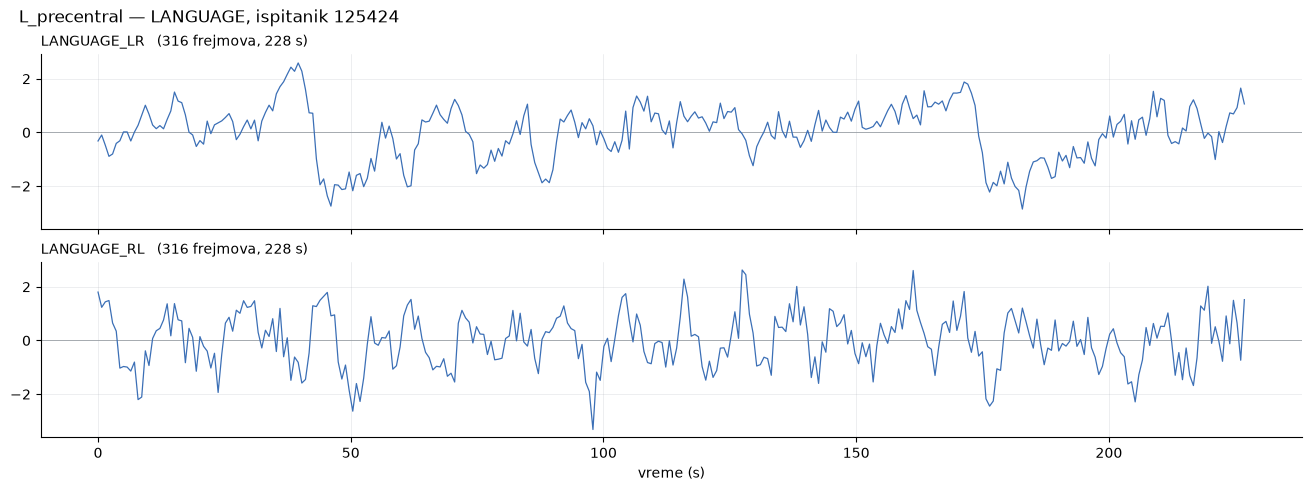

In [11]:
assert stem == f"tfMRI_{TASK}_{ENC}", "ponovo pokreni ćeliju A"

idx = np.flatnonzero((subjects == SUBJECT) & (y == TASK))        # LR i RL
fig, axes = plt.subplots(len(idx), 1, figsize=(13, 2.4 * len(idx)),
                         sharex=True, sharey=True, squeeze=False, layout="constrained")
for ax, i in zip(axes.flat, idx):
    sig = runs[i][:, REGION]
    sig = (sig - sig.mean()) / sig.std()
    ax.plot(np.arange(len(sig)) * TR, sig, lw=0.9, color=ACCENT)
    ax.set_title(f"{y[i]}_{encodings[i]}   ({len(sig)} frejmova, {len(sig) * TR:.0f} s)")
    ax.axhline(0, lw=0.6, color=MUTED, zorder=0)
axes.flat[-1].set_xlabel("vreme (s)")
fig.suptitle(f"{REGION_NAME} — {TASK}, ispitanik {SUBJECT}", x=0.01, ha="left")

Mapa kontrasta između dva uslova, preko preseka mozga.

/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


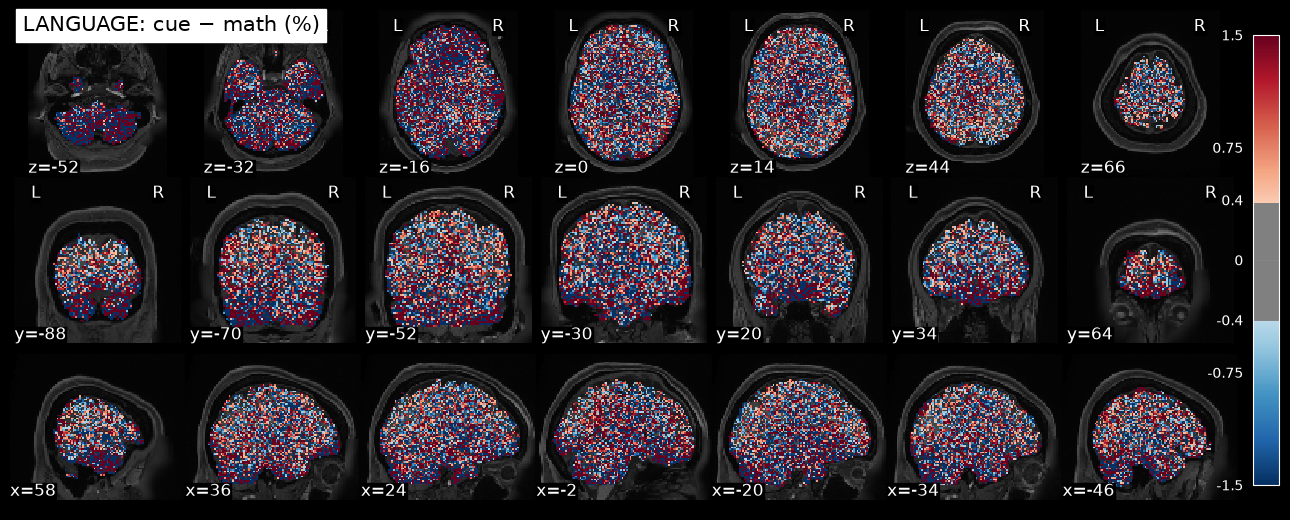

In [12]:
img4   = nib.load(str(run / f"{stem}_hp0_clean_rclean_tclean.nii.gz"))
vol    = img4.get_fdata(dtype=np.float32)                   # (91,109,91,nt), ~1 GB
mean3d = nib.load(str(run / f"{stem}_mean.nii.gz")).get_fdata()

diff3d     = vol[..., cond_frames[COND_A]].mean(-1) - vol[..., cond_frames[COND_B]].mean(-1)
contrast3d = np.where(mean3d > 0, diff3d / np.maximum(mean3d, 1) * 100, 0)
stat       = nib.Nifti1Image(contrast3d.astype(np.float32), img4.affine)

anat = ROOT / "data" / SUBJECT / "MNINonLinear/T1w_restore.2.nii.gz"
ttl  = f"{TASK}: {COND_A} − {COND_B} (%)"

plotting.plot_stat_map(stat, bg_img=str(anat), threshold=0.4, vmax=1.5,
                       display_mode="mosaic", title=ttl)


**Kako se čita.** Boja je razlika u procentima signala između dva uslova, crveno pozitivna, plavo negativna. Prikazuju se samo vokseli iznad zadatog praga. Naslov ima oblik `ZADATAK: uslov_A − uslov_B (%)`.

Toplotna mapa svih 87 regiona kroz vreme, razdvojena po hemisferama.

Text(0.01, 0.98, '125424 — tfMRI_LANGUAGE_LR, z-score po regionu')

/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)


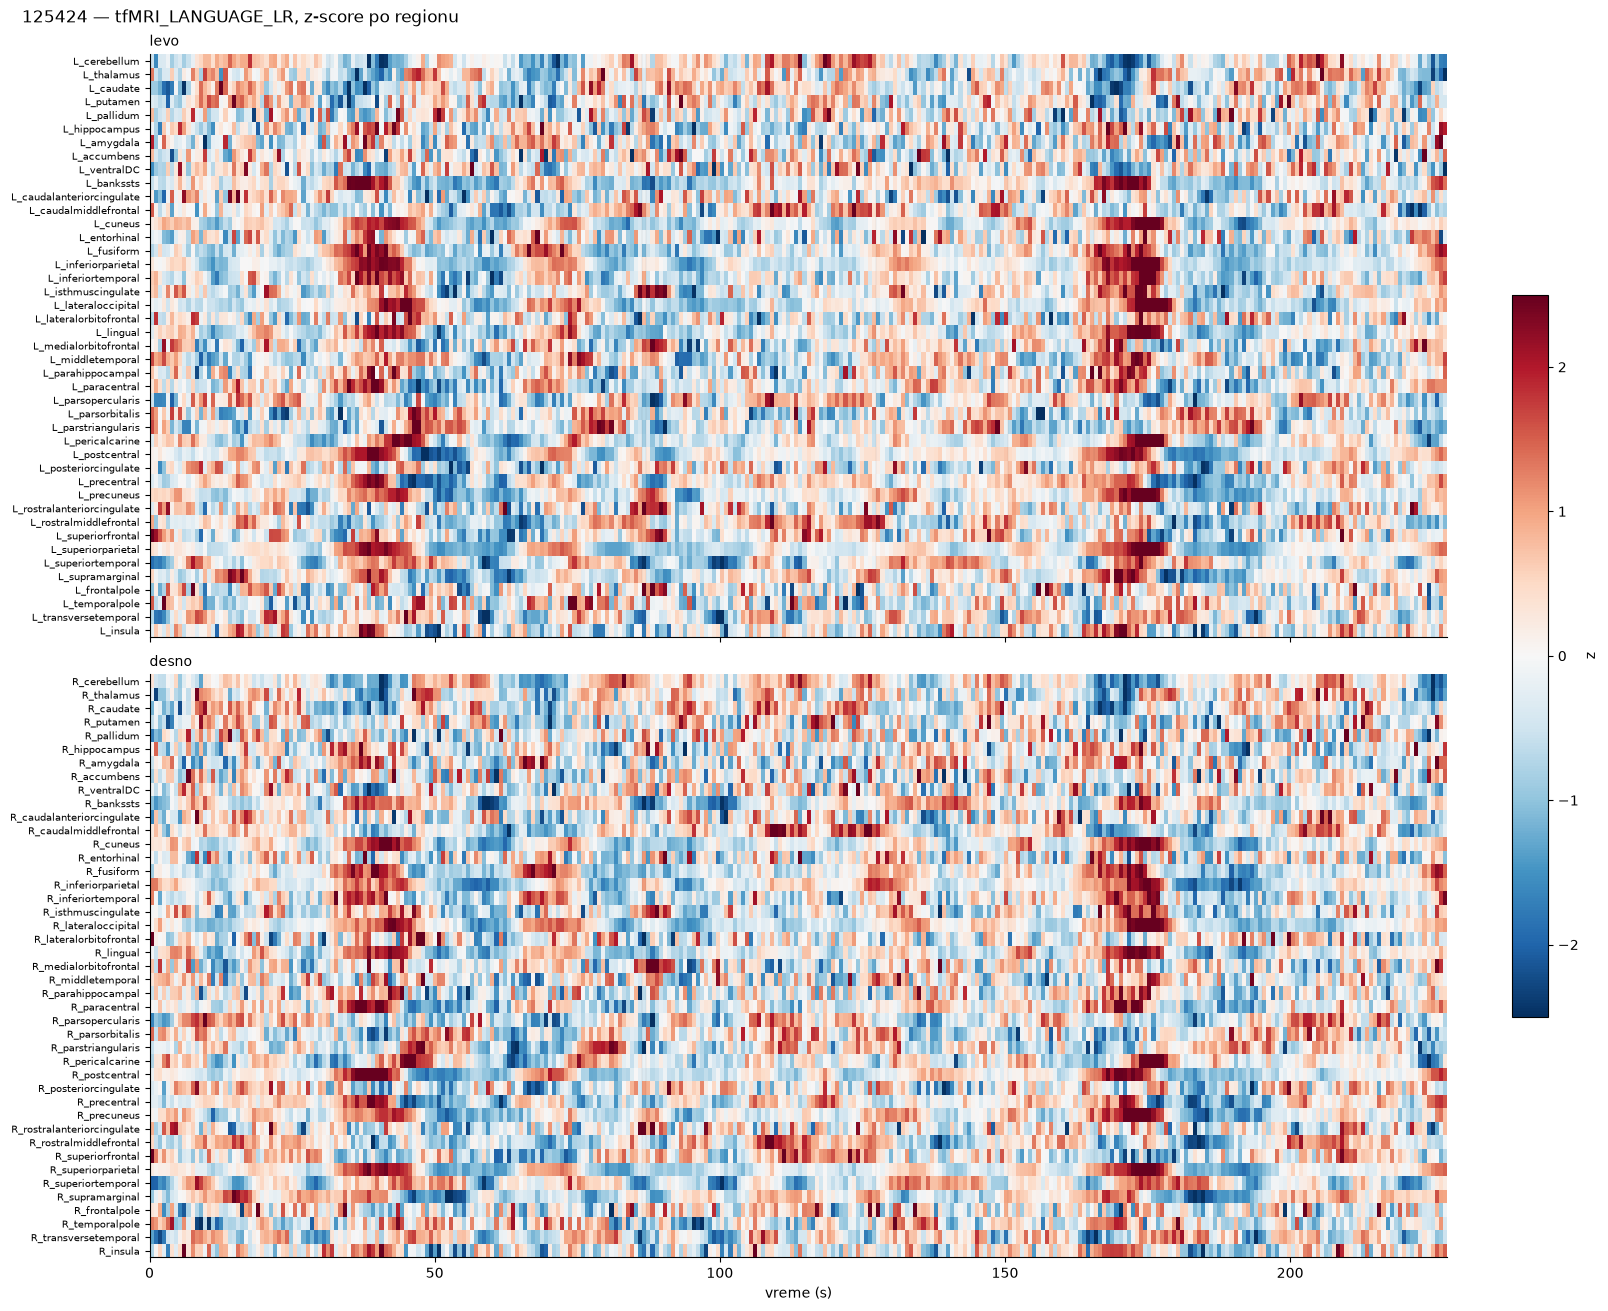

In [13]:
i = np.flatnonzero((subjects == SUBJECT) & (y == TASK) & (encodings == ENC))[0]
Z = runs[i]
Z = ((Z - Z.mean(0)) / np.where(Z.std(0) > 0, Z.std(0), 1)).T          # (87, T), redosled = names

LEFT = [k for k, n in enumerate(names) if n.startswith("L_")]
RIGHT = [k for k, n in enumerate(names) if n.startswith("R_")]

fig, axes = plt.subplots(2, 1, figsize=(16, 13), sharex=True, layout="constrained")
for ax, idx, side in [(axes[0], LEFT, "levo"), (axes[1], RIGHT, "desno")]:
    im = ax.imshow(Z[idx], aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5,
                   extent=[0, Z.shape[1] * TR, len(idx), 0], interpolation="nearest")
    ax.set_yticks(np.arange(len(idx)) + 0.5)
    ax.set_yticklabels([names[k] for k in idx], fontsize=7)
    ax.set_xlabel("vreme (s)")
    ax.set_title(side)
    ax.grid(False)
    axes[0].set_xlabel("")          # samo donji panel nosi oznaku
    for f in cond_frames[COND_A]:
        ax.axvline(f * TR, color="k", lw=0.3, alpha=0.15)
fig.colorbar(im, ax=axes, shrink=0.6, label="z")
fig.suptitle(f"{SUBJECT} — {stem}, z-score po regionu", x=0.01, ha="left")

Poredi signal pojedinačnog voksela sa prosekom celog regiona.

Text(0.01, 0.98, '125424 — tfMRI_LANGUAGE_LR')

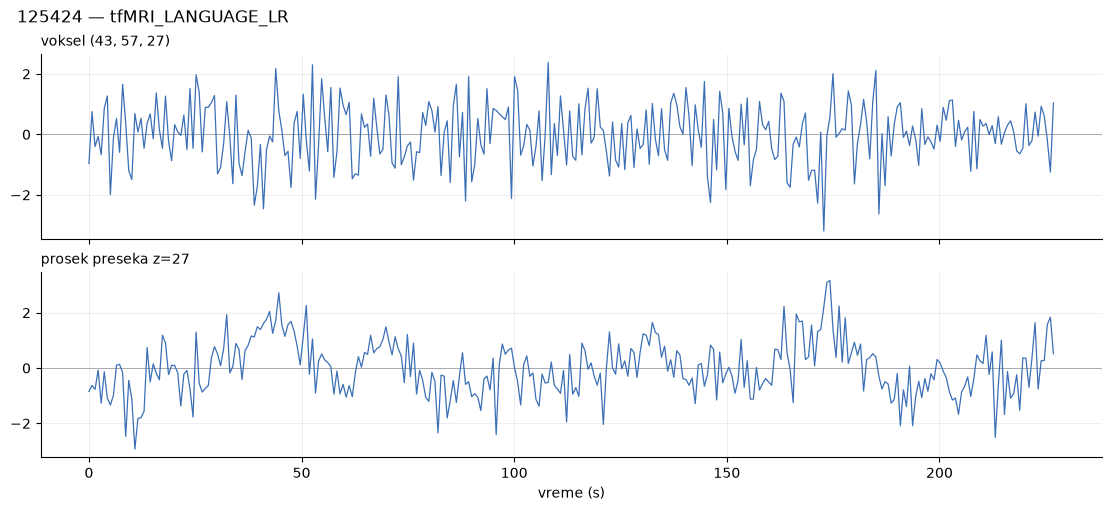

In [14]:
assert stem == f"tfMRI_{TASK}_{ENC}", "ponovo pokreni ćeliju A"

sd = sl.std(axis=-1)
vx, vy = np.unravel_index(np.argmax(np.where(mask, sd, 0)), sd.shape)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for ax, sig, title in [(axes[0], sl[vx, vy, :], f"voksel ({vx}, {vy}, {CZ})"),
                       (axes[1], sl[mask].mean(axis=0), f"prosek preseka z={CZ}")]:
    ax.plot(t, (sig - sig.mean()) / sig.std(), lw=0.9, color=ACCENT)
    ax.set_title(title)
    ax.axhline(0, lw=0.6, color=MUTED, zorder=0)
axes[-1].set_xlabel("vreme (s)")
fig.suptitle(f"{SUBJECT} — {stem}", x=0.01, ha="left")

Spektri po zadatku za izabrani region, sa ucrtanim granicama diadskih opsega.

Text(0.01, 0.98, 'Spektar po zadatku — L_precentral (sivo = prosek svih)')

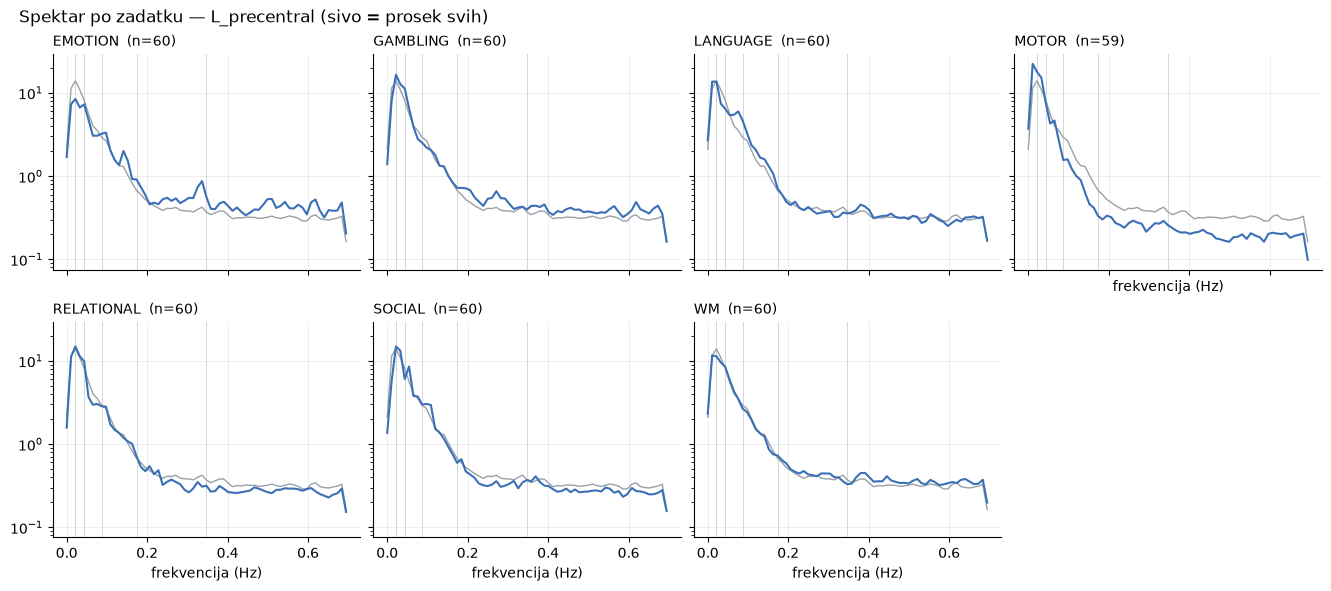

In [15]:
NPERSEG = 128
FS, NYQ = 1 / TR, 1 / (2 * TR)

psd = {}
for task in TASKS:
    acc = []
    for i in np.flatnonzero(y == task):
        sig = runs[i][:, REGION]
        f, p = welch((sig - sig.mean()) / sig.std(), fs=FS, nperseg=NPERSEG)
        acc.append(p)
    psd[task] = np.mean(acc, axis=0)
grand = np.mean(list(psd.values()), axis=0)

NR = -(-len(TASKS) // NCOLS)
fig, axes = plt.subplots(NR, NCOLS, figsize=(3.3 * NCOLS, 2.9 * NR),
                         sharex=True, sharey=True)
for ax, task in zip(axes.flat, TASKS):
    for l in range(1, 6):
        ax.axvline(NYQ / 2 ** l, lw=0.5, color=MUTED, alpha=0.6, zorder=0)
    ax.semilogy(f, grand, lw=1.0, color=MUTED, zorder=1)
    ax.semilogy(f, psd[task], lw=1.5, color=ACCENT, zorder=2)
    ax.set_title(f"{task}  (n={np.sum(y == task)})")
for j, ax in enumerate(axes.flat):
    if j >= len(TASKS):
        ax.set_visible(False)
    elif j + NCOLS >= len(TASKS):
        ax.set_xlabel("frekvencija (Hz)")
fig.suptitle(f"Spektar po zadatku — {REGION_NAME} (sivo = prosek svih)", x=0.01, ha="left")

**Kako se čita.** Svaki panel je jedan zadatak, a `n` u naslovu je broj run-ova te klase. Plava kriva je spektar tog zadatka, siva prosek svih zadataka. Uspravne sive linije su granice diadskih opsega. Osa snage je logaritamska.

EMD razlaganje reprezentativnog signala i trenutna učestanost svakog moda.

7 IMF-ova, udeo energije po modu: [0.071 0.187 0.182 0.193 0.192 0.072 0.001]


Text(0.01, 0.98, 'EMD razlaganje — L_precentral')

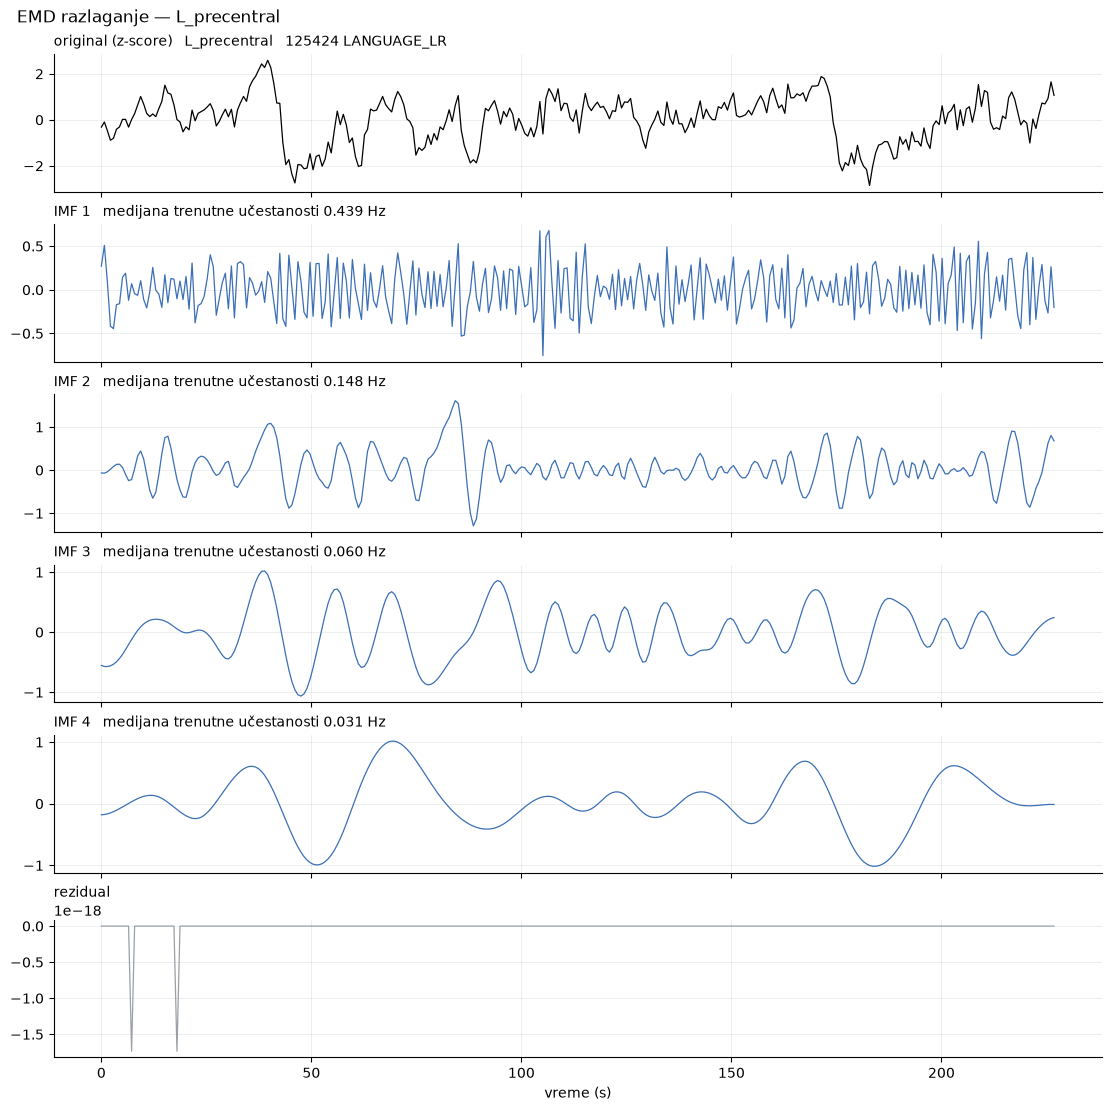

In [16]:
# EMD ne pretpostavlja bazu: signal se razlaže na sopstvene oscilatorne modove, pa je to treća
# dekompozicija uz Velča i DWT. Hilbertova transformacija svakom modu daje trenutnu učestanost,
# što DWT podopseg ne može jer su mu granice unapred fiksirane. Traži paket EMD-signal.
run_ix = np.flatnonzero((subjects == SUBJECT) & (y == TASK) & (encodings == ENC))[0]
sig    = runs[run_ix][:, REGION].astype(np.float64)
sig    = (sig - sig.mean()) / sig.std()
t      = np.arange(len(sig)) * TR

imf   = _EMD().emd(sig)
resid = sig - imf.sum(0)
NIMF  = min(4, len(imf))                                     # prikazuju se prva četiri moda
print(f"{len(imf)} IMF-ova, udeo energije po modu: "
      f"{np.round([(c ** 2).sum() / (sig ** 2).sum() for c in imf], 3)}")

fig, axes = plt.subplots(NIMF + 2, 1, figsize=(11, 2 + 1.5 * (NIMF + 2)), sharex=True)
axes[0].plot(t, sig, lw=0.9, color="k")
axes[0].set_title(f"original (z-score)   {names[REGION]}   {SUBJECT} {TASK}_{ENC}")
for k, (ax, c) in enumerate(zip(axes[1:], imf[:NIMF]), start=1):
    fi = np.diff(np.unwrap(np.angle(_hilbert(c)))) / (2 * np.pi * TR)
    ax.plot(t, c, lw=0.9, color=ACCENT)
    ax.set_title(f"IMF {k}   medijana trenutne učestanosti {np.median(fi):.3f} Hz")
axes[-1].plot(t, resid, lw=0.9, color=MUTED)
axes[-1].set_title("rezidual")
axes[-1].set_xlabel("vreme (s)")
fig.suptitle(f"EMD razlaganje — {REGION_NAME}", x=0.01, ha="left")

**Kako se čita.** Ispod originala je po jedan panel za prva četiri IMF-a, u naslovu sa medijanom trenutne učestanosti iz Hilbertove transformacije, a na dnu rezidual. Ispis daje udeo energije po modu. Za razliku od DWT podopsega, granice modova nisu unapred zadate nego ih određuje sam signal, pa se njihove učestanosti mogu porediti sa opsezima iz tabele podopsega.

## Prozori i podela

Deli runove na prozore fiksne dužine i pravi podelu na train, validacioni i test skup po ispitanicima.

In [17]:
WIN, STRIDE = 176, 88                      # 176 = najkraći run; 50% preklapanja
N_TRAIN, N_VAL, N_TEST, SEED = 18, 6, 6, 0
assert N_TRAIN + N_VAL + N_TEST == len(SUBJECTS), \
    f"podela pokriva {N_TRAIN + N_VAL + N_TEST}, a ima {len(SUBJECTS)} ispitanika"

Xw, yw, gw, srcw = prozori(runs, WIN, STRIDE)              # (1077, 176, 87)

perm = np.random.default_rng(SEED).permutation(np.array(SUBJECTS))
SUBJ = {"train": sorted(perm[:N_TRAIN]),
        "val":   sorted(perm[N_TRAIN:N_TRAIN + N_VAL]),
        "test":  sorted(perm[N_TRAIN + N_VAL:])}
IDX  = {k: np.flatnonzero(np.isin(gw, s)) for k, s in SUBJ.items()}

LOSO      = loso(gw)
LOSO_SUBJ = [gw[te][0] for _, te in LOSO]

assert sum(len(v) for v in IDX.values()) == len(Xw)
print(f"prozora: {len(Xw)}  oblik {Xw.shape}")
for k in ("train", "val", "test"):
    print(f"  {k:5s} {list(SUBJ[k])} -> {len(IDX[k]):3d}")
print(f"LOSO: {len(LOSO)} foldova")
# Run-ovi različite dužine daju različit broj prozora, pa skup nije uravnotežen:
# trivijalna granica je većinska klasa, ne 1/7.
CNT    = collections.Counter(yw)
CHANCE = max(CNT.values()) / len(yw)
print("prozora po klasi:", dict(sorted(CNT.items(), key=lambda t: -t[1])))
print(f"uniformno pogađanje {1 / len(CNT):.3f}   većinska klasa {CHANCE:.3f}")

prozora: 1077  oblik (1077, 176, 87)
  train [np.str_('111211'), np.str_('125424'), np.str_('130518'), np.str_('135124'), np.str_('146735'), np.str_('153126'), np.str_('176845'), np.str_('180230'), np.str_('186848'), np.str_('213017'), np.str_('257946'), np.str_('274542'), np.str_('378756'), np.str_('510225'), np.str_('590047'), np.str_('692964'), np.str_('869472'), np.str_('911849')] -> 648
  val   [np.str_('137532'), np.str_('151930'), np.str_('192237'), np.str_('199352'), np.str_('227533'), np.str_('300719')] -> 213
  test  [np.str_('118831'), np.str_('165436'), np.str_('206525'), np.str_('392447'), np.str_('519647'), np.str_('698168')] -> 216
LOSO: 30 foldova
prozora po klasi: {np.str_('WM'): 240, np.str_('LANGUAGE'): 180, np.str_('SOCIAL'): 180, np.str_('MOTOR'): 177, np.str_('GAMBLING'): 120, np.str_('RELATIONAL'): 120, np.str_('EMOTION'): 60}
uniformno pogađanje 0.143   većinska klasa 0.223


**Kako se čita.** Prvi red je oblik skupa: broj prozora × frejmova × regiona. Redovi `train`, `val` i `test` navode ispitanike u svakom skupu i broj prozora koji oni nose. `LOSO` je broj foldova. Poslednja dva reda daju broj prozora po klasi i dve trivijalne granice: uniformno pogađanje i većinsku klasu.

## Obeležja

Welch-ov spektar prozora i granice pet diadskih opsega.

In [18]:
FS = 1 / TR
f, P = welch(Xw, fs=FS, nperseg=WIN, axis=1)          # (n, nf, 87)
p = P / P.sum(axis=1, keepdims=True)                  # relativna snaga
NLEV = 4                                    # isti broj nivoa kao DWT
NYQ  = 1 / (2 * TR)
edges = [f[1]] + [NYQ / 2 ** k for k in range(NLEV, 0, -1)] + [NYQ]
BANDS = list(zip(edges[:-1], edges[1:]))
BAND_NAMES = [f"A{NLEV}"] + [f"D{k}" for k in range(NLEV, 0, -1)]

for nm, (lo, hi) in zip(BAND_NAMES, BANDS):
    print(f"  {nm:3s}  {lo:.4f}–{hi:.4f} Hz")

  A4   0.0079–0.0434 Hz
  D4   0.0434–0.0868 Hz
  D3   0.0868–0.1736 Hz
  D2   0.1736–0.3472 Hz
  D1   0.3472–0.6944 Hz


**Kako se čita.** Levo je oznaka opsega, desno njegov frekvencijski raspon u hercima. `A4` je aproksimacioni deo, `D1` do `D4` detaljni, redom od najbržeg ka sporijem.

Gradi standardni skup obeležja (skup A): snaga po opsezima, entropija, težište i autokorelacije.

In [19]:
F_std, blocks = standardna_obelezja(Xw, blokovi=True)

BLOCK_NAMES = [f"band_{nm}" for nm in BAND_NAMES] + ["entropy", "centroid", "ac1", "ac5"]
FEAT_NAMES  = [f"{b}:{r}" for b in BLOCK_NAMES for r in names]

print(f"F_std: {F_std.shape}  ({len(BLOCK_NAMES)} tipa × {len(names)} regiona)")
print(f"NaN/inf: {(~np.isfinite(F_std)).sum()}")

F_std: (1077, 783)  (9 tipa × 87 regiona)
NaN/inf: 0


DWT razlaganje prozora i frekvencijski opseg svakog podopsega.

In [20]:
WAVELET = "db4"                       # ili "sym4"
L   = pywt.dwt_max_level(WIN, pywt.Wavelet(WAVELET).dec_len)
NYQ = 1 / (2 * TR)

coeffs = pywt.wavedec(Xw, WAVELET, level=L, axis=1)      # [cA_L, cD_L, ..., cD_1]
SUB    = [f"A{L}"] + [f"D{k}" for k in range(L, 0, -1)]

print(f"{WAVELET}, L = {L}   (filtar {pywt.Wavelet(WAVELET).dec_len} koef., prozor {WIN})")
for s, c in zip(SUB, coeffs):
    lo, hi = opseg(s)
    print(f"  {s:3s}  {c.shape[1]:3d} koeficijenata   {lo:.3f}–{hi:.3f} Hz")

db4, L = 4   (filtar 8 koef., prozor 176)
  A4    17 koeficijenata   0.000–0.043 Hz
  D4    17 koeficijenata   0.043–0.087 Hz
  D3    28 koeficijenata   0.087–0.174 Hz
  D2    49 koeficijenata   0.174–0.347 Hz
  D1    91 koeficijenata   0.347–0.694 Hz


**Kako se čita.** Prvi red daje talasić, broj nivoa `L` i dužinu filtra u koeficijentima. Zatim po jedan red za svaki podopseg: broj koeficijenata i frekvencijski opseg koji pokriva.

Oblik talasića i frekvencijski odziv filtarske banke, kao obrazloženje izbora `db4`.

  haar   dec_len  2   preklapanje H i G 0.363
  db4    dec_len  8   preklapanje H i G 0.181
  sym8   dec_len 16   preklapanje H i G 0.128


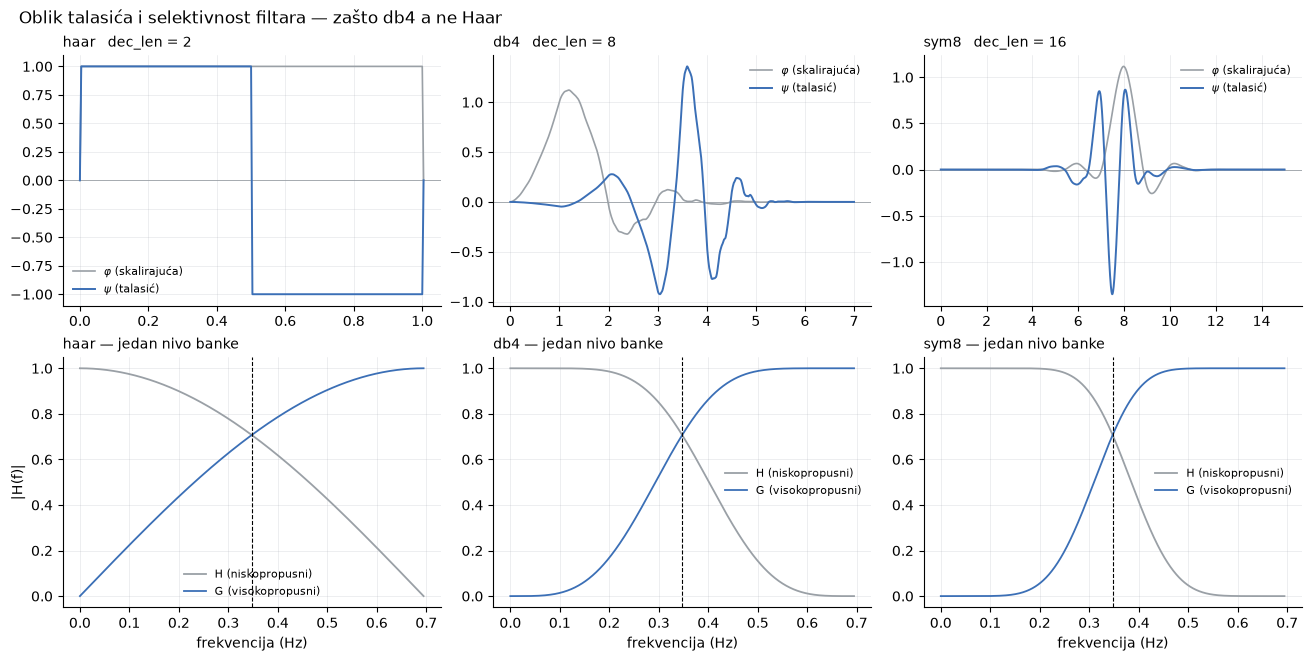

In [21]:
# Izbor db4 do sada stoji samo kao tekst. Talasić se bira po dva svojstva: koliko je glatka
# osnovna funkcija i koliko oštro banka razdvaja susedne podopsege. Haar je najkraći filtar i
# najslabije razdvaja, sym8 najduži, db4 je kompromis — isti onaj koji koristi i rad [01].
WAVS = ("haar", WAVELET, "sym8")
NFFT = 2048
fax  = np.fft.rfftfreq(NFFT, d=TR)

fig, axes = plt.subplots(2, len(WAVS), figsize=(13, 6.5))
for ax, wav in zip(axes[0], WAVS):
    phi, psi, xax = pywt.Wavelet(wav).wavefun(level=8)
    ax.plot(xax, phi, lw=1.2, color=MUTED,  label=r"$\varphi$ (skalirajuća)")
    ax.plot(xax, psi, lw=1.4, color=ACCENT, label=r"$\psi$ (talasić)")
    ax.axhline(0, lw=0.6, color=MUTED, zorder=0)
    ax.set_title(f"{wav}   dec_len = {pywt.Wavelet(wav).dec_len}")
    ax.legend(fontsize=8, frameon=False)

for ax, wav in zip(axes[1], WAVS):
    lo = np.abs(np.fft.rfft(pywt.Wavelet(wav).dec_lo, NFFT)) / np.sqrt(2)
    hi = np.abs(np.fft.rfft(pywt.Wavelet(wav).dec_hi, NFFT)) / np.sqrt(2)
    ax.plot(fax, lo, lw=1.3, color=MUTED,  label="H (niskopropusni)")
    ax.plot(fax, hi, lw=1.3, color=ACCENT, label="G (visokopropusni)")
    ax.axvline(NYQ / 2, lw=0.8, ls="--", color="k")
    ax.set_title(f"{wav} — jedan nivo banke")
    ax.set_xlabel("frekvencija (Hz)")
    ax.legend(fontsize=8, frameon=False)
axes[1, 0].set_ylabel("|H(f)|")
fig.suptitle("Oblik talasića i selektivnost filtara — zašto db4 a ne Haar", x=0.01, ha="left")

# Preklapanje je udeo energije koji oba filtra propuštaju; manje znači čistiju podelu opsega.
for wav in WAVS:
    lo = np.abs(np.fft.rfft(pywt.Wavelet(wav).dec_lo, NFFT)) ** 2 / 2
    hi = np.abs(np.fft.rfft(pywt.Wavelet(wav).dec_hi, NFFT)) ** 2 / 2
    print(f"  {wav:5s}  dec_len {pywt.Wavelet(wav).dec_len:2d}   "
          f"preklapanje H i G {np.trapezoid(np.minimum(lo, hi)) / np.trapezoid(lo):.3f}")

**Kako se čita.** Gornji red su skalirajuća funkcija φ i talasić ψ svake familije, uz `dec_len`, dužinu filtra u koeficijentima. Donji red je frekvencijski odziv jednog nivoa banke: `H` propušta donju polovinu opsega, `G` gornju, a isprekidano je granica na `NYQ/2`. Ispis daje preklapanje ta dva filtra, dakle udeo energije koji oba propuštaju — manja vrednost znači čistiju podelu na podopsege.

Gradi DWT obeležja — relativnu energiju i entropiju koeficijenata — i spaja ih sa standardnim skupom u skup B.

In [22]:
rel, ent = dwt_blokovi(coeffs)

F_dwt     = np.concatenate(rel + ent, axis=1).astype(np.float32)
DWT_NAMES = [f"{p}_{s}:{r}" for p in ("E", "H") for s in SUB for r in names]
F_all     = np.concatenate([F_std, F_dwt], axis=1)
ALL_NAMES = FEAT_NAMES + DWT_NAMES

print(f"standardna {F_std.shape}   DWT {F_dwt.shape}   zajedno {F_all.shape}")
print(f"NaN/inf: {(~np.isfinite(F_dwt)).sum()}")

standardna (1077, 783)   DWT (1077, 870)   zajedno (1077, 1653)
NaN/inf: 0


Prikazuje razlaganje jednog prozora na podopsege, sa udelom energije po svakom.

Text(0.01, 0.98, 'Razlaganje talasićima (db4, L = 4)')

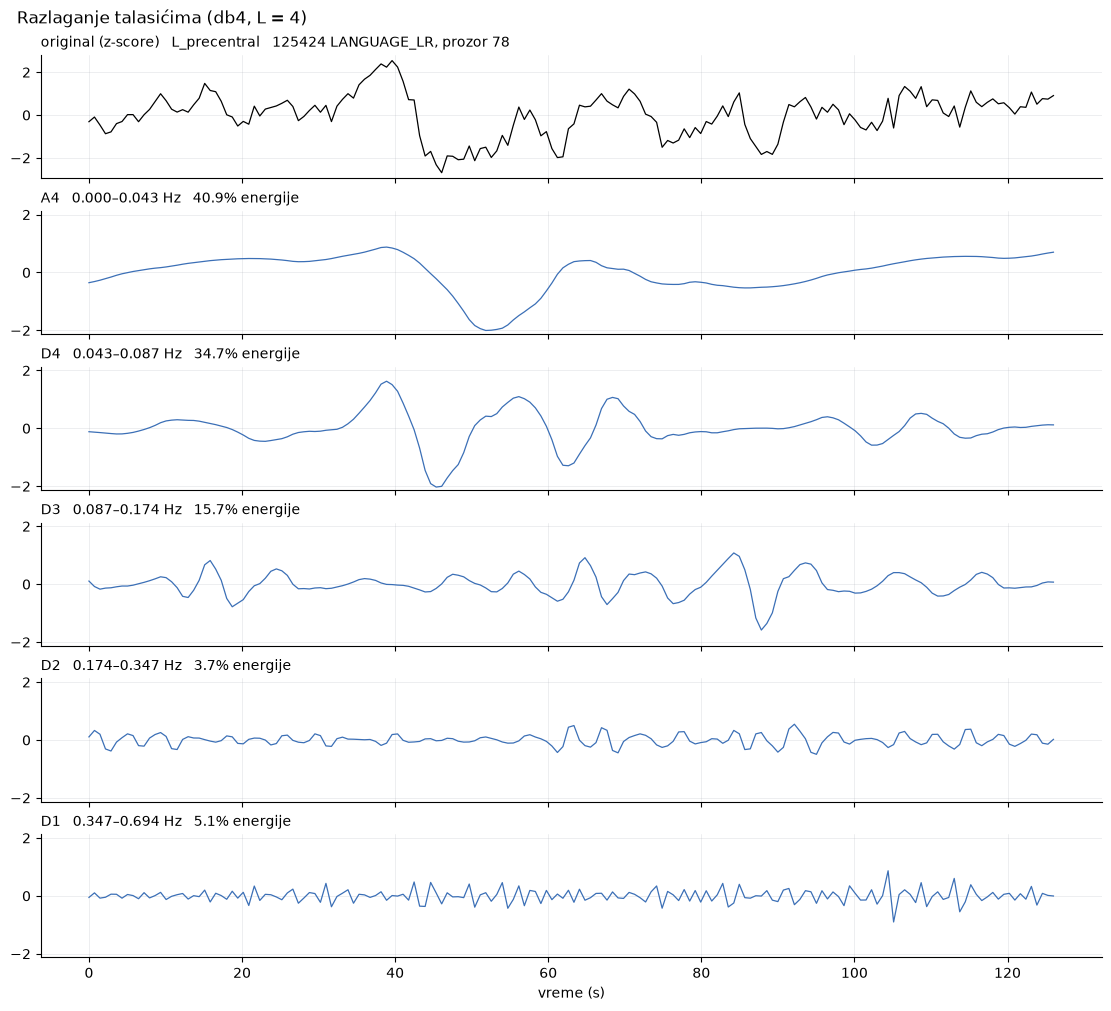

In [23]:
run_i = np.flatnonzero((subjects == SUBJECT) & (y == TASK) & (encodings == ENC))[0]
i0    = int(np.flatnonzero(srcw[:, 0] == run_i)[0])
sig   = Xw[i0, :, REGION]

c, parts = pywt.wavedec(sig, WAVELET, level=L), {}
for k, s in enumerate(SUB):                       # SUB = [A4, D4, D3, D2, D1]
    z = [ci if j == k else np.zeros_like(ci) for j, ci in enumerate(c)]
    parts[s] = pywt.waverec(z, WAVELET)[:WIN]

tot  = sum((parts[s] ** 2).sum() for s in SUB)
ylim = 1.05 * max(np.abs(parts[s]).max() for s in SUB)
t_w  = np.arange(WIN) * TR

fig, axes = plt.subplots(len(SUB) + 1, 1, figsize=(11, 10), sharex=True)
axes[0].plot(t_w, sig, color="k", lw=0.9)
axes[0].set_title(f"original (z-score)   {names[REGION]}   {SUBJECT} {TASK}_{ENC}, prozor {i0}")
for ax, s in zip(axes[1:], SUB):
    lo, hi = opseg(s)
    ax.plot(t_w, parts[s], color=ACCENT, lw=0.9)
    ax.set_ylim(-ylim, ylim)
    ax.set_title(f"{s}   {lo:.3f}–{hi:.3f} Hz   {(parts[s] ** 2).sum() / tot:.1%} energije")
axes[-1].set_xlabel("vreme (s)")
fig.suptitle(f"Razlaganje talasićima ({WAVELET}, L = {L})", x=0.01, ha="left")

**Kako se čita.** Gornji panel je originalni prozor, ispod je po jedan panel za svaki podopseg. U naslovu svakog stoji njegov frekvencijski opseg i udeo u ukupnoj energiji. Svi podopsezi dele istu y-skalu, pa se amplitude porede neposredno.

Spektrogram i skalogram istog signala, sa ucrtanim granicama DWT podopsega.

Text(0.01, 0.98, 'Vremensko-frekvencijski prikaz — L_precentral')

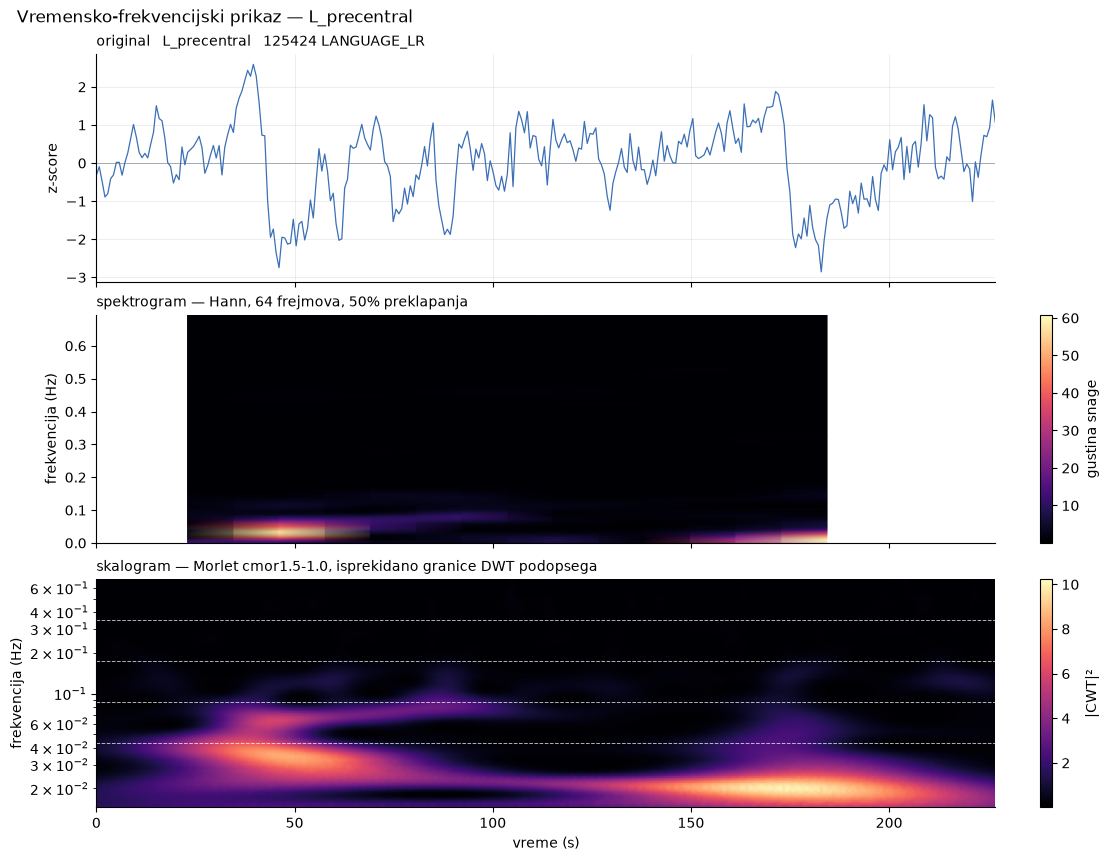

In [24]:
# Velčova ocena usrednjava spektar preko celog run-a, pa ne kaže kada se koja frekvencija
# javlja. Spektrogram i skalogram to razlažu po vremenu: prvi fiksnim prozorom, drugi prozorom
# koji se skalira sa frekvencijom. Bele linije su granice DWT podopsega, pa se na istoj slici
# vidi šta diadska podela zaista seče.
NSEG = 64                                        # 64 frejma = 46 s -> Δf = 0.022 Hz
SCAL = np.geomspace(2, 96, 96)                   # skale koje pokrivaju 0.02–0.6 Hz

run_ix = np.flatnonzero((subjects == SUBJECT) & (y == TASK) & (encodings == ENC))[0]
sig    = runs[run_ix][:, REGION].astype(np.float64)
sig    = (sig - sig.mean()) / sig.std()
t      = np.arange(len(sig)) * TR

f, tt, S = _spec(sig, fs=FS, nperseg=NSEG, noverlap=NSEG // 2, nfft=512,
                 window="hann", detrend=False)
cw, fw   = pywt.cwt(sig, SCAL, "cmor1.5-1.0", sampling_period=TR)

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)
axes[0].plot(t, sig, lw=0.9, color=ACCENT)
axes[0].axhline(0, lw=0.6, color=MUTED, zorder=0)
axes[0].set_ylabel("z-score")
axes[0].set_title(f"original   {names[REGION]}   {SUBJECT} {TASK}_{ENC}")

im = axes[1].pcolormesh(tt, f, S, shading="gouraud", cmap="magma")
axes[1].set_ylabel("frekvencija (Hz)")
axes[1].grid(False)
axes[1].set_title(f"spektrogram — Hann, {NSEG} frejmova, 50% preklapanja")
fig.colorbar(im, ax=axes[1], label="gustina snage")

im = axes[2].pcolormesh(t, fw, np.abs(cw) ** 2, shading="gouraud", cmap="magma")
for l in range(1, L + 1):                        # donje granice podopsega D_l
    axes[2].axhline(NYQ / 2 ** l, lw=0.7, ls="--", color="w", alpha=0.7)
axes[2].set_yscale("log")
axes[2].set_ylabel("frekvencija (Hz)")
axes[2].set_xlabel("vreme (s)")
axes[2].grid(False)
axes[2].set_title("skalogram — Morlet cmor1.5-1.0, isprekidano granice DWT podopsega")
fig.colorbar(im, ax=axes[2], label="|CWT|²")
fig.suptitle(f"Vremensko-frekvencijski prikaz — {REGION_NAME}", x=0.01, ha="left")

**Kako se čita.** Gornji panel je originalni signal u z-score-u. Srednji je spektrogram: fiksni Hann prozor od 64 frejma daje rezoluciju 0.022 Hz i istu vremensku podelu na celom opsegu. Donji je skalogram, gde se prozor skalira sa frekvencijom, pa su spore komponente bolje razlučene po frekvenciji a brze po vremenu. Bele isprekidane linije su donje granice podopsega `D_l`, iste one koje koristi DWT.

## Obrada signala

Meri koliko varijanse nose linearni trend i globalni signal; priprema visokopropusni filtar.

udeo varijanse — linearni trend 0.000 ± 0.000   globalni signal 0.056 ± 0.018


Text(0.0, 1.0, 'Spektar pre i posle uklanjanja drifta (sive linije: granice opsega)')

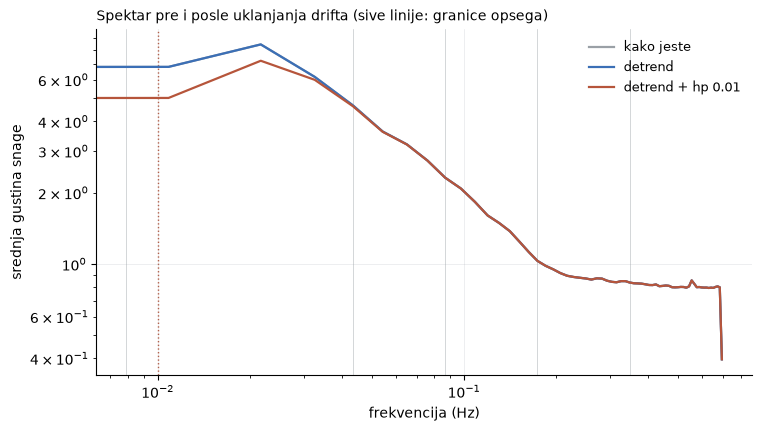

In [25]:
# Fajlovi su hp0_clean_rclean_tclean: hp0 znači da visokopropusni filtar 
# samo uklanjanja srednje vrednosti. Spori drift skenera ostaje dok
# pada u A4 opseg (0–0.043 Hz), isti onaj u kom su najdiskriminativnija 
# obeležja.
HP_HZ  = 0.01
bb, aa = butter(2, HP_HZ / (0.5 / TR), btype="highpass")

vd, vg = [], []
for rn in runs:
    z = rn.astype(np.float64) - rn.mean(0)
    vd.append(np.var(z - detrend(z, axis=0)) / np.var(z))
    vg.append(np.var(np.repeat(z.mean(1, keepdims=True), z.shape[1], 1)) / np.var(z))
print(f"udeo varijanse — linearni trend {np.mean(vd):.3f} ± {np.std(vd):.3f}   "
      f"globalni signal {np.mean(vg):.3f} ± {np.std(vg):.3f}")

acc = {"kako jeste": [], "detrend": [], f"detrend + hp {HP_HZ}": []}
for rn in runs:
    z  = rn.astype(np.float64) - rn.mean(0)
    sd = np.maximum(z.std(0), 1e-9)                     # ista normalizacija za sve tri
    zd = detrend(z, axis=0)
    for k, zz in (("kako jeste", z), ("detrend", zd),
                  (f"detrend + hp {HP_HZ}", filtfilt(bb, aa, zd, axis=0))):
        fp, PP = welch(zz / sd, fs=1 / TR, nperseg=128, axis=0)
        acc[k].append(PP.mean(1))

fig, ax = plt.subplots(figsize=(7.5, 4.2), layout="constrained")
for (k, v), col in zip(acc.items(), (MUTED, ACCENT, "#b6553b")):
    ax.loglog(fp, np.mean(v, axis=0), lw=1.6, color=col, label=k)
for lo, hi in BANDS:
    ax.axvline(lo, lw=0.5, color=MUTED, alpha=0.6, zorder=0)
ax.axvline(HP_HZ, lw=1, color="#b6553b", ls=":", zorder=0)
ax.set_xlabel("frekvencija (Hz)"); ax.set_ylabel("srednja gustina snage")
ax.legend(frameon=False, fontsize=9)
ax.set_title("Spektar pre i posle uklanjanja drifta (sive linije: granice opsega)")

**Kako se čita.** Dva broja su udeo ukupne varijanse koji objašnjava linearni trend i udeo koji objašnjava globalni signal, dati kao prosek ± rasipanje po runovima. Figura poredi srednju spektralnu gustinu pre i posle obrade; tačkasta linija je prag filtra.

Ablacija koraka obrade signala: detrend, visokopropusni filtar i uklanjanje globalnog signala.

In [26]:
# Odluka se donosi po `val` koloni. LOSO kolona opisuje rasipanje po ispitanicima
VAR = {"0 kako jeste":        dict(trend=False, hp=None,  globalni=False),
       "1 detrend":           dict(trend=True,  hp=None,  globalni=False),
       "2 detrend + hp":      dict(trend=True,  hp=HP_HZ, globalni=False),
       "3 + globalni signal": dict(trend=True,  hp=HP_HZ, globalni=True),
       "4 samo globalni":     dict(trend=False, hp=None,  globalni=True)}

print(f"{'obrada':22s} {'val':>6s} {'LOSO (A standardna)':>21s}")
prep = {}
for tag, cfg in VAR.items():
    Xv, yv, gv, _ = prozori(obradi_runove(runs, **cfg), WIN, STRIDE)
    Fp = standardna_obelezja(Xv)
    a  = loso_tacnost(Fp, yv, loso(gv))
    v  = tacnost_na(Fp, "val", yv)
    prep[tag] = a
    print(f"{tag:22s} {v:6.3f} {a.mean():.3f} ± {a.std():.3f}", flush=True)

obrada                    val   LOSO (A standardna)
0 kako jeste            0.737 0.734 ± 0.210
1 detrend               0.737 0.734 ± 0.210
2 detrend + hp          0.761 0.771 ± 0.158
3 + globalni signal     0.751 0.747 ± 0.172
4 samo globalni         0.737 0.722 ± 0.224


**Kako se čita.** Levo je varijanta obrade. `val` je tačnost na validacionom skupu, `LOSO` prosek ± rasipanje preko svih foldova. Odluka se donosi po koloni `val`.

Uparena poređenja svake varijante obrade u odnosu na neobrađenog signala.

In [27]:
for tag in list(prep)[1:]:
    uparena_razlika(prep[tag], prep["0 kako jeste"], f"{tag} − kako jeste:",
                    zero_method="zsplit")

1 detrend − kako jeste:            +0.000 ± 0.000   pozitivnih 0/30   p=1.000
2 detrend + hp − kako jeste:       +0.038 ± 0.090   pozitivnih 15/30   p=0.109
3 + globalni signal − kako jeste:  +0.014 ± 0.110   pozitivnih 14/30   p=0.749
4 samo globalni − kako jeste:      -0.011 ± 0.062   pozitivnih 11/30   p=0.397


**Kako se čita.** Svaki red poredi jednu varijantu obrade sa neobrađenim signalom: prosečna razlika ± rasipanje, koliko je ispitanika u plusu od ukupnog broja, i p-vrednost Wilcoxonovog testa uparenih uzoraka. Pozitivna razlika znači da varijanta pomaže.

Pretraga praga visokopropusnog filtra, proverava da li najsporiji opseg nosi signal ili artefakt.

In [28]:
# Prag od 0.01 Hz je ispod frekvencijske rezolucije prozora (1/126.7 s = 0.0079 Hz), pa nije
# ni mogao da deluje. Ovde se prag podiže tako da zaista ubada u A4 opseg (0–0.043 Hz).
# Gleda se i tačnost i F-vrednost band_A4 obeležja: ako F padne a tačnost ostane,
# A4 je bio drift i ostala obeležja ga nadoknađuju; ako oba ostanu, A4 je neuralnog porekla.
print(f"{'prag':>7s} {'val':>6s} {'LOSO':>16s} {'F(band_A4)':>11s} {'udeo A4 snage':>14s}")
for hz in (None, 0.01, 0.02, 0.04, 0.08):
    Xv, yv, gv, _ = prozori(obradi_runove(runs, trend=True, hp=hz), WIN, STRIDE)
    Fp, bk = standardna_obelezja(Xv, blokovi=True)
    a = loso_tacnost(Fp, yv, loso(gv))
    v = tacnost_na(Fp, "val", yv)

    Fs_, _ = f_classif(Fp[IDX["train"]], yv[IDX["train"]])
    nA4 = bk[0].shape[1]                                   # band_A4 je prvi blok
    print(f"{str(hz):>7s} {v:6.3f} {a.mean():6.3f} ± {a.std():.3f} "
          f"{np.nan_to_num(Fs_)[:nA4].mean():11.1f} {bk[0].mean():14.4f}", flush=True)

   prag    val             LOSO  F(band_A4)  udeo A4 snage
   None  0.737  0.734 ± 0.210        22.7         0.2687
   0.01  0.761  0.771 ± 0.158        24.6         0.2408
   0.02  0.690  0.709 ± 0.179        22.8         0.1471
   0.04  0.624  0.581 ± 0.211        15.1         0.0310
   0.08  0.498  0.505 ± 0.220         8.6         0.0007


**Kako se čita.** `prag` je granica visokopropusnog filtra u hercima, `None` znači bez filtra. `F(band_A4)` je prosečna F-vrednost obeležja snage u najsporijem opsegu, a `udeo A4 snage` koliki deo ukupne snage taj opseg nosi.

Tvrdo i meko pragovanje DWT koeficijenata, pa ista klasifikacija nad pragovanim signalom.

In [29]:
# Uklanjanje šuma pragovanjem koeficijenata: univerzalni prag σ√(2 ln N), sa σ ocenjenim iz D1
# preko medijane apsolutnog odstupanja. Tvrdi prag briše sve ispod granice, meki sve skuplja ka
# nuli. Meri se i rekonstrukcija i posledica po tačnost, jer varijanta koja vernije rekonstruiše
# signal ne mora da bude bolja za klasifikaciju. Obeležja se grade istim postupkom kao u ćeliji sa
# DWT obeležjima, samo nad pragovanim koeficijentima, pa je poređenje sa `bez praga` uparivo po
# foldovima.
sigma = np.median(np.abs(coeffs[-1]), axis=1, keepdims=True) / 0.6745  # (n, 1, 87), po prozoru
prag  = sigma * np.sqrt(2 * np.log(WIN))

print(f"{'varijanta':10s} {'zadržano koeficijenata':>22s} {'RMS greška':>12s} {'LOSO (B)':>18s}")
thr_acc = {}
for kind in ("bez praga", "tvrdi", "meki"):
    if kind == "bez praga":
        cth = coeffs
    elif kind == "tvrdi":
        cth = [coeffs[0]] + [c * (np.abs(c) >= prag) for c in coeffs[1:]]
    else:
        cth = [coeffs[0]] + [np.sign(c) * np.maximum(np.abs(c) - prag, 0) for c in coeffs[1:]]

    Xr   = pywt.waverec(cth, WAVELET, axis=1)[:, :WIN, :].astype(np.float32)
    keep = np.mean([np.mean(c != 0) for c in cth[1:]])                 # aproksimacija se ne pragira
    rms  = float(np.sqrt(np.mean((Xr - Xw) ** 2)))

    rl, ha = dwt_blokovi(cth)
    Fk = np.concatenate([F_std] + rl + ha, axis=1).astype(np.float32)
    a  = loso_tacnost(Fk)
    thr_acc[kind] = a
    print(f"{kind:10s} {keep:21.1%} {rms:12.3f}   {a.mean():.3f} ± {a.std():.3f}")

print()
for kind in ("tvrdi", "meki"):
    uparena_razlika(thr_acc[kind], thr_acc["bez praga"], f"{kind} prag − bez praga:")

varijanta  zadržano koeficijenata   RMS greška           LOSO (B)
bez praga                 100.0%        0.000   0.750 ± 0.205
tvrdi                       5.9%        0.754   0.592 ± 0.189
meki                        5.9%        0.796   0.457 ± 0.137

tvrdi prag − bez praga:            -0.158 ± 0.099   pozitivnih 2/30   p=0.000
meki prag − bez praga:             -0.293 ± 0.143   pozitivnih 2/30   p=0.000


**Kako se čita.** `zadržano koeficijenata` je udeo detaljnih koeficijenata koji prežive prag, `RMS greška` rastojanje rekonstruisanog od originalnog prozora, a `LOSO (B)` tačnost skupa B izgrađenog nad pragovanim koeficijentima. Ispod su uparene razlike u odnosu na `bez praga`, po foldovima, sa Vilkoksonovom p-vrednošću. Univerzalni prag je na prozoru od 176 uzoraka vrlo agresivan; ako poseče gotovo sve koeficijente, sledeći korak je `prag / 2` ili izbor po `val` koloni.

## Analiza obeležja

PCA preko SVD: sopstvene vrednosti, kumulativna suma i projekcija prozora u dve dimenzije.

prve dve komponente nose 12.1% varijanse, za 90% treba 335 komponenti
  F-vrednost prve dve komponente za zadatak   [11.1 94.8]
  F-vrednost prve dve komponente za ispitanik [76.  16.2]


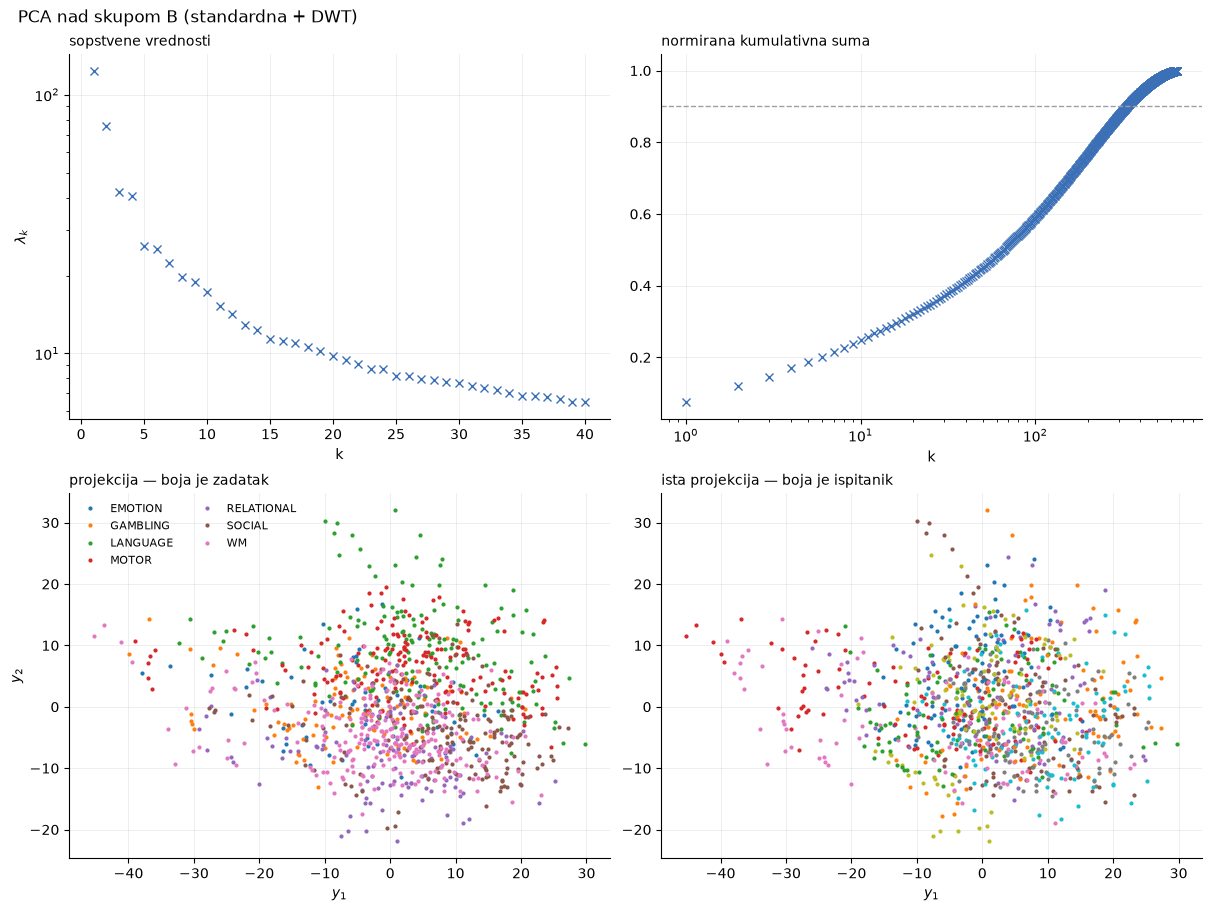

In [30]:
# PCA preko SVD nad centriranim i normiranim obeležjima: opservacije su prozori, obeležja skup B.
# Srednja vrednost, rasipanje i sopstveni vektori uče se isključivo na trening skupu, pa se
# projekcija primenjuje na sve prozore — inače bi interpretacija gledala val i test. Donji desni panel je ista projekcija obojena po ispitaniku: ako se prozori
# grupišu po ispitaniku a ne po zadatku, to je gornja granica onoga što LOSO može da postigne.
Y2, lam = pca_ose(F_all, 2)
cum     = np.cumsum(lam) / lam.sum()

print(f"prve dve komponente nose {cum[1]:.1%} varijanse, "
      f"za 90% treba {int(np.searchsorted(cum, 0.90) + 1)} komponenti")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].semilogy(np.arange(1, 41), lam[:40], "x", color=ACCENT)
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel(r"$\lambda_k$")
axes[0, 0].set_title("sopstvene vrednosti")

axes[0, 1].semilogx(np.arange(1, len(lam) + 1), cum, "x", color=ACCENT)
axes[0, 1].axhline(0.90, lw=1, ls="--", color=MUTED)
axes[0, 1].set_xlabel("k")
axes[0, 1].set_title("normirana kumulativna suma")

for task in TASKS:
    m = yw == task
    axes[1, 0].plot(Y2[m, 0], Y2[m, 1], ".", ms=4, label=task)
axes[1, 0].legend(fontsize=8, frameon=False, ncol=2)
axes[1, 0].set_xlabel("$y_1$")
axes[1, 0].set_ylabel("$y_2$")
axes[1, 0].set_title("projekcija — boja je zadatak")

for subject in SUBJECTS:
    m = gw == subject
    axes[1, 1].plot(Y2[m, 0], Y2[m, 1], ".", ms=4)
axes[1, 1].set_xlabel("$y_1$")
axes[1, 1].set_title("ista projekcija — boja je ispitanik")
fig.suptitle("PCA nad skupom B (standardna + DWT)", x=0.01, ha="left")

# Koliko prve dve komponente nose o zadatku, a koliko o ispitaniku.
for kind, v in (("zadatak", yw), ("ispitanik", gw)):
    Fpc, _ = f_classif(Y2[IDX["train"]], v[IDX["train"]])
    print(f"  F-vrednost prve dve komponente za {kind:9s} {np.round(Fpc, 1)}")

**Kako se čita.** Gore levo su sopstvene vrednosti kovarijacione matrice u logaritamskoj skali, gore desno njihova normirana kumulativna suma sa linijom na 90%. Dole je jedna te ista projekcija dvaput, obojena po zadatku i po ispitaniku. Ispis daje F-vrednost prve dve komponente za oba, pa se vidi šta one zapravo kodiraju.

LDA po definiciji: matrice rasipanja unutar i između klasa i uopšteni sopstveni problem.

6 netrivijalnih pravaca, prva dva nose 62.9% razdvojivosti;  uslovljenost S_w 35.0


Text(0.01, 0.98, 'LDA nad skupom B (posle PCA na 60 komponenti)')

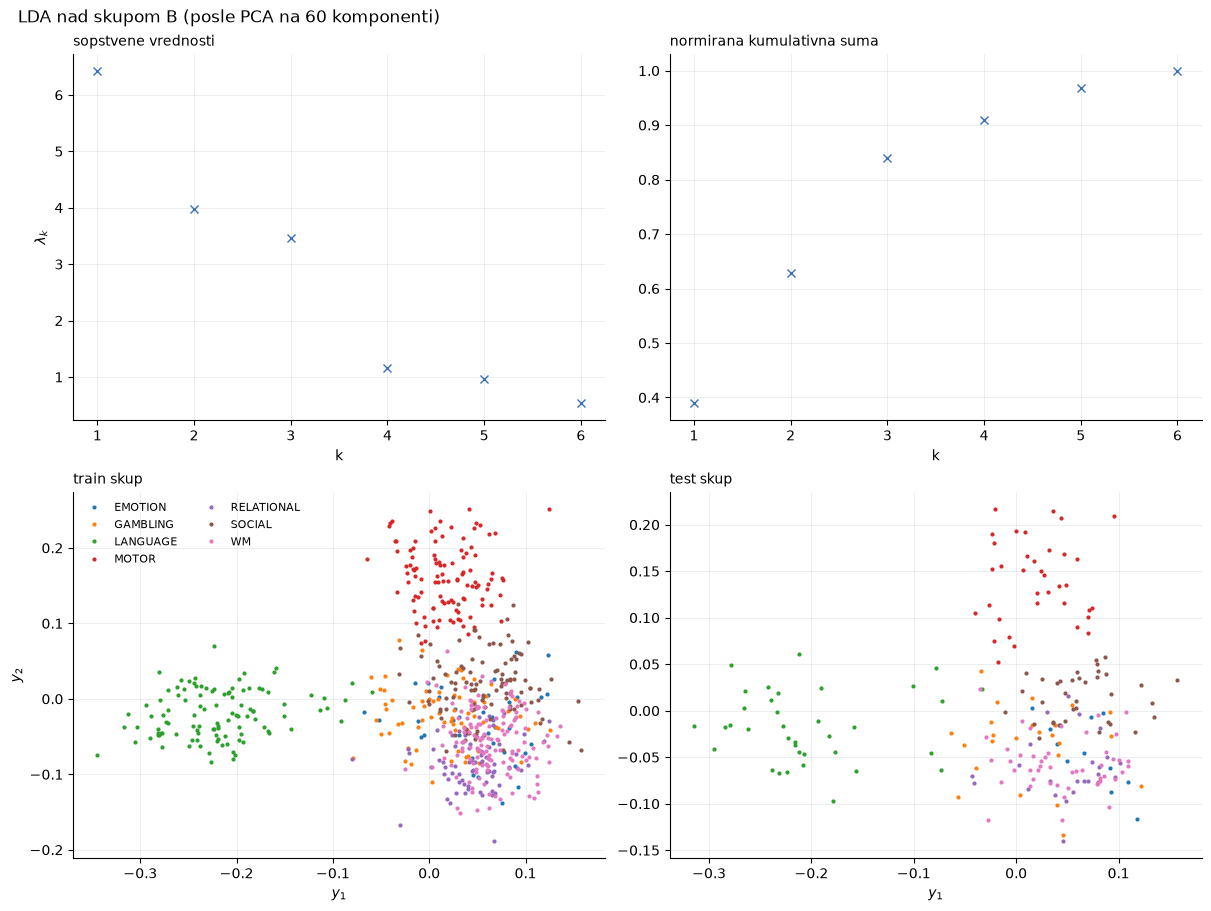

In [31]:
# Uopšteni sopstveni problem S_b w = λ S_w w. Sa 1653 obeležja na 807 trening prozora S_w je
# singularna, pa prvo ide PCA na 60 komponenti i blaga regularizacija. Rešenje se dobija beljenjem — matrica S_w^{-1/2} S_b S_w^{-1/2} je
# simetrična, pa je dovoljan np.linalg.eigh, bez uopštenog rešavača. Test panel pokazuje da li
# nađeni pravci prežive prelazak na neviđene ispitanike.
NPC = 60

Ppc, _        = pca_ose(F_all, NPC)
W2, lam, cond = lda_ose(Ppc[IDX["train"]], yw[IDX["train"]], k=2)
lam           = lam[:len(TASKS) - 1]                # rang S_b je C − 1 = 6
A2            = Ppc @ W2                            # svi prozori na prve dve LDA ose

print(f"{len(lam)} netrivijalnih pravaca, prva dva nose {lam[:2].sum() / lam.sum():.1%} "
      f"razdvojivosti;  uslovljenost S_w {cond:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].plot(np.arange(1, len(lam) + 1), lam, "x", color=ACCENT)
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel(r"$\lambda_k$")
axes[0, 0].set_title("sopstvene vrednosti")

axes[0, 1].plot(np.arange(1, len(lam) + 1), np.cumsum(lam) / lam.sum(), "x", color=ACCENT)
axes[0, 1].set_xlabel("k")
axes[0, 1].set_title("normirana kumulativna suma")

for ax, part in zip(axes[1], ("train", "test")):
    for task in TASKS:
        m = (yw == task) & np.isin(np.arange(len(yw)), IDX[part])
        ax.plot(A2[m, 0], A2[m, 1], ".", ms=4, label=task)
    ax.set_xlabel("$y_1$")
    ax.set_title(f"{part} skup")
axes[1, 0].set_ylabel("$y_2$")
axes[1, 0].legend(fontsize=8, frameon=False, ncol=2)
fig.suptitle(f"LDA nad skupom B (posle PCA na {NPC} komponenti)", x=0.01, ha="left")

**Kako se čita.** `λ_k` je odnos rasipanja između i unutar klasa duž k-tog pravca; netrivijalnih pravaca ima najviše C − 1 = 6, koliko i klasa umanjeno za jedan. Donja dva panela su trening i test skup u istom prostoru: ako se klase razdvajaju samo levo, pravci su naučeni na ispitanicima a ne na zadacima. Uslovljenost `S_w` stoji uz ispis jer je regularizacija ta koja je drži konačnom — bez nje beljenje puca.

Računa F-vrednost svakog obeležja na trening skupu.

In [32]:
# Interpretacija obeležja, a ne samo njihova upotreba u klasifikatoru.
#   1) koliko su DWT obeležja zaista drugačija u odnosu na standardna,
#   2) koji tip obeležja nosi diskriminativnu moć,
#   3) koji regioni je nose, i da li to ima smisla za ovaj skup zadataka.
# Sve se računa isključivo na trening skupu, da interpretacija ne gleda val ni test.
Fv, _ = f_classif(F_all[IDX["train"]], yw[IDX["train"]])
Fv    = np.nan_to_num(Fv)
pref  = np.array([n.split(":")[0] for n in ALL_NAMES])
reg   = np.array([n.split(":")[1] for n in ALL_NAMES])

Meri redundantnost standardnog i DWT dela po podopsegu — korelaciju i diskriminativnost.

In [33]:
# 1) Redundantnost: granice opsega u standardnom skupu su diadske (NYQ/2^k), dakle iste kao
#    DWT podopsezi, pa band_s (relativna snaga iz Welch-a) i E_s (relativna energija
#    koeficijenata) mere istu fizičku veličinu, samo drugim postupkom.
print("Redundantnost standardnog i DWT dela, po podopsegu")
print(f"{'podopseg':9s} {'opseg (Hz)':>14s} {'r(band, E)':>11s} {'F(band)':>9s} {'F(E)':>8s}")
r_red = []
for si, s in enumerate(SUB):
    rr = np.array([np.corrcoef(blocks[si][:, j], rel[si][:, j])[0, 1] for j in range(len(names))])
    r_red.append(np.nanmean(rr))
    lo, hi = opseg(s)
    print(f"{s:9s} {f'{lo:.3f}-{hi:.3f}':>14s} {r_red[-1]:11.3f} "
          f"{Fv[pref == f'band_{s}'].mean():9.1f} {Fv[pref == f'E_{s}'].mean():8.1f}")

Redundantnost standardnog i DWT dela, po podopsegu
podopseg      opseg (Hz)  r(band, E)   F(band)     F(E)
A4           0.000-0.043       0.509      22.7     12.6
D4           0.043-0.087       0.532      11.5      7.7
D3           0.087-0.174       0.512       6.2      6.8
D2           0.174-0.347       0.555      11.2     10.2
D1           0.347-0.694       0.670      14.3     12.1


**Kako se čita.** Po podopsegu: `r(band, E)` je korelacija između snage iz Welch-ove ocene i energije DWT koeficijenata, usrednjena po regionima. `F(band)` i `F(E)` su prosečne F-vrednosti te dve grupe obeležja; veće F znači diskriminativnije obeležje.

Diskriminativnost po tipu obeležja i po regionu.


prosečan F po tipu obeležja: entropy=21.6  ac5=19.9  ac1=19.4  centroid=18.3  band=13.2  E=9.9  H=1.9


Text(0.01, 0.98, 'Analiza obeležja (samo trening skup)')

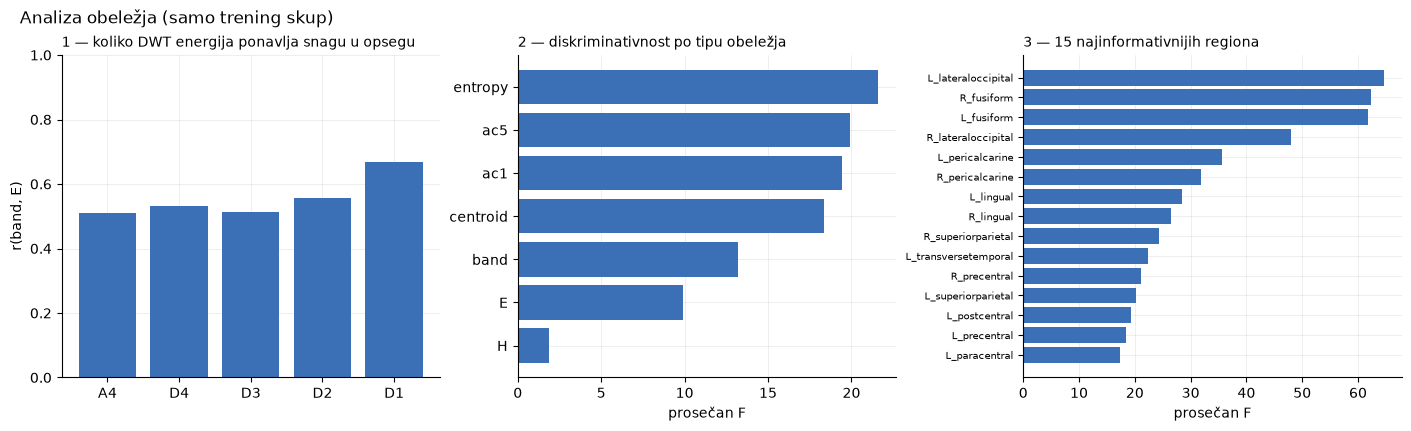

In [34]:
# 2) i 3) Diskriminativnost po tipu obeležja i po regionu.
coarse  = np.array([tip_obelezja(n) for n in ALL_NAMES])
by_kind = dict(sorted({k: Fv[coarse == k].mean() for k in dict.fromkeys(coarse)}.items(),
                      key=lambda t: t[1]))
by_reg  = dict(sorted({r: Fv[reg == r].mean() for r in dict.fromkeys(reg)}.items(),
                      key=lambda t: t[1])[-15:])
print(f"\nprosečan F po tipu obeležja: "
      + "  ".join(f"{k}={v:.1f}" for k, v in reversed(by_kind.items())))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), layout="constrained")
axes[0].bar(range(len(SUB)), r_red, color=ACCENT)
axes[0].set_xticks(range(len(SUB)))
axes[0].set_xticklabels(SUB)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("r(band, E)")
axes[0].set_title("1 — koliko DWT energija ponavlja snagu u opsegu")

axes[1].barh(list(by_kind), list(by_kind.values()), color=ACCENT)
axes[1].set_xlabel("prosečan F")
axes[1].set_title("2 — diskriminativnost po tipu obeležja")

axes[2].barh(list(by_reg), list(by_reg.values()), color=ACCENT)
axes[2].tick_params(axis="y", labelsize=7)
axes[2].set_xlabel("prosečan F")
axes[2].set_title("3 — 15 najinformativnijih regiona")
fig.suptitle("Analiza obeležja (samo trening skup)", x=0.01, ha="left")

**Kako se čita.** Prosečna F-vrednost po tipu obeležja. `band` je snaga po opsegu, `E` energija DWT koeficijenata, `H` njihova entropija, a `entropy`, `centroid`, `ac1` i `ac5` su spektralna entropija, spektralno težište i dve autokorelacije.

Ispisuje najdiskriminativnija pojedinačna obeležja i najčešće zastupljene regione.

In [35]:
Fv, pv = f_classif(F_all[IDX["train"]], yw[IDX["train"]])
Fv     = np.nan_to_num(Fv)
order  = np.argsort(-Fv)

print("najdiskriminativnijih 25:")
for j in order[:25]:
    print(f"  {ALL_NAMES[j]:34s} F={Fv[j]:7.2f}")

# udeo po tipu obeležja i po podopsegu
top  = order[:200]
kind = np.array([n.split(":")[0].split("_")[0] for n in ALL_NAMES])
reg  = np.array([n.split(":")[1] for n in ALL_NAMES])
print("\nudeo u top 200 po tipu:", dict(sorted(collections.Counter(kind[top]).items(),
                                               key=lambda t: -t[1])))
print("najčešći regioni:", collections.Counter(reg[top]).most_common(10))

najdiskriminativnijih 25:
  band_A4:R_fusiform                 F= 143.14
  band_A4:L_lateraloccipital         F= 136.79
  ac5:L_fusiform                     F= 132.94
  band_A4:L_fusiform                 F= 132.73
  centroid:L_lateraloccipital        F= 132.65
  ac1:L_fusiform                     F= 132.12
  ac1:R_fusiform                     F= 127.90
  ac5:R_fusiform                     F= 124.46
  centroid:R_fusiform                F= 123.91
  entropy:L_lateraloccipital         F= 123.22
  ac1:L_lateraloccipital             F= 118.80
  ac5:L_lateraloccipital             F= 116.79
  centroid:L_fusiform                F= 114.77
  band_A4:R_lateraloccipital         F= 114.69
  band_D4:L_pericalcarine            F= 109.88
  entropy:R_fusiform                 F= 105.81
  band_D1:R_fusiform                 F=  99.61
  E_A4:L_fusiform                    F=  99.27
  band_A4:L_pericalcarine            F=  98.64
  band_D1:L_lateraloccipital         F=  96.73
  E_D1:L_fusiform                 

**Kako se čita.** Prvi spisak su pojedinačna obeležja sa najvećom F-vrednošću, u obliku `tip:region`. `udeo u top 200 po tipu` govori koliko obeležja svakog tipa uđe među prvih 200, a `najčešći regioni` koliko se puta svaki region pojavljuje u tom spisku.

Sastav izabranog skupa po tipu obeležja, za nekoliko budžeta selekcije.

In [36]:
# Zašto B pri k=50 gubi: DWT obeležja su bliski duplikati band_* obeležja, pa pri malom broju
# zadržanih obeležja istiskuju komplementarne tipove (ac1, ac5, centroid, entropy) umesto da
# ih dopune.
for k in (25, 50, 100, 400):
    print(f"\nk = {k}")
    for tag, F, NM in [("A standardna", F_std, FEAT_NAMES), ("B standardna+DWT", F_all, ALL_NAMES)]:
        cnt = collections.Counter()
        for tr, te in LOSO:
            Fs_, _ = f_classif(F[tr], yw[tr])
            sub = np.argsort(-np.nan_to_num(Fs_))[:k]
            cnt.update(tip_obelezja(NM[j]) for j in sub)
        tot = sum(cnt.values())
        print(f"  {tag:18s} " + "  ".join(f"{t}={100 * c / tot:.0f}%" for t, c in cnt.most_common()))


k = 25
  A standardna       band=40%  entropy=19%  ac5=16%  centroid=12%  ac1=12%
  B standardna+DWT   band=33%  ac5=16%  entropy=16%  ac1=12%  centroid=12%  E=11%

k = 50
  A standardna       band=47%  ac5=18%  entropy=17%  ac1=10%  centroid=8%
  B standardna+DWT   band=37%  E=22%  entropy=12%  ac5=12%  ac1=8%  centroid=8%

k = 100
  A standardna       band=38%  entropy=21%  ac5=16%  ac1=14%  centroid=11%
  B standardna+DWT   band=32%  E=21%  entropy=16%  ac5=15%  ac1=10%  centroid=6%

k = 400
  A standardna       band=46%  ac1=15%  entropy=14%  centroid=13%  ac5=13%
  B standardna+DWT   band=33%  E=25%  ac1=11%  entropy=11%  centroid=10%  ac5=9%  H=1%


**Kako se čita.** `k` je broj obeležja koje selekcija zadržava. Ispod svakog `k` stoje dva reda, jedan za skup A i jedan za skup B. Nazivi su tipovi obeležja, a procenat je njihov udeo u izabranom skupu, zbir po redu je 100%, a tipovi sa udelom nula se ne ispisuju. Redovi A i B porede se pri istom `k`.

Poređenje šest familija talasića, da se vidi koliko izbor utiče na rezultat.

In [37]:
# Rad [01] koristi kubne Battle-Lemarié talasiće, kojih u pywt nema, pa izbor db4 mora da se
# obrazloži. Broj nivoa zavisi od dužine filtra, pa se sa talasićem menja i broj obeležja.
print(f"{'talasić':8s} {'dec_len':>8s} {'L':>3s} {'DWT obeležja':>13s}   {'LOSO (skup B)':>16s}")
for wav in ("db2", "db4", "db8", "sym4", "sym8", "coif2"):
    Lw = pywt.dwt_max_level(WIN, pywt.Wavelet(wav).dec_len)
    Fd = dwt_obelezja(Xw, wav, Lw)
    a  = loso_tacnost(np.concatenate([F_std, Fd], axis=1))
    print(f"{wav:8s} {pywt.Wavelet(wav).dec_len:8d} {Lw:3d} {Fd.shape[1]:13d}   "
          f"{a.mean():.3f} ± {a.std():.3f}", flush=True)

talasić   dec_len   L  DWT obeležja      LOSO (skup B)
db2             4   5          1044   0.764 ± 0.207
db4             8   4           870   0.750 ± 0.205
db8            16   3           696   0.746 ± 0.207
sym4            8   4           870   0.751 ± 0.212
sym8           16   3           696   0.749 ± 0.210
coif2          12   4           870   0.747 ± 0.206


**Kako se čita.** `dec_len` je dužina filtra talasića, `L` broj nivoa koji ta dužina dopušta za korišćenu dužinu prozora, pa broj dobijenih DWT obeležja i tačnost skupa B sa njima.

Računa tačan Battle-Lemarié filtar u frekvencijskom domenu i meri pristrasnost `db4` procene po podopsegu.

In [38]:
# Battle-Lemarié tačno, u frekvencijskom domenu. Filtar je beskonačan sa eksponencijalnim
# opadanjem, pa filtarska banka traži skraćivanje a na prozoru od 176 uzoraka skraćenje
# koje daje L=4 nosi grešku rekonstrukcije od 30% standardne devijacije. Za relativnu
# energiju po podopsegu banka nije ni potrebna: po Parsevalu je energija podopsega
# Σ_ω |X(ω)|²·|filtar(ω)|², a |H(ω)| i |G(ω)| ortonormalizovanog splajna se znaju tačno.
# Bitno je jer je A4 najdiskriminativniji opseg, a db4 ga na ovako kratkom prozoru precenjuje.
NSPL = 3                                        # kubni splajn, kao u radu [01]
om   = 2 * np.pi * np.fft.rfftfreq(WIN)

wg, Sg = np.linspace(0, 2 * np.pi, 1 << 14, endpoint=False), 0.0
for kk in range(-60, 61):                       # S(ω) = Σ_k |N̂(ω+2πk)|², 2π-periodična
    xx = wg + 2 * np.pi * kk
    with np.errstate(invalid="ignore", divide="ignore"):
        tt = (np.sin(xx / 2) / (xx / 2)) ** (2 * (NSPL + 1))
    Sg = Sg + np.where(np.abs(xx) < 1e-12, 1.0, tt)

def Sf(v):
    """Vrednost 2π-periodične sume S(ω), linearnom interpolacijom sa guste mreže."""
    return np.interp(np.mod(v, 2 * np.pi), wg, Sg, period=2 * np.pi)

Pw, low = [], np.ones_like(om)                  # kaskada: |A_l|² i |D_l|²
for l in range(1, L + 1):
    aa_ = 2.0 ** (l - 1) * om
    H2 = 2 * np.abs(np.cos(aa_ / 2)) ** (2 * (NSPL + 1)) * Sf(aa_) / Sf(2 * aa_)
    G2 = 2 * np.abs(np.cos((aa_ + np.pi) / 2)) ** (2 * (NSPL + 1)) * Sf(aa_ + np.pi) / Sf(2 * aa_)
    Pw.append(low * G2 / 2)
    low = low * H2 / 2
Pw = [low] + Pw[::-1]                           # [A_L, D_L, ..., D_1] — isti redosled kao SUB
print(f"provera potpunosti banke: max |Σ|filtar|² − 1| = {np.abs(np.sum(Pw, 0) - 1).max():.2e}")

Xf   = np.fft.rfft(Xw, axis=1)                  # (n, WIN//2+1, R)
wgt  = np.ones(len(om)); wgt[1:-1] = 2.0        # rfft: unutrašnji binovi se broje dvaput
Ebl  = np.stack([(wgt[None, :, None] * np.abs(Xf) ** 2 * pw[None, :, None]).sum(1) for pw in Pw])
Ebl  = Ebl / np.maximum(Ebl.sum(0, keepdims=True), 1e-12)
F_bl = np.concatenate(list(Ebl), axis=1).astype(np.float32)

print(f"\n{'podopseg':9s} {'BL (tačno)':>11s} {'db4':>8s} {'idealno':>9s} {'r':>7s}")
for si, s in enumerate(SUB):
    ideal = 2.0 ** -(L if s[0] == "A" else int(s[1:]))
    r_ = np.mean([np.corrcoef(Ebl[si][:, j], rel[si][:, j])[0, 1] for j in range(len(names))])
    print(f"{s:9s} {Ebl[si].mean():11.4f} {rel[si].mean():8.4f} {ideal:9.4f} {r_:7.3f}")

# Poređenje mora ići pri istoj dimenziji: BL daje samo relativnu energiju, pa se i db4 uzima
# u toj varijanti, bez entropije koeficijenata. Inače se meri i razlika u broju obeležja.
F_e_db4 = np.concatenate([F_std, np.concatenate(rel, axis=1).astype(np.float32)], axis=1)
F_blall = np.concatenate([F_std, F_bl], axis=1)
print()
for tag, F in [("A standardna", F_std),
               ("B standardna+DWT (db4, pun)", F_all),
               ("B' standardna+E (db4)", F_e_db4),
               ("B' standardna+E (BL)", F_blall)]:
    a = loso_tacnost(F)
    print(f"{tag:28s} {F.shape[1]:5d} obeležja   LOSO {a.mean():.3f} ± {a.std():.3f}")

provera potpunosti banke: max |Σ|filtar|² − 1| = 9.08e-08

podopseg   BL (tačno)      db4   idealno       r
A4             0.2755   0.3969    0.0625   0.637
D4             0.1480   0.1185    0.0625   0.679
D3             0.1386   0.1204    0.1250   0.666
D2             0.1559   0.1402    0.2500   0.739
D1             0.2821   0.2240    0.5000   0.835

A standardna                   783 obeležja   LOSO 0.734 ± 0.210
B standardna+DWT (db4, pun)   1653 obeležja   LOSO 0.750 ± 0.205
B' standardna+E (db4)         1218 obeležja   LOSO 0.738 ± 0.203
B' standardna+E (BL)          1218 obeležja   LOSO 0.735 ± 0.212


**Kako se čita.** `BL (tačno)` je udeo energije po podopsegu izračunat tačnim Battle-Lemarié filtrom, `db4` isto to preko korišćene aproksimacije, `idealno` podela koju bi dao beli šum, a `r` korelacija dve procene preko prozora. Poslednja tri reda su tačnosti skupova sa jednim odnosno drugim obeležjima.

Klasterizacija Gausovskom mešavinom, bez korišćenja oznaka.

  K   ARI zadatak   ARI ispitanik   NMI zadatak   NMI ispitanik
  7         0.255           0.055         0.377           0.240
 30         0.154           0.165         0.364           0.483


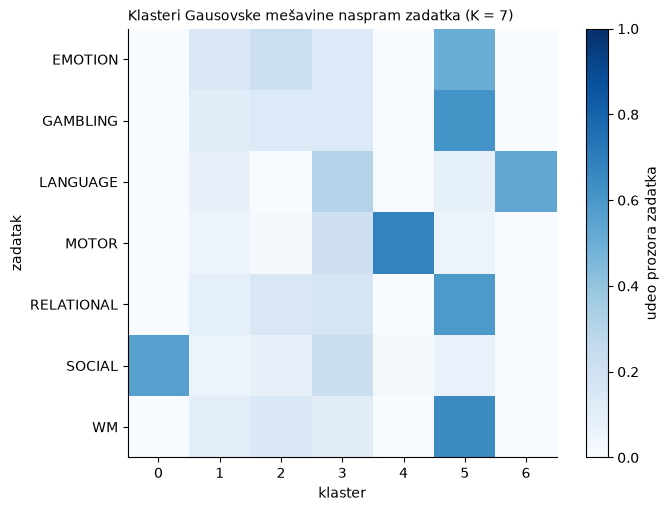

In [39]:
# Jedina metoda u svesci koja ne koristi oznake. Pitanje nije koliko klasterizacija pogađa
# zadatak, nego da li se prozori uopšte grupišu po zadatku ili po ispitaniku — zato se ARI i
# NMI računaju u odnosu na oba. Ulaz je 20 PCA komponenti, jer mešavina nad 1653 obeležja ne
# konvergira, a dijagonalna kovarijacija je izbor iste vrste kao naivni Bayes.
Ppc, _ = pca_ose(F_all, 20)

print(f"{'K':>3s} {'ARI zadatak':>13s} {'ARI ispitanik':>15s} {'NMI zadatak':>13s} {'NMI ispitanik':>15s}")
for K in (len(TASKS), len(SUBJECTS)):
    lab = _GM(K, covariance_type="diag", random_state=SEED, n_init=3).fit_predict(Ppc)
    print(f"{K:3d} {_ari(yw, lab):13.3f} {_ari(gw, lab):15.3f} "
          f"{_nmi(yw, lab):13.3f} {_nmi(gw, lab):15.3f}")

lab = _GM(len(TASKS), covariance_type="diag", random_state=SEED, n_init=3).fit_predict(Ppc)
ct  = np.zeros((len(TASKS), len(TASKS)))
for i, task in enumerate(TASKS):
    for k in range(len(TASKS)):
        ct[i, k] = np.sum((yw == task) & (lab == k))
ct /= ct.sum(1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ct, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(TASKS)))
ax.set_yticks(range(len(TASKS)))
ax.set_yticklabels(TASKS)
ax.set_xlabel("klaster")
ax.set_ylabel("zadatak")
ax.grid(False)
ax.set_title(f"Klasteri Gausovske mešavine naspram zadatka (K = {len(TASKS)})")
fig.colorbar(im, ax=ax, label="udeo prozora zadatka")

**Kako se čita.** `ARI` i `NMI` mere slaganje klastera sa zadatkom i sa ispitanikom; prvi red je `K` jednako broju zadataka, drugi broju ispitanika. Ako je slaganje sa ispitanikom uporedivo sa slaganjem sa zadatkom, obeležja u dobroj meri kodiraju identitet ispitanika, što je gornja granica za LOSO. Mapa je udeo prozora svakog zadatka po klasteru, normalizovan po redu.

## Model

Glavna tabela rezultata: skupovi A, B i C na validacionom skupu, testu i pod LOSO.

In [40]:
# LOSO stoji uz to kao procena rasipanja po ispitanicima — koristi sve ispitanike, pa nije zamena za test skup nego dopuna.
print("train", [str(s) for s in SUBJ["train"]])
print("val  ", [str(s) for s in SUBJ["val"]])
print("test ", [str(s) for s in SUBJ["test"]], "\n")

print(f"{'skup':20s} {'obeležja':>8s} {'val':>6s} {'test':>6s}   {'LOSO':>14s}   opseg")
res_split = {}
for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all), ("C samo DWT", F_dwt)]:
    m = GaussianNB().fit(F[IDX["train"]], yw[IDX["train"]])
    a = loso_tacnost(F)
    res_split[tag] = {"val":  m.score(F[IDX["val"]], yw[IDX["val"]]),
                      "test": m.score(F[IDX["test"]], yw[IDX["test"]]),
                      "loso": a,
                      "po":   [m.score(F[gw == s], yw[gw == s]) for s in SUBJ["test"]]}
    print(f"{tag:20s} {F.shape[1]:8d} {res_split[tag]['val']:6.3f} {res_split[tag]['test']:6.3f}   "
          f"{a.mean():6.3f} ± {a.std():.3f}   {a.min():.2f}–{a.max():.2f}")
print(f"{'većinska klasa':20s} {'':8s} {'':>6s} {CHANCE:6.3f}")

print("\ntačnost po test ispitaniku (zbirni broj sa dva ispitanika ne govori o rasipanju):")
for tag in res_split:
    print(f"  {tag:20s} " + "   ".join(f"{str(s)}: {v:.3f}"
          for s, v in zip(SUBJ["test"], res_split[tag]["po"])))

train ['111211', '125424', '130518', '135124', '146735', '153126', '176845', '180230', '186848', '213017', '257946', '274542', '378756', '510225', '590047', '692964', '869472', '911849']
val   ['137532', '151930', '192237', '199352', '227533', '300719']
test  ['118831', '165436', '206525', '392447', '519647', '698168'] 

skup                 obeležja    val   test             LOSO   opseg
A standardna              783  0.737  0.727    0.734 ± 0.210   0.06–0.97
B standardna+DWT         1653  0.756  0.759    0.750 ± 0.205   0.17–1.00
C samo DWT                870  0.685  0.694    0.674 ± 0.190   0.17–0.97
većinska klasa                        0.223

tačnost po test ispitaniku (zbirni broj sa dva ispitanika ne govori o rasipanju):
  A standardna         118831: 0.694   165436: 0.944   206525: 0.667   392447: 0.889   519647: 0.417   698168: 0.750
  B standardna+DWT     118831: 0.667   165436: 1.000   206525: 0.722   392447: 0.917   519647: 0.444   698168: 0.806
  C samo DWT           11883

**Kako se čita.** `obeležja` je dimenzija skupa. `val` i `test` su jednokratne ocene na tim skupovima, `LOSO` prosek ± rasipanje preko foldova, a `opseg` najniža i najviša tačnost pojedinačnog ispitanika. Ispod je tačnost svakog test ispitanika posebno.

Redukcija dimenzije unutar folda: PCA i LDA kao ulaz u model, uz makro AUC.

In [41]:
# Reprezentacije iz odeljka o analizi obeležja, sada kao ulaz u model. PCA i LDA se uče unutar
# svakog folda i samo na njegovom trening delu: ako se nauče jednom nad svim prozorima, u ocenu
# ulazi i informacija iz test folda, pa tačnost izlazi precenjena. LDA ide na PCA komponente,
# jer je S_w nad 1653 obeležja singularna. Uz tačnost stoji i makro AUC iz istih out-of-fold
# verovatnoća, jer tačnost zavisi od praga a AUC ne.
NPC_MODEL, NLDA = 60, len(TASKS) - 1

print(f"{'skup':20s} {'redukcija':>14s} {'dimenzija':>10s} {'LOSO':>16s} {'makro AUC':>11s}")
red = {}
for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all)]:
    for kind in ("bez redukcije", f"PCA {NPC_MODEL}", f"LDA {NLDA}"):
        tacnosti, auc_folda, dim = [], [], F.shape[1]
        for tr, te in LOSO:
            if kind == "bez redukcije":
                Ftr, Fte = F[tr], F[te]
            else:
                P, _ = pca_ose(F, NPC_MODEL, trening=tr)     # ose iz trening dela ovog folda
                if kind.startswith("PCA"):
                    Ftr, Fte = P[tr], P[te]
                else:
                    W_, _, _ = lda_ose(P[tr], yw[tr], NLDA)
                    Ftr, Fte = P[tr] @ W_, P[te] @ W_
                dim = Ftr.shape[1]
            m = GaussianNB().fit(Ftr, yw[tr])
            tacnosti.append(m.score(Fte, yw[te]))
            auc_folda.append(np.mean(list(
                auc_po_klasi(yw[te], m.predict_proba(Fte), m.classes_).values())))
        red[tag, kind] = np.array(tacnosti)
        print(f"{tag:20s} {kind:>14s} {dim:10d} {np.mean(tacnosti):6.3f} ± {np.std(tacnosti):.3f}"
              f" {np.mean(auc_folda):11.3f}", flush=True)

print()
for tag in ("A standardna", "B standardna+DWT"):
    for kind in (f"PCA {NPC_MODEL}", f"LDA {NLDA}"):
        uparena_razlika(red[tag, kind], red[tag, "bez redukcije"],
                        f"{tag}: {kind} − bez redukcije:", sirina=44)

skup                      redukcija  dimenzija             LOSO   makro AUC
A standardna          bez redukcije        783  0.734 ± 0.210       0.932
A standardna                 PCA 60         60  0.767 ± 0.166       0.969
A standardna                  LDA 6          6  0.818 ± 0.128       0.979
B standardna+DWT      bez redukcije       1653  0.750 ± 0.205       0.927
B standardna+DWT             PCA 60         60  0.785 ± 0.157       0.978
B standardna+DWT              LDA 6          6  0.849 ± 0.124       0.986

A standardna: PCA 60 − bez redukcije:        +0.034 ± 0.125   pozitivnih 14/30   p=0.347
A standardna: LDA 6 − bez redukcije:         +0.084 ± 0.131   pozitivnih 19/30   p=0.002
B standardna+DWT: PCA 60 − bez redukcije:    +0.036 ± 0.147   pozitivnih 14/30   p=0.204
B standardna+DWT: LDA 6 − bez redukcije:     +0.100 ± 0.138   pozitivnih 22/30   p=0.000


**Kako se čita.** `dimenzija` je broj obeležja koji klasifikator zaista vidi, `LOSO` prosek ± rasipanje po ispitanicima, a `makro AUC` prosek površina ispod ROC krive po klasama, iz istih out-of-fold verovatnoća. Ispod su uparene razlike u odnosu na varijantu bez redukcije: pozitivna vrednost znači da svođenje na manji broj osa pomaže, negativna da odbacuje informaciju koju naivni Bayes ume da iskoristi.

Ponavlja poređenje A naspram B preko 20 nasumičnih podela ispitanika.

In [42]:
# Test skup je šest ispitanika, a tačnost po ispitaniku ide od 0.06 do 1.00, pa konačan broj
# zavisi od toga koji su ispali. Ista podela 18/6/6 ponavlja se preko 20 seed-ova; gleda se
# raspodela tačnosti na testu i raspodela razlike B−A. Podela SEED = 0 ostaje ona prijavljena
# u radu — ovo je procena njene krhkosti, ne novi izbor.
SEEDS = range(20)
rows  = {"A standardna": [], "B standardna+DWT": [], "B − A": []}
for sd in SEEDS:
    pm_ = np.random.default_rng(sd).permutation(np.array(SUBJECTS))
    tr_ = np.flatnonzero(np.isin(gw, pm_[:N_TRAIN]))
    te_ = np.flatnonzero(np.isin(gw, pm_[N_TRAIN + N_VAL:]))
    sc  = []
    for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all)]:
        s_ = GaussianNB().fit(F[tr_], yw[tr_]).score(F[te_], yw[te_])
        rows[tag].append(s_)
        sc.append(s_)
    rows["B − A"].append(sc[1] - sc[0])

print(f"{'':20s} {'prosek':>8s} {'sd':>7s} {'min':>8s} {'max':>8s}")
for k, v in rows.items():
    v = np.array(v)
    print(f"{k:20s} {v.mean():8.3f} {v.std():7.3f} {v.min():8.3f} {v.max():8.3f}")

d = np.array(rows["B − A"])
print(f"\nB iznad A na testu: {(d > 0).sum()}/{len(d)} semena")
print(f"prijavljena podela (SEED = {SEED}): A {rows['A standardna'][SEED]:.3f}   "
      f"B {rows['B standardna+DWT'][SEED]:.3f}   B−A {d[SEED]:+.3f}")

                       prosek      sd      min      max
A standardna            0.739   0.075    0.577    0.866
B standardna+DWT        0.760   0.066    0.587    0.875
B − A                   0.020   0.022   -0.009    0.070

B iznad A na testu: 16/20 semena
prijavljena podela (SEED = 0): A 0.727   B 0.759   B−A +0.032


**Kako se čita.** Tri reda su raspodele preko 20 nasumičnih podela ispitanika: prosek, rasipanje, najmanja i najveća vrednost. Red `B − A` je razlika unutar iste podele, ne razlika proseka. Poslednji red daje vrednosti za podelu koja se prijavljuje u radu.

Tačnost svakog DWT podopsega zasebno.

  A4   LOSO 0.629 ± 0.128
  D4   LOSO 0.413 ± 0.129
  D3   LOSO 0.441 ± 0.117
  D2   LOSO 0.512 ± 0.155
  D1   LOSO 0.505 ± 0.171


Text(0.0, 1.0, 'Tačnost po podopsegu — isprekidano: većinska klasa')

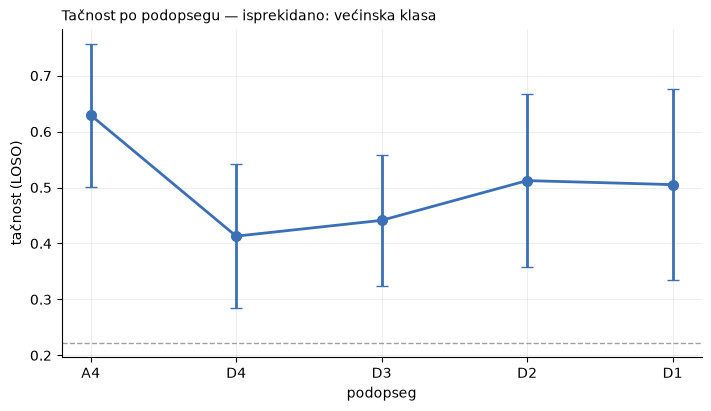

In [43]:
sub_acc = {}
for k, s in enumerate(SUB):
    Fk = np.concatenate([rel[k], ent[k]], axis=1).astype(np.float32)
    sub_acc[s] = loso_tacnost(Fk)
    print(f"  {s:3s}  LOSO {sub_acc[s].mean():.3f} ± {sub_acc[s].std():.3f}")

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.errorbar(range(len(SUB)), [sub_acc[s].mean() for s in SUB],
            yerr=[sub_acc[s].std() for s in SUB],
            marker="o", ms=7, lw=2, color=ACCENT, capsize=4)
ax.axhline(CHANCE, lw=1, color=MUTED, ls="--")
ax.set_xticks(range(len(SUB)))
ax.set_xticklabels(SUB)
ax.set_ylabel("tačnost (LOSO)")
ax.set_xlabel("podopseg")
ax.set_title("Tačnost po podopsegu — isprekidano: većinska klasa")

**Kako se čita.** Po podopsegu, tačnost klasifikatora koji koristi obeležja samo tog podopsega: prosek ± rasipanje preko foldova. Na figuri je isprekidana linija većinska klasa.

Matrice konfuzije za oba skupa i njihova razlika po zadatku.

promene na dijagonali (osetljivost po zadatku):
  EMOTION      0.600 -> 0.617   +0.017
  GAMBLING     0.625 -> 0.667   +0.042
  LANGUAGE     0.867 -> 0.861   -0.006
  MOTOR        0.864 -> 0.898   +0.034
  RELATIONAL   0.767 -> 0.708   -0.058
  SOCIAL       0.789 -> 0.778   -0.011
  WM           0.575 -> 0.637   +0.062


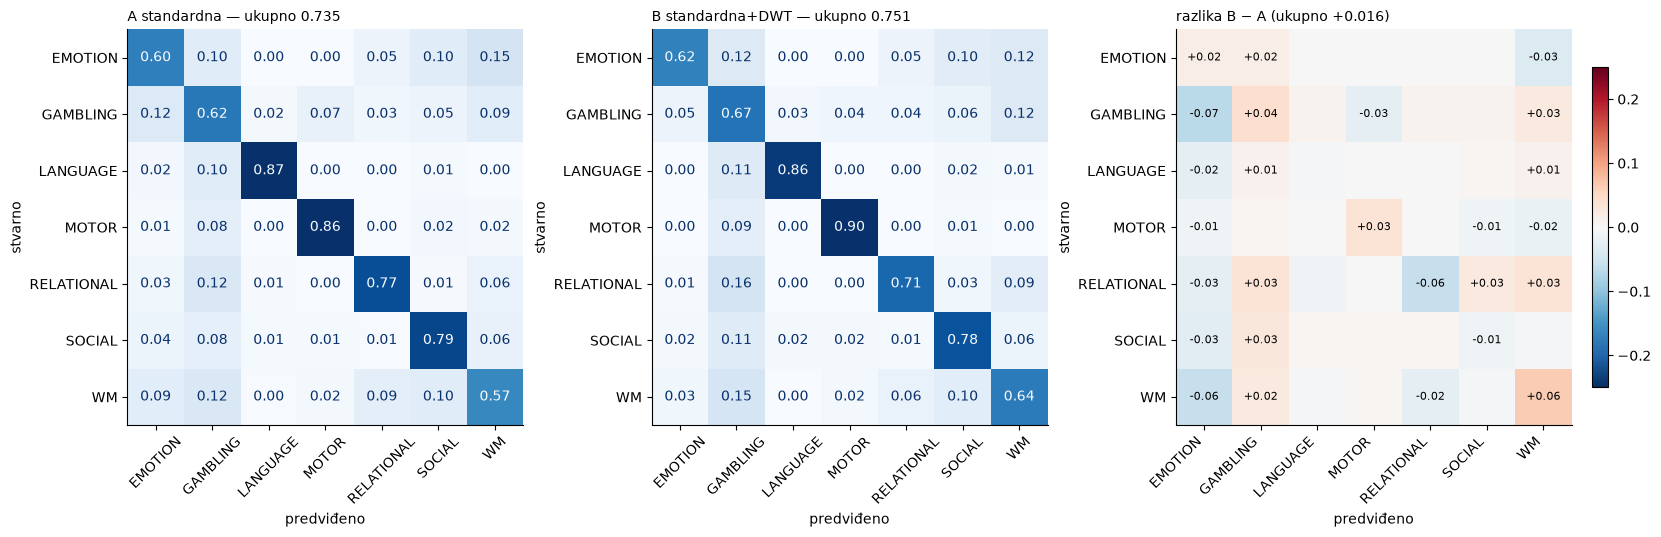

In [44]:
# Matrica konfuzije za oba skupa i njihova razlika: ne samo koliko, nego gde se predikcije
# menjaju kad se DWT koeficijenti dodaju. Redovi su tačne oznake, kolone predviđene,
# normalizovano po redu (dakle po klasi), pa je dijagonala osetljivost po zadatku.
labels, cms, acc_ = sorted(set(yw)), {}, {}
for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all)]:
    pr        = oof_predikcije(F)
    cms[tag]  = confusion_matrix(yw, pr, labels=labels, normalize="true")
    acc_[tag] = (pr == yw).mean()

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4), layout="constrained")
for ax, tag in zip(axes[:2], cms):
    ConfusionMatrixDisplay(cms[tag], display_labels=labels).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(f"{tag} — ukupno {acc_[tag]:.3f}")
    ax.set_xlabel("predviđeno")
    ax.set_ylabel("stvarno")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(False)

Dm = cms["B standardna+DWT"] - cms["A standardna"]
im = axes[2].imshow(Dm, cmap="RdBu_r", vmin=-0.25, vmax=0.25)
for i_ in range(len(labels)):
    for j_ in range(len(labels)):
        if abs(Dm[i_, j_]) >= 0.01:
            axes[2].text(j_, i_, f"{Dm[i_, j_]:+.2f}", ha="center", va="center", fontsize=8,
                         color="white" if abs(Dm[i_, j_]) > 0.15 else "black")
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, rotation=45, ha="right")
axes[2].set_yticks(range(len(labels)))
axes[2].set_yticklabels(labels)
axes[2].set_xlabel("predviđeno")
axes[2].set_ylabel("stvarno")
axes[2].set_title(f"razlika B − A (ukupno {acc_['B standardna+DWT'] - acc_['A standardna']:+.3f})")
axes[2].grid(False)
fig.colorbar(im, ax=axes[2], shrink=0.7)

print("promene na dijagonali (osetljivost po zadatku):")
for i_, c_ in enumerate(labels):
    print(f"  {c_:12s} {cms['A standardna'][i_, i_]:.3f} -> "
          f"{cms['B standardna+DWT'][i_, i_]:.3f}   {Dm[i_, i_]:+.3f}")

**Kako se čita.** Ispis daje dijagonalu matrice konfuzije, dakle osetljivost po zadatku, pre i posle dodavanja DWT, i njihovu razliku. Figure su matrice konfuzije oba skupa i njihova razlika.

ROC krive obe reprezentacije, sa ručnim prolaskom kroz prag odlučivanja.

A standardna         tačnost po maksimumu 0.735
B standardna+DWT     tačnost po maksimumu 0.751


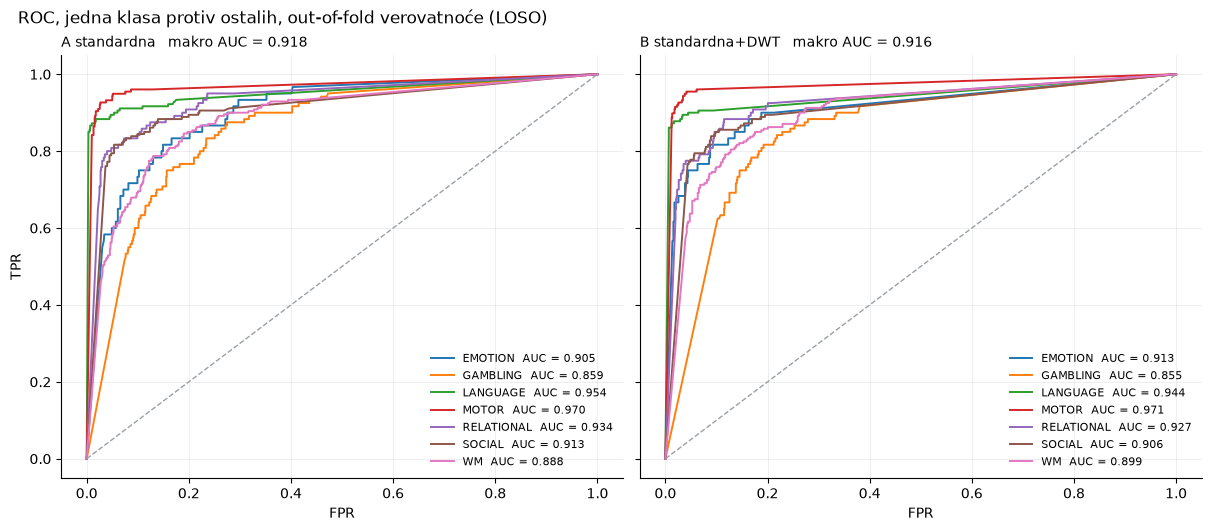

In [45]:
# Matrica konfuzije opisuje jednu tačku odlučivanja — onu u kojoj se bira najverovatnija klasa.
# ROC umesto toga prolazi kroz sve pragove. Klasa je sedam, pa ide jedna protiv ostalih, a
# verovatnoće su out-of-fold iz LOSO, nikad iz podele u kojoj je model učio. Prag se pomera ručno,
# umesto pozivom roc_curve, pa se postupak može opisati u radu.
KLASE = np.unique(yw)                          # kolone verovatnoća prate sortirane klase
proba = {}
for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all)]:
    proba[tag], _ = oof_verovatnoce(F)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
for ax, tag in zip(axes, proba):
    auc = auc_po_klasi(yw, proba[tag], KLASE)
    for k, task in enumerate(KLASE):
        kriva = roc_kriva((yw == task).astype(int), proba[tag][:, k])
        ax.plot(kriva[:, 0], kriva[:, 1], lw=1.4, label=f"{task}  AUC = {auc[task]:.3f}")
    ax.plot([0, 1], [0, 1], lw=1, ls="--", color=MUTED)
    ax.set_xlabel("FPR")
    ax.set_title(f"{tag}   makro AUC = {np.mean(list(auc.values())):.3f}")
    ax.legend(fontsize=8, frameon=False, loc="lower right")
axes[0].set_ylabel("TPR")
fig.suptitle("ROC, jedna klasa protiv ostalih, out-of-fold verovatnoće (LOSO)", x=0.01, ha="left")

# Tačnost zavisi od praga, AUC ne — zato poređenje A↔B ne visi o jednoj tački na krivoj.
for tag in proba:
    pred = KLASE[proba[tag].argmax(1)]
    print(f"{tag:20s} tačnost po maksimumu {(pred == yw).mean():.3f}")

**Kako se čita.** Svaka kriva je jedan zadatak protiv ostalih, a tačke na njoj su pragovi od 0 do 1 nad out-of-fold verovatnoćom `P(c | x)`. `AUC` je površina ispod krive, `makro AUC` njihov prosek po zadacima, a isprekidana dijagonala slučajno pogađanje. Ispis daje tačnost u tački maksimuma verovatnoće, dakle onu istu koju opisuje matrica konfuzije iznad.

Uparen test razlike B − A po ispitaniku.

In [46]:
a_std = loso_tacnost(F_std)
a_all = loso_tacnost(F_all)
uparena_razlika(a_all, a_std, "B − A, razlika po ispitaniku:")

B − A, razlika po ispitaniku:      +0.016 ± 0.046   pozitivnih 15/30   p=0.078


(array([ 0.02777778, -0.02777778,  0.02777778, -0.02777778,  0.05555556,
         0.        , -0.05555556, -0.02777778,  0.05555556,  0.08333333,
         0.        ,  0.11111111, -0.02777778,  0.12121212, -0.02777778,
         0.02777778,  0.02777778, -0.02777778, -0.02777778,  0.02777778,
         0.02777778, -0.02777778,  0.05555556,  0.        ,  0.11111111,
        -0.02777778,  0.02777778,  0.02777778,  0.        , -0.02777778]),
 np.float64(0.0778096994167983))

**Kako se čita.** Prvi red je uparena razlika B − A po ispitaniku: prosek ± rasipanje i broj ispitanika u plusu. Drugi red je pun ispis Wilcoxonovog testa, sa statistikom i p-vrednošću.

Kontrola bez obeležja snage po opsezima, da li DWT pomaže kad u skupu nema duplikata.

In [47]:
F_nob     = np.concatenate(blocks[len(BANDS):], axis=1).astype(np.float32)   # bez band_*
F_nob_dwt = np.concatenate([F_nob, F_dwt], axis=1)

res = {}
for tag, F in [("bez band_*", F_nob), ("bez band_* + DWT", F_nob_dwt),
               ("A standardna", F_std), ("B standardna+DWT", F_all)]:
    res[tag] = loso_tacnost(F)
    print(f"{tag:20s} {F.shape[1]:5d} obeležja   LOSO {res[tag].mean():.3f} ± {res[tag].std():.3f}")

print()
for a, b in [("bez band_*", "bez band_* + DWT"), ("A standardna", "B standardna+DWT")]:
    uparena_razlika(res[b], res[a], f"{b} − {a}:")

bez band_*             348 obeležja   LOSO 0.705 ± 0.210
bez band_* + DWT      1218 obeležja   LOSO 0.727 ± 0.204
A standardna           783 obeležja   LOSO 0.734 ± 0.210
B standardna+DWT      1653 obeležja   LOSO 0.750 ± 0.205

bez band_* + DWT − bez band_*:     +0.022 ± 0.058   pozitivnih 17/30   p=0.048
B standardna+DWT − A standardna:   +0.016 ± 0.046   pozitivnih 15/30   p=0.078


**Kako se čita.** Četiri reda su tačnosti četiri skupa obeležja, uz dimenziju svakog. Ispod su dva uparena poređenja: prvo unutar skupa iz kog su izbačena obeležja snage, drugo u punom skupu.

Obeležja vremenske lokalizacije koeficijenata, kao alternativa energiji i entropiji.

In [48]:
loc = []
for c in coeffs:                                   # c: (n, len_k, 87)
    a = np.abs(c)
    q = np.sort(c ** 2, axis=1)[:, ::-1, :]        # energija, opadajuće
    k = max(1, int(0.1 * c.shape[1]))
    loc += [a.var(axis=1),                                        # rasipanje |koef.|
            a.max(axis=1),                                        # najveći koeficijent
            q[:, :k, :].sum(axis=1) / np.maximum(q.sum(axis=1), 1e-12)]   # koncentracija

F_loc     = np.concatenate(loc, axis=1).astype(np.float32)
F_all2    = np.concatenate([F_std, F_loc], axis=1)
LOC_NAMES = [f"{p}_{s}:{r}" for s in SUB for p in ("V", "M", "K") for r in names]

for tag, F in [("A standardna", F_std), ("B2 standardna+DWT_lok", F_all2)]:
    res[tag] = loso_tacnost(F)
    print(f"{tag:24s} {F.shape[1]:5d}   LOSO {res[tag].mean():.3f} ± {res[tag].std():.3f}")

uparena_razlika(res["B2 standardna+DWT_lok"], res["A standardna"], "vremenska lokalizacija − A:")

A standardna               783   LOSO 0.734 ± 0.210
B2 standardna+DWT_lok     2088   LOSO 0.752 ± 0.213
vremenska lokalizacija − A:        +0.019 ± 0.048   pozitivnih 17/30   p=0.080


(array([ 0.05555556,  0.02777778,  0.        ,  0.02777778,  0.11111111,
         0.02777778, -0.02777778,  0.05555556,  0.08333333,  0.05555556,
         0.05555556,  0.11111111,  0.        ,  0.09090909,  0.02777778,
        -0.05555556,  0.        , -0.05555556,  0.        ,  0.05555556,
         0.        , -0.05555556,  0.02777778,  0.        ,  0.02777778,
        -0.05555556,  0.02777778,  0.02777778, -0.02777778, -0.05555556]),
 np.float64(0.0801002445207091))

**Kako se čita.** Dva reda su tačnost skupa A i tačnost skupa u kom su DWT obeležja zamenjena merama vremenske lokalizacije koeficijenata. Ispod je uparena razlika između njih.

Bira regularizaciju `C` za logističku regresiju na validacionom skupu i prijavljuje rezultate oba skupa.

In [49]:
# C se bira samo nad skupom A pa primenjuje na oba, da poređenje A↔B ne dobije
# prednost od dvostrukog podešavanja. Mreža ide do 100 jer je val monotono rastao do
# poslednje isprobane vrednosti, pa optimum nije bio unutar opsega.
CS, val_c = (0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0), {}
print(f"{'C':>8s} {'val A':>7s} {'val B':>7s}")
for Cv in CS:
    lr_c = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=Cv))
    val_c[Cv] = [tacnost_na(F, "val", model=lr_c) for F in (F_std, F_all)]
    print(f"{Cv:8.3f} {val_c[Cv][0]:7.3f} {val_c[Cv][1]:7.3f}", flush=True)

C_BEST = max(CS, key=lambda cc: val_c[cc][0])                 # bira se po skupu A
print(f"\nizabrano C = {C_BEST}  (po val skupu A)")
if C_BEST == max(CS):
    print("UPOZORENJE: optimum je na gornjoj ivici mreže — proširi CS pre nego što ovo uđe u rad")
print()

LR = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=C_BEST))
for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all)]:
    a = loso_tacnost(F, model=LR)
    t = tacnost_na(F, "test", model=LR)
    res["LR " + tag] = a
    print(f"LR {tag:20s} test {t:.3f}   LOSO {a.mean():.3f} ± {a.std():.3f}   "
          f"opseg {a.min():.2f}–{a.max():.2f}")

print()
uparena_razlika(res["LR B standardna+DWT"], res["LR A standardna"], "LR razlika B − A:")

       C   val A   val B
   0.003   0.770   0.822
   0.010   0.775   0.817
   0.030   0.789   0.812
   0.100   0.789   0.812
   0.300   0.793   0.817
   1.000   0.798   0.822
   3.000   0.812   0.836
  10.000   0.817   0.831
  30.000   0.808   0.826
 100.000   0.808   0.826

izabrano C = 10.0  (po val skupu A)

LR A standardna         test 0.829   LOSO 0.835 ± 0.139   opseg 0.36–0.97
LR B standardna+DWT     test 0.847   LOSO 0.859 ± 0.128   opseg 0.42–1.00

LR razlika B − A:                  +0.023 ± 0.039   pozitivnih 17/30   p=0.003


(array([ 0.02777778,  0.        ,  0.11111111,  0.        ,  0.        ,
         0.        ,  0.05555556,  0.02777778,  0.02777778,  0.02777778,
         0.05555556, -0.02777778,  0.02777778,  0.06060606,  0.        ,
        -0.02777778, -0.02777778,  0.11111111,  0.        ,  0.        ,
        -0.02777778, -0.02777778,  0.02777778,  0.05555556,  0.05555556,
         0.05555556,  0.02777778,  0.02777778,  0.08333333, -0.02777778]),
 np.float64(0.0025581735473518626))

**Kako se čita.** `C` je inverzna jačina regularizacije: veće `C` znači slabiju regularizaciju. `val A` i `val B` su tačnosti na validacionom skupu za dva skupa obeležja, a bira se isključivo po koloni `val A`. Ispod su rezultati oba skupa sa izabranim `C` i uparena razlika.

Kriva tačnosti u zavisnosti od broja zadržanih obeležja, sa selekcijom unutar svakog folda.

    k      A standardna   B standardna+DWT   B-A
   10      0.421 ± 0.11       0.421 ± 0.11   +0.000 p=nan
   25      0.580 ± 0.15       0.574 ± 0.14   -0.005 p=0.738
   50      0.664 ± 0.15       0.639 ± 0.15   -0.025 p=0.066
  100      0.711 ± 0.16       0.729 ± 0.15   +0.018 p=0.104
  200      0.721 ± 0.18       0.726 ± 0.17   +0.005 p=0.698
  400      0.737 ± 0.20       0.743 ± 0.19   +0.006 p=0.624
  800      0.734 ± 0.21       0.751 ± 0.20   +0.017 p=0.082
 None      0.734 ± 0.21       0.750 ± 0.20   +0.016 p=0.078


Text(0.0, 1.0, 'Uticaj dimenzionalnosti na Naivni Bayes')

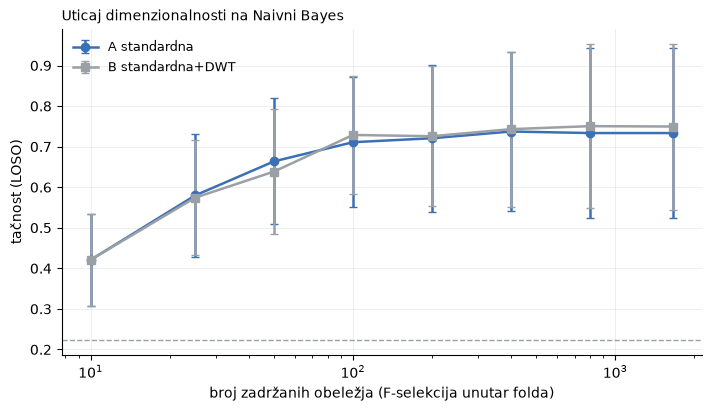

In [50]:
# Naivni Bayes pretpostavlja nezavisnost obeležja, a skup B ima 1653 međusobno korelisana
# obeležja na 1077 prozora. Selekcija po F-vrednosti radi se unutar svakog folda: ako se
# radi jednom nad celim skupom, u ocenu se uračunava i informacija iz test folda.
KS = [10, 25, 50, 100, 200, 400, 800, None]
sel_curve = {}
print(f"{'k':>5s} " + "  ".join(f"{t:>17s}" for t in ("A standardna", "B standardna+DWT")) + "   B-A")
for k in KS:
    row = []
    for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all)]:
        a = []
        for tr, te in LOSO:
            if k is None:
                sub = slice(None)
            else:
                Fs_, _ = f_classif(F[tr], yw[tr])
                sub = np.argsort(-np.nan_to_num(Fs_))[:k]
            a.append(GaussianNB().fit(F[tr][:, sub], yw[tr]).score(F[te][:, sub], yw[te]))
        sel_curve[tag, k] = np.array(a)
        row.append(f"{np.mean(a):.3f} ± {np.std(a):.2f}")
    d  = sel_curve["B standardna+DWT", k] - sel_curve["A standardna", k]
    p_ = float("nan") if np.allclose(d, 0) else wilcoxon(
        sel_curve["B standardna+DWT", k], sel_curve["A standardna", k]).pvalue
    print(f"{str(k):>5s} " + "  ".join(f"{v:>17s}" for v in row) + f"   {d.mean():+.3f} "
          f"p={p_:.3f}", flush=True)

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
xs = [k if k else len(ALL_NAMES) for k in KS]
for tag, mk in (("A standardna", "o"), ("B standardna+DWT", "s")):
    ax.errorbar(xs, [sel_curve[tag, k].mean() for k in KS],
                yerr=[sel_curve[tag, k].std() for k in KS], marker=mk, ms=6, lw=1.8, capsize=3,
                color=ACCENT if tag.startswith("A") else MUTED, label=tag)
ax.set_xscale("log")
ax.axhline(CHANCE, lw=1, color=MUTED, ls="--")
ax.set_xlabel("broj zadržanih obeležja (F-selekcija unutar folda)")
ax.set_ylabel("tačnost (LOSO)")
ax.legend(frameon=False, fontsize=9)
ax.set_title("Uticaj dimenzionalnosti na Naivni Bayes")

**Kako se čita.** `k` je broj zadržanih obeležja, `None` znači da se koriste sva. Dve kolone su tačnosti skupova A i B, a `B-A` njihova razlika sa p-vrednošću uparenog testa. Selekcija se ponavlja unutar svakog folda.

Razlaganje dobitka po zadatku i makro F1.

In [51]:
# U kojoj meri DWT može da pomogne nekim klasama a
# odmogne drugim, što se u zbirnoj tačnosti poništi.
pred = {tag: oof_predikcije(F)
        for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all)]}

print(f"{'zadatak':12s} {'n':>4s} {'A':>7s} {'B':>7s} {'B-A':>8s}")
for c in sorted(set(yw)):
    m  = yw == c
    ra = (pred["A standardna"][m] == c).mean()
    rb = (pred["B standardna+DWT"][m] == c).mean()
    print(f"{c:12s} {m.sum():4d} {ra:7.3f} {rb:7.3f} {rb - ra:+8.3f}")
print(f"{'makro F1':12s} {'':4s} {f1_score(yw, pred['A standardna'], average='macro'):7.3f} "
      f"{f1_score(yw, pred['B standardna+DWT'], average='macro'):7.3f}")
print(f"{'ukupno':12s} {len(yw):4d} {(pred['A standardna'] == yw).mean():7.3f} "
      f"{(pred['B standardna+DWT'] == yw).mean():7.3f}")

zadatak         n       A       B      B-A
EMOTION        60   0.600   0.617   +0.017
GAMBLING      120   0.625   0.667   +0.042
LANGUAGE      180   0.867   0.861   -0.006
MOTOR         177   0.864   0.898   +0.034
RELATIONAL    120   0.767   0.708   -0.058
SOCIAL        180   0.789   0.778   -0.011
WM            240   0.575   0.637   +0.062
makro F1            0.713   0.739
ukupno       1077   0.735   0.751


**Kako se čita.** Po zadatku: broj prozora te klase, tačnost skupa A, tačnost skupa B i njihova razlika. Poslednja dva reda su makro F1, koji sve klase broji jednako, i ukupna tačnost, koja ih broji srazmerno veličini.

Agregacija predikcija sa nivoa prozora na nivo run-a, glasanjem i preko verovatnoća.

In [52]:
# Predikcija je po prozoru, a svi prozori jednog run-a nose istu tačnu oznaku. Agregacija po
# runu nije prenos informacije kroz podelu nego pravilo odlučivanja: prozori se ne mešaju
# između runova, a ceo run ostaje unutar jednog folda jer je podela po ispitanicima. Dva
# pravila: većinsko glasanje nad predikcijama i prosek klasnih verovatnoća.
run_id = srcw[:, 0]                                  # indeks run-a za svaki prozor
CLS_NB = np.unique(yw)
RUN_Y  = np.array([yw[run_id == r_][0] for r_ in np.unique(run_id)])
print("prozora po runu:", dict(sorted(collections.Counter(
      collections.Counter(run_id).values()).items())), f"   runova: {len(RUN_Y)}")
print("runova po klasi:", dict(sorted(collections.Counter(RUN_Y).items(), key=lambda t: -t[1])))
print(f"granica po prozoru {CHANCE:.3f}   granica po runu "
      f"{max(collections.Counter(RUN_Y).values()) / len(RUN_Y):.3f}\n")

print(f"{'skup':20s} {'po prozoru':>12s} {'run: glasanje':>15s} {'run: verovatnoće':>18s}")
agg = {}
for tag, F in [("A standardna", F_std), ("B standardna+DWT", F_all)]:
    po_prozoru, po_glasanju, po_verovatnoci = [], [], []
    for tr, te in LOSO:
        m   = GaussianNB().fit(F[tr], yw[tr])
        pw  = m.predict(F[te])
        prb = m.predict_proba(F[te])
        po_prozoru.append((pw == yw[te]).mean())

        rid, glas, verov = run_id[te], 0, 0
        for r_ in np.unique(rid):
            sel  = rid == r_
            true = yw[te][sel][0]
            glas  += collections.Counter(pw[sel]).most_common(1)[0][0] == true
            verov += CLS_NB[prb[sel].mean(0).argmax()] == true
        n_ = len(np.unique(rid))
        po_glasanju.append(glas / n_)
        po_verovatnoci.append(verov / n_)

    agg[tag] = {"prozor": np.array(po_prozoru), "glas": np.array(po_glasanju),
                "verov":  np.array(po_verovatnoci)}
    print(f"{tag:20s} {np.mean(po_prozoru):.3f} ± {np.std(po_prozoru):.2f} "
          f"{np.mean(po_glasanju):9.3f} ± {np.std(po_glasanju):.2f} "
          f"{np.mean(po_verovatnoci):12.3f} ± {np.std(po_verovatnoci):.2f}")

print()
for tag in agg:
    uparena_razlika(agg[tag]["verov"], agg[tag]["prozor"], f"{tag}: verovatnoće − prozor:")
print()
uparena_razlika(agg["B standardna+DWT"]["verov"], agg["A standardna"]["verov"],
                "B − A po run-u (verovatnoće):")

prozora po runu: {1: 60, 2: 120, 3: 179, 4: 60}    runova: 419
runova po klasi: {np.str_('EMOTION'): 60, np.str_('GAMBLING'): 60, np.str_('LANGUAGE'): 60, np.str_('RELATIONAL'): 60, np.str_('SOCIAL'): 60, np.str_('WM'): 60, np.str_('MOTOR'): 59}
granica po prozoru 0.223   granica po runu 0.143

skup                   po prozoru   run: glasanje   run: verovatnoće
A standardna         0.734 ± 0.21     0.729 ± 0.20        0.746 ± 0.21
B standardna+DWT     0.750 ± 0.20     0.736 ± 0.20        0.758 ± 0.21

A standardna: verovatnoće − prozor: +0.012 ± 0.075   pozitivnih 18/30   p=0.249
B standardna+DWT: verovatnoće − prozor: +0.008 ± 0.052   pozitivnih 15/30   p=0.475

B − A po run-u (verovatnoće):      +0.012 ± 0.070   pozitivnih 10/30   p=0.442


(array([ 0.        ,  0.        ,  0.        , -0.14285714,  0.07142857,
         0.07142857, -0.14285714,  0.        ,  0.07142857,  0.        ,
         0.        ,  0.07142857, -0.07142857,  0.15384615,  0.        ,
         0.07142857,  0.        ,  0.        ,  0.        ,  0.14285714,
         0.        ,  0.        ,  0.        ,  0.        ,  0.07142857,
        -0.14285714,  0.        ,  0.        ,  0.07142857,  0.07142857]),
 np.float64(0.44153575639707054))

**Kako se čita.** Prvi blok daje koliko prozora ima po run-u i koliko runova po klasi, uz dve granice: po prozoru i po run-u. Tabela poredi tačnost po prozoru sa dva načina agregacije na nivo run-a. Ispod su uparena poređenja tih načina.

## HMMN rekreacija

Rekonstruiše svih 2L+1 podopsega inverznom DWT, kako model iz rada [01] i traži.

In [53]:
NREG, TW = Xw.shape[2], Xw.shape[1]      # R je u ćeliji 16 prevezan na listu desnih regiona
NYQ = 1 / (2 * TR)

base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=0.1))
EYE  = np.eye(NREG, dtype=bool)

# Za razliku od ćelije 23, koja obeležja gradi od DWT koeficijenata, HMMN radi nad
# rekonstruisanim signalom podopsega: mesh se procenjuje nad nizovima pune dužine TW,
# pa su svi podopsezi uporedivi. A_l = A_{l+1} + D_{l+1}, pa jedna dekompozicija daje svih 2L+1.
c, XS = pywt.wavedec(Xw, WAVELET, level=L, axis=1), {}      # [cA_L, cD_L, ..., cD_1]
for k in range(L + 1):
    z = [ci if j == k else np.zeros_like(ci) for j, ci in enumerate(c)]
    XS[f"A{L}" if k == 0 else f"D{L - k + 1}"] = \
        pywt.waverec(z, WAVELET, axis=1)[:, :TW, :].astype(np.float32)
for l in range(L - 1, 0, -1):
    XS[f"A{l}"] = XS[f"A{l + 1}"] + XS[f"D{l + 1}"]
XS["A0"] = XS["A1"] + XS["D1"]                              # = originalni signal

HBAND = ["A0"] + [f"A{l}" for l in range(1, L + 1)] + [f"D{l}" for l in range(1, L + 1)]
print(f"{len(HBAND)} podopsega (2L+1, L={L}):", HBAND)
print(f"rekonstrukcija A0 − original, maks. odstupanje: {np.abs(XS['A0'] - Xw).max():.2e}")
for s in HBAND[1:]:
    lo, hi = opseg(s)
    print(f"  {s:3s}  {lo:.3f}–{hi:.3f} Hz")

9 podopsega (2L+1, L=4): ['A0', 'A1', 'A2', 'A3', 'A4', 'D1', 'D2', 'D3', 'D4']
rekonstrukcija A0 − original, maks. odstupanje: 1.67e-06
  A1   0.000–0.347 Hz
  A2   0.000–0.174 Hz
  A3   0.000–0.087 Hz
  A4   0.000–0.043 Hz
  D1   0.347–0.694 Hz
  D2   0.174–0.347 Hz
  D3   0.087–0.174 Hz
  D4   0.043–0.087 Hz


**Kako se čita.** Spisak podopsega ima `2L+1` članova. Red o rekonstrukciji je provera ispravnosti: zbir svih delova mora dati originalni signal, pa se ispisuje najveće odstupanje. Ispod je frekvencijski opseg svakog podopsega.

Pretraga broja suseda i regularizacije λ na validacionom skupu; izabrani par koriste sve ćelije niže.

In [54]:
# Produžena mreža + granica λ→∞ (a ∝ G[s,r], korelacija na p suseda).
# Ako mesh ne nadmaši tu granicu, rebrasta regresija ne donosi ništa pri TW=176.
G0 = gram(XS["A0"])                                         # (n, R, R) Gramove matrice

MESH_VAL = {}
for pm in (10, 20, 40):
    NB = susedi(G0, pm)
    for lam in (512.0, 2048.0, 8192.0, 32768.0, np.inf):
        M = mesh_tezine(G0, NB, lam)
        MESH_VAL[pm, lam] = tacnost_na(M, "val", model=base)
        tag = "    →∞" if np.isinf(lam) else f"{lam:6.0f}"
        print(f"  p={pm:2d}  λ={tag}   val {MESH_VAL[pm, lam]:.3f}", flush=True)
    print(flush=True)

# Granica λ→∞ je dijagnostika, a ne kandidat: u njoj mesh prestaje da bude regresija, a
# ćelije niže množe LAM jediničnom matricom, pa beskonačno λ nema smisla proslediti.
# Izbor je zato nad konačnim λ i po val skupu; kod izjednačenja bira se manje p pa manje λ,
# da rezultat ne zavisi od redosleda prolaska kroz rečnik.
P_MESH, LAM = min((k for k in MESH_VAL if np.isfinite(k[1])),
                  key=lambda k: (-MESH_VAL[k], k[0], k[1]))
print(f"izabrano: p = {P_MESH}, λ = {LAM:.0f}   val {MESH_VAL[P_MESH, LAM]:.3f}   "
      f"(λ→∞ pri istom p: {MESH_VAL[P_MESH, np.inf]:.3f})")

  p=10  λ=   512   val 0.850
  p=10  λ=  2048   val 0.845
  p=10  λ=  8192   val 0.850
  p=10  λ= 32768   val 0.850
  p=10  λ=    →∞   val 0.850

  p=20  λ=   512   val 0.887
  p=20  λ=  2048   val 0.854
  p=20  λ=  8192   val 0.836
  p=20  λ= 32768   val 0.836
  p=20  λ=    →∞   val 0.836

  p=40  λ=   512   val 0.887
  p=40  λ=  2048   val 0.864
  p=40  λ=  8192   val 0.831
  p=40  λ= 32768   val 0.822
  p=40  λ=    →∞   val 0.831

izabrano: p = 20, λ = 512   val 0.887   (λ→∞ pri istom p: 0.836)


**Kako se čita.** `p` je broj suseda po regionu, `λ` jačina regularizacije, `val` tačnost na validacionom skupu. Red `λ→∞` je granični slučaj u kom lučna težina postaje obična korelacija na tih `p` suseda. Poslednji red navodi izabran par i vrednost granice pri istom `p`.

Gradi tri reprezentacije po podopsegu: mesh lučne težine, parne korelacije i originalne nizove.

In [55]:
iu   = np.triu_indices(NREG, 1)
FEAT = {"mesh": {}, "korel": {}, "nizovi": {}}

for b in HBAND:
    G = gram(XS[b])
    FEAT["mesh"][b]   = mesh_tezine(G, susedi(G, P_MESH), LAM)   # graf je usmeren -> cela R×R
    FEAT["korel"][b]  = (G / TW)[:, iu[0], iu[1]].astype(np.float32)
    FEAT["nizovi"][b] = XS[b].reshape(len(XS[b]), -1)
    print(f"  {b:3s} gotovo", flush=True)

print({k: FEAT[k]["A0"].shape[1] for k in FEAT}, "obeležja po podopsegu")

  A0  gotovo
  A1  gotovo
  A2  gotovo
  A3  gotovo
  A4  gotovo
  D1  gotovo
  D2  gotovo
  D3  gotovo
  D4  gotovo
{'mesh': 7569, 'korel': 3741, 'nizovi': 15312} obeležja po podopsegu


**Kako se čita.** Rečnik daje broj obeležja po podopsegu za svaku reprezentaciju: mesh koristi celu matricu regiona jer je graf usmeren, korelacije samo njen gornji trougao, a sirovi nizovi sve odbirke svih regiona.

Prikazuje prosečnu mesh mrežu na mozgu, sa najjačim lukovima.

/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


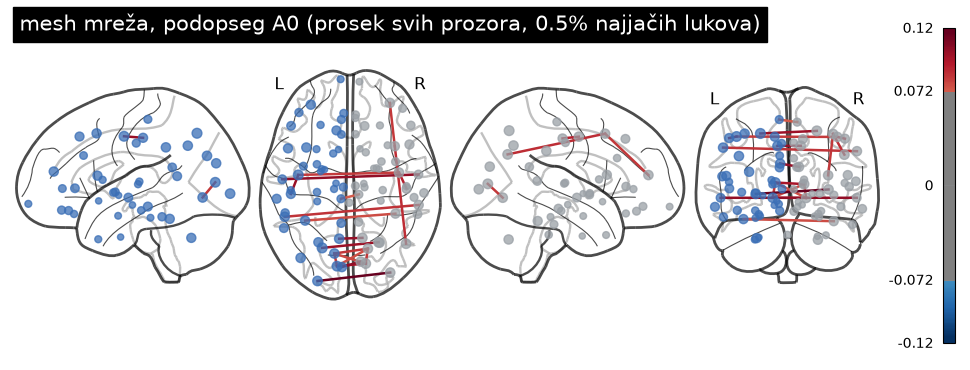

In [56]:
assert len(names) == NREG, "names je prepisan — pokreni ćeliju sa DESIKAN pa ovu"

w      = nib.load(str(ROOT / "data" / SUBJECT / "MNINonLinear/ROIs/wmparc.2.nii.gz"))
codes3 = w.get_fdata().astype(np.int32)
COORDS = np.array([nib.affines.apply_affine(w.affine,
                   np.array(np.nonzero(codes3 == c)).mean(1)) for c in CODE_LIST])

BAND = "A0"
Wm = FEAT["mesh"][BAND].mean(0).reshape(NREG, NREG)
A  = (Wm + Wm.T) / 2                      # plot_connectome traži simetričnu matricu,
np.fill_diagonal(A, 0)                    # a mesh graf je usmeren -> prikazuje se prosek smerova

strength = np.abs(A).sum(1)
plotting.plot_connectome(
    A, COORDS,
    edge_threshold="99.5%",
    node_size=8 + 42 * strength / strength.max(),
    node_color=[ACCENT if n.startswith("L_") else MUTED for n in names],
    node_kwargs={"alpha": 0.75},
    edge_kwargs={"linewidth": 1.8},
    edge_cmap="RdBu_r", display_mode="lzry",
    title=f"mesh mreža, podopseg {BAND} (prosek svih prozora, 0.5% najjačih lukova)")

**Kako se čita.** Čvorovi su centroidi regiona u MNI prostoru, veličina čvora je ukupna jačina njegovih veza, a boja razlikuje hemisfere. Crtaju se samo najjači lukovi, prema pragu zadatom u pozivu. Pošto je mesh graf usmeren, prikazuje se prosek dva smera.

Mesh varijanta u kojoj se susedi biraju ortogonalnim uparivanjem umesto po korelaciji.

In [57]:
FEAT["mesh-OMP"] = {}
for b in HBAND:
    C_all = (gram(XS[b]) / TW).astype(np.float64)
    M     = np.zeros((len(Xw), NREG, NREG), np.float32)
    for i in range(len(Xw)):
        for r in range(NREG):
            S, a = omp_susedi(C_all[i], r, P_MESH, LAM / TW)
            M[i, r, S] = a
    FEAT["mesh-OMP"][b] = M.reshape(len(M), -1)
    print(f"  {b:3s} gotovo", flush=True)

  A0  gotovo
  A1  gotovo
  A2  gotovo
  A3  gotovo
  A4  gotovo
  D1  gotovo
  D2  gotovo
  D3  gotovo
  D4  gotovo


Tačnost svake reprezentacije na svakom podopsegu, uz verovatnoće koje meta sloj traži.

In [58]:
# Jedan prolaz daje i tačnost baznog klasifikatora i verovatnoće koje meta sloj traži.
# Meta se uči na out-of-fold verovatnoćama, podelom po ispitanicima unutar trening skupa,
# inače bi učio na precenjenim verovatnoćama i fuzija bi bila lažno dobra.
CLS, PTR, PTE, WT, base_acc = np.unique(yw), {}, {}, {}, {}
NC = len(CLS)

for k in FEAT:
    for b in HBAND:
        F, a = FEAT[k][b], []
        for fi, (tr, te) in enumerate(LOSO):
            P = np.zeros((len(tr), NC))
            for itr, ite in GroupKFold(n_splits=3).split(tr, yw[tr], gw[tr]):
                P[ite] = clone(base).fit(F[tr][itr], yw[tr][itr]).predict_proba(F[tr][ite])
            m = clone(base).fit(F[tr], yw[tr])
            PTR[k, b, fi] = P
            PTE[k, b, fi] = m.predict_proba(F[te])
            WT[k, b, fi]  = m.score(F[tr], yw[tr])          # težina za WMV
            a.append(m.score(F[te], yw[te]))
        base_acc[k, b] = np.array(a)
        print(f"  {k:6s} {b:3s}  LOSO {base_acc[k, b].mean():.3f} ± {base_acc[k, b].std():.3f}",
              flush=True)

print(f"\n{'nivo':5s} " + "  ".join(f"{k:>13s}" for k in FEAT))
for b in HBAND:
    print(f"{b:5s} " + "  ".join(
        f"{base_acc[k, b].mean():.3f}±{base_acc[k, b].std():.2f}".rjust(13) for k in FEAT))
print(f"{'većina':5s} {CHANCE:13.3f}")

  mesh   A0   LOSO 0.907 ± 0.094
  mesh   A1   LOSO 0.906 ± 0.100
  mesh   A2   LOSO 0.910 ± 0.090
  mesh   A3   LOSO 0.889 ± 0.094
  mesh   A4   LOSO 0.863 ± 0.106
  mesh   D1   LOSO 0.260 ± 0.109
  mesh   D2   LOSO 0.354 ± 0.101
  mesh   D3   LOSO 0.650 ± 0.131
  mesh   D4   LOSO 0.751 ± 0.104
  korel  A0   LOSO 0.894 ± 0.113
  korel  A1   LOSO 0.884 ± 0.121
  korel  A2   LOSO 0.892 ± 0.113
  korel  A3   LOSO 0.891 ± 0.104
  korel  A4   LOSO 0.868 ± 0.112
  korel  D1   LOSO 0.287 ± 0.087
  korel  D2   LOSO 0.369 ± 0.107
  korel  D3   LOSO 0.671 ± 0.128
  korel  D4   LOSO 0.781 ± 0.105
  nizovi A0   LOSO 0.956 ± 0.052
  nizovi A1   LOSO 0.961 ± 0.048
  nizovi A2   LOSO 0.961 ± 0.050
  nizovi A3   LOSO 0.953 ± 0.047
  nizovi A4   LOSO 0.892 ± 0.076
  nizovi D1   LOSO 0.208 ± 0.065
  nizovi D2   LOSO 0.441 ± 0.114
  nizovi D3   LOSO 0.711 ± 0.115
  nizovi D4   LOSO 0.777 ± 0.078
  mesh-OMP A0   LOSO 0.919 ± 0.108
  mesh-OMP A1   LOSO 0.918 ± 0.087
  mesh-OMP A2   LOSO 0.910 ± 0.083
  me

**Kako se čita.** Za svaku reprezentaciju i svaki podopseg, tačnost kao prosek ± rasipanje preko foldova. Zbirna tabela ispod ima podopsege po redovima i reprezentacije po kolonama, uz većinsku klasu u poslednjem redu.

Fuzija odluka preko podopsega: FSG, obično i otežano glasanje.

In [59]:
# Bazne verovatnoće su već izračunate, pa je fuzija za bilo koji podskup samo nadovezivanje.
# Rad varira E od 2 do 2L; podopsezi se dodaju opadajuće po sopstvenoj tačnosti.
fus = {}
for k in FEAT:
    order = sorted(HBAND, key=lambda b: -base_acc[k, b].mean())
    print(f"\n{k}   redosled: {order}")
    print(f"{'E':>3s} " + "  ".join(f"{c:>13s}" for c in ("FSG-L", "FSG-S", "MV", "WMV")))
    for E in range(2, len(HBAND) + 1):
        acc = {c: [] for c in ("FSG-L", "FSG-S", "MV", "WMV")}
        for fi, (tr, te) in enumerate(LOSO):
            sel = order[:E]
            Ptr = np.hstack([PTR[k, b, fi] for b in sel])   # (n_tr, C·E)
            Pte = np.hstack([PTE[k, b, fi] for b in sel])
            Q   = np.stack([PTE[k, b, fi] for b in sel])    # (E, n_te, C)
            w   = np.array([WT[k, b, fi] for b in sel])
            acc["FSG-L"].append(clone(base).fit(Ptr, yw[tr]).score(Pte, yw[te]))
            acc["FSG-S"].append(make_pipeline(StandardScaler(), LinearSVC(C=1.0))
                                .fit(Ptr, yw[tr]).score(Pte, yw[te]))
            v = np.zeros((len(te), NC))
            for e in range(E):
                v[np.arange(len(te)), Q[e].argmax(1)] += 1
            acc["MV"].append((CLS[v.argmax(1)] == yw[te]).mean())
            acc["WMV"].append((CLS[(Q * w[:, None, None]).sum(0).argmax(1)] == yw[te]).mean())
        fus[k, E] = {c: np.array(v) for c, v in acc.items()}
        print(f"{E:3d} " + "  ".join(f"{fus[k, E][c].mean():.3f}±{fus[k, E][c].std():.2f}".rjust(13)
                                     for c in ("FSG-L", "FSG-S", "MV", "WMV")), flush=True)


mesh   redosled: ['A2', 'A0', 'A1', 'A3', 'A4', 'D4', 'D3', 'D2', 'D1']
  E         FSG-L          FSG-S             MV            WMV
  2    0.916±0.09     0.908±0.09     0.905±0.10     0.911±0.09
  3    0.911±0.09     0.906±0.09     0.915±0.10     0.914±0.10
  4    0.913±0.09     0.903±0.09     0.910±0.10     0.916±0.09
  5    0.911±0.09     0.903±0.10     0.912±0.09     0.915±0.09
  6    0.908±0.10     0.905±0.10     0.915±0.09     0.914±0.08
  7    0.911±0.09     0.902±0.09     0.914±0.10     0.910±0.09
  8    0.920±0.08     0.911±0.09     0.916±0.09     0.912±0.08
  9    0.924±0.09     0.910±0.09     0.916±0.10     0.909±0.08

korel   redosled: ['A0', 'A2', 'A3', 'A1', 'A4', 'D4', 'D3', 'D2', 'D1']
  E         FSG-L          FSG-S             MV            WMV
  2    0.890±0.12     0.884±0.12     0.889±0.12     0.892±0.12
  3    0.894±0.11     0.883±0.11     0.893±0.12     0.892±0.12
  4    0.889±0.11     0.882±0.11     0.889±0.12     0.892±0.12
  5    0.891±0.12     0.880±0.11  

**Kako se čita.** `E` je broj podopsega uključenih u fuziju, uzetih redom koji je naveden iznad tabele. Četiri kolone su četiri načina spajanja odluka: dve varijante fuzije preko meta-sloja i dva glasanja.

Grafik tačnosti po podopsegu i posle fuzije.

Text(0.01, 0.98, 'HMMN — tačnost po podopsegu i posle fuzije')

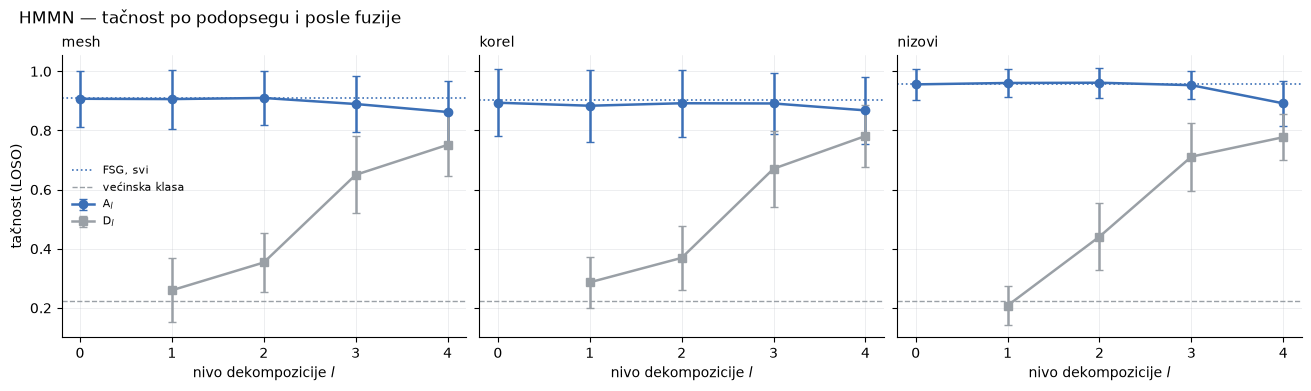

In [60]:
# Rad: tačnost A_l opada sa nivoom (do šanse na l=11), tačnost D_l raste do l=5–6.
# Kod nas L=4, pa se vidi samo početak tog trenda.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True, layout="constrained")
for ax, k in zip(axes, FEAT):
    for pref, mk, col in (("A", "o", ACCENT), ("D", "s", MUTED)):
        lv = list(range(0 if pref == "A" else 1, L + 1))
        ax.errorbar(lv, [base_acc[k, f"{pref}{l}"].mean() for l in lv],
                    yerr=[base_acc[k, f"{pref}{l}"].std() for l in lv],
                    marker=mk, ms=6, lw=1.8, capsize=3, color=col, label=f"{pref}$_l$")
    ax.axhline(fus[k, len(HBAND)]["FSG-S"].mean(), lw=1.2, color=ACCENT, ls=":", label="FSG, svi")
    ax.axhline(CHANCE, lw=1, color=MUTED, ls="--", label="većinska klasa")
    ax.set_title(k); ax.set_xlabel("nivo dekompozicije $l$"); ax.set_xticks(range(L + 1))
axes[0].set_ylabel("tačnost (LOSO)"); axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("HMMN — tačnost po podopsegu i posle fuzije", x=0.01, ha="left")

Konfiguracija iz rada [01] i njeno poređenje sa standardnim skupom obeležja.

In [61]:
# Konfiguracija iz rada, izabrana pre gledanja rezultata: mesh arc weights + FSG preko svih
# podopsega, meta sloj linearni SVM. To nije najbolja kombinacija iz prethodne ćelije, i
# namerno se ne prijavljuje najbolja, da izbor ne bi bio post hoc. Vrh se ispisuje ispod radi
# poređenja, ali se računa iz `fus`, pa ne može da zastari kad se `p` i `λ` promene.
PRAVILA = ("FSG-L", "FSG-S", "MV", "WMV")

hmmn_rad = fus["mesh", len(HBAND)]["FSG-S"]
print(f"HMMN (rad: mesh + FSG-S, E={len(HBAND)})   LOSO {hmmn_rad.mean():.3f} ± {hmmn_rad.std():.3f}")

_kmb  = [(c, E) for E in range(2, len(HBAND) + 1) for c in PRAVILA]
_best = max(_kmb, key=lambda t: fus["mesh", t[1]][t[0]].mean())
_vrh  = fus["mesh", _best[1]][_best[0]]
print(f"vrh za mesh: {_best[0]}, E={_best[1]}   LOSO {_vrh.mean():.3f}   "
      f"razlika naspram prijavljene {_vrh.mean() - hmmn_rad.mean():+.3f}   "
      f"({len(_kmb)} kombinacija po reprezentaciji, {len(_kmb) * len(FEAT)} ukupno)\n")

for tag in ("A standardna", "B standardna+DWT", "LR A standardna", "LR B standardna+DWT"):
    uparena_razlika(hmmn_rad, res[tag], f"HMMN − {tag}:")

HMMN (rad: mesh + FSG-S, E=9)   LOSO 0.910 ± 0.093
vrh za mesh: FSG-L, E=9   LOSO 0.924   razlika naspram prijavljene +0.014   (32 kombinacija po reprezentaciji, 128 ukupno)

HMMN − A standardna:               +0.176 ± 0.156   pozitivnih 25/30   p=0.000
HMMN − B standardna+DWT:           +0.160 ± 0.153   pozitivnih 25/30   p=0.000
HMMN − LR A standardna:            +0.075 ± 0.103   pozitivnih 21/30   p=0.001
HMMN − LR B standardna+DWT:        +0.051 ± 0.098   pozitivnih 17/30   p=0.010


**Kako se čita.** Prvi red je tačnost konfiguracije koju koristi rad [01]. Ispod je poređenje sa svakim skupom obeležja računatim po regionu: razlika ± rasipanje, broj ispitanika u plusu i p-vrednost uparenog testa.

Pravila izbora susedstva, njihova uslovljenost, tačnost i provera da li je uslovljenost usko grlo.

In [62]:
# Popravka koja sledi iz dijagnoze: ako mesh pada zbog uslovljenosti, menja se suseda,
# a ne regresija. Tri pravila, isto p i isto λ, razlikuje se samo susedstvo:
#   top-p  — p najkorelisanijih (pravilo iz rada; MORA da reprodukuje 0.779, to je provera)
#   OMP    — pohlepno po doprinosu ostatku; svaki sused nosi novu informaciju
#   τ=…    — pohlepno po korelaciji sa r, uz zabranu suseda korelisanijih od τ sa već izabranima
Ca  = (gram(XS["A0"]) / TW).astype(np.float64)
RID = (LAM / TW) * np.eye(P_MESH)

sel_acc = {}
for rule in ("top-p", "OMP", "τ=0.4", "τ=0.5", "τ=0.6"):
    Ms, cond_r = np.zeros((len(Xw), NREG, NREG), np.float32), []
    for i in range(len(Xw)):
        C = Ca[i]
        for r in range(NREG):
            if rule == "top-p":
                cr = C[:, r].copy()
                cr[r] = -np.inf
                S = list(np.argpartition(-cr, P_MESH)[:P_MESH])
            elif rule == "OMP":
                S, _ = omp_susedi(C, r, P_MESH, LAM / TW)
            else:
                tau, S  = float(rule.split("=")[1]), []
                order   = np.argsort(-C[:, r])
                blocked = np.zeros(NREG, bool)
                blocked[r] = True
                for j in order:
                    if blocked[j]:
                        continue
                    S.append(int(j))
                    if len(S) == P_MESH:
                        break
                    blocked |= np.abs(C[:, j]) > tau          # kolinearnost je bez znaka
                for j in order:                               # dopuna ako je τ presekao previše
                    if len(S) == P_MESH:
                        break
                    if j != r and int(j) not in S:
                        S.append(int(j))
            Ms[i, r, S] = np.linalg.solve(C[np.ix_(S, S)] + RID, C[S, r])
            cond_r.append(np.linalg.cond(C[np.ix_(S, S)]))

    a = loso_tacnost(Ms.reshape(len(Ms), -1), model=base)
    sel_acc[rule] = a
    d = a - base_acc["korel", "A0"]
    print(f"  {rule:6s}  cond {np.median(cond_r):7.1f}   LOSO {a.mean():.3f} ± {a.std():.3f}   "
          f"mesh−korel {d.mean():+.3f}  p={wilcoxon(a, base_acc['korel','A0']).pvalue:.3f}",
          flush=True)

print()
for rl in sel_acc:                              # drugo ime, da ne gazi `rule` iz petlje
    d   = sel_acc[rl] - base_acc["korel", "A0"]
    mde = (2.262 + 0.883) * d.std(ddof=1) / np.sqrt(len(d))   # dvostrani 0.05, snaga 0.80, n=10
    print(f"{rl:6s}  d = {d.mean():+.3f} ± {d.std(ddof=1):.3f}   "
          f"najmanji detektabilan efekat ≈ {mde:.3f}")

if {"OMP", "top-p"} <= sel_acc.keys():
    print()
    uparena_razlika(sel_acc["OMP"], sel_acc["top-p"], "OMP − top-p:")
else:
    print("\nnedostaje:", {"OMP", "top-p"} - sel_acc.keys(), " izvršeno:", list(sel_acc))

  top-p   cond    63.0   LOSO 0.907 ± 0.094   mesh−korel +0.013  p=0.452
  OMP     cond    40.7   LOSO 0.919 ± 0.108   mesh−korel +0.026  p=0.016
  τ=0.4   cond     9.6   LOSO 0.854 ± 0.120   mesh−korel -0.040  p=0.000
  τ=0.5   cond    14.3   LOSO 0.860 ± 0.131   mesh−korel -0.034  p=0.000
  τ=0.6   cond    21.0   LOSO 0.873 ± 0.130   mesh−korel -0.021  p=0.017

top-p   d = +0.013 ± 0.059   najmanji detektabilan efekat ≈ 0.034
OMP     d = +0.026 ± 0.082   najmanji detektabilan efekat ≈ 0.047
τ=0.4   d = -0.040 ± 0.043   najmanji detektabilan efekat ≈ 0.025
τ=0.5   d = -0.034 ± 0.045   najmanji detektabilan efekat ≈ 0.026
τ=0.6   d = -0.021 ± 0.045   najmanji detektabilan efekat ≈ 0.026

OMP − top-p:                       +0.012 ± 0.045   pozitivnih 17/30   p=0.043


**Kako se čita.** `cond` je uslovljenost matrice susedstva, `LOSO` tačnost tog pravila, a `mesh−korel` razlika u odnosu na parne korelacije na istom podopsegu. Drugi blok daje istu razliku sa rasipanjem i najmanji efekat koji se pri tom broju foldova uopšte može detektovati.

Razlika mesh naspram korelacija po dužini prozora i po λ.

In [63]:
# Hipoteza: lučna težina je ocena veće varijanse od korelacije, pa joj treba duži prozor
# (rad ima 1940 tačaka, ovde 176). Mora se meriti pri λ gde regresija još radi: pri λ=2048
# je mesh već degenerisan u korelaciju na p suseda (vidi ćeliju sa mrežom λ), pa bi se
# poredila korelacija sa korelacijom. λ=32 je vrednost iz rada.
# Poredi se razlika unutar svake dužine, sa TW se menjaju i broj prozora i odnos klasa.
for W in (88, 132, 176):
    Xv, yv, gv, _ = prozori(runs, W)
    Gv  = gram(Xv)
    NBv = susedi(Gv, P_MESH)
    lo  = loso(gv)

    Fk = (Gv / W)[:, iu[0], iu[1]].astype(np.float32)
    ak = loso_tacnost(Fk, yv, lo, model=base)
    print(f"TW={W:3d}  n={len(Xv):3d}   korel {ak.mean():.3f} ± {ak.std():.3f}")

    for lam in (8.0, 32.0, 128.0, 2048.0):
        am = loso_tacnost(mesh_tezine(Gv, NBv, lam), yv, lo, model=base)
        d  = am - ak
        print(f"   λ={lam:6.0f}  mesh {am.mean():.3f} ± {am.std():.3f}   "
              f"mesh−korel {d.mean():+.3f} ± {d.std():.3f}  p={wilcoxon(am, ak).pvalue:.3f}",
              flush=True)
    print(flush=True)

TW= 88  n=2454   korel 0.856 ± 0.122
   λ=     8  mesh 0.783 ± 0.110   mesh−korel -0.073 ± 0.048  p=0.000
   λ=    32  mesh 0.830 ± 0.113   mesh−korel -0.026 ± 0.038  p=0.002
   λ=   128  mesh 0.854 ± 0.114   mesh−korel -0.002 ± 0.038  p=0.601
   λ=  2048  mesh 0.845 ± 0.122   mesh−korel -0.011 ± 0.039  p=0.110

TW=132  n=1556   korel 0.868 ± 0.118
   λ=     8  mesh 0.798 ± 0.111   mesh−korel -0.070 ± 0.064  p=0.000
   λ=    32  mesh 0.844 ± 0.104   mesh−korel -0.023 ± 0.060  p=0.028
   λ=   128  mesh 0.880 ± 0.094   mesh−korel +0.012 ± 0.062  p=0.263
   λ=  2048  mesh 0.877 ± 0.108   mesh−korel +0.009 ± 0.051  p=0.185

TW=176  n=1077   korel 0.894 ± 0.113
   λ=     8  mesh 0.812 ± 0.133   mesh−korel -0.082 ± 0.078  p=0.000
   λ=    32  mesh 0.854 ± 0.115   mesh−korel -0.040 ± 0.064  p=0.002
   λ=   128  mesh 0.889 ± 0.106   mesh−korel -0.004 ± 0.056  p=0.748
   λ=  2048  mesh 0.898 ± 0.106   mesh−korel +0.005 ± 0.042  p=0.854



**Kako se čita.** Za svaku dužinu prozora `TW` navodi se broj dobijenih prozora `n` i tačnost korelacija, pa mesh pri četiri vrednosti `λ`, uz razliku `mesh−korel` i p-vrednost uparenog testa.

Uslovljenost matrice susedstva po dužini prozora.

In [64]:
# Zašto duži prozor ne pomaže: susedi su p najkorelisanijih regiona, dakle i međusobno
# kolinearni, pa je C_ss loše uslovljena. Kolinearnost je svojstvo populacije, ne uzorka —
# ako je stvarna, uslovljenost ostaje ravna sa TW; ako je artefakt izbora suseda iz šuma,
# opada. To razlikuje dva objašnjenja.
for W in (88, 132, 176):
    Xv, _, _, _ = prozori(runs, W)
    Gv  = gram(Xv) / W                                   # korelaciona matrica
    NBv = susedi(Gv, P_MESH)

    ut, cond, coll = np.triu_indices(P_MESH, 1), [], []
    for i in range(0, len(Xv), 3):                       # svaki treći prozor, dovoljno
        for r in range(NREG):
            Css = Gv[i][np.ix_(NBv[i, r], NBv[i, r])]
            cond.append(np.linalg.cond(Css))
            coll.append(np.abs(Css[ut]).mean())
    print(f"TW={W:3d}   cond(C_ss): medijana {np.median(cond):7.1f}  90% {np.percentile(cond, 90):8.1f}"
          f"   |korelacija| među susedima: {np.mean(coll):.3f}", flush=True)

TW= 88   cond(C_ss): medijana    81.6  90%    368.8   |korelacija| među susedima: 0.293
TW=132   cond(C_ss): medijana    67.2  90%    310.9   |korelacija| među susedima: 0.283
TW=176   cond(C_ss): medijana    66.4  90%    308.5   |korelacija| među susedima: 0.287


**Kako se čita.** Po dužini prozora: medijana i 90. percentil uslovljenosti matrice susedstva, pa prosečna apsolutna korelacija među izabranim susedima.

Fazno randomizovana kontrola: čuva spektar svakog regiona, a razbija spregu među njima.

In [65]:
# Kontrola: fazna randomizacija čuva spektar (dakle i autokorelaciju) svakog regiona, a
# nezavisnom fazom po regionu razbija spregu medju regionima. Ako je cond ≈ 31 posledica
# stvarne kolinearnosti, ovde mora da padne i da postane zavisna od TW; ako je artefakt
# argmax izbora suseda iz šuma, ostaće ista.
rng_pr, runs_pr = np.random.default_rng(0), []
for rn in runs:
    Tr = rn.shape[0]
    Fr = np.fft.rfft(rn - rn.mean(0), axis=0)          # (Tr//2+1, NREG)
    ph = rng_pr.uniform(0, 2 * np.pi, Fr.shape)        # nezavisna faza po regionu
    ph[0] = 0.0                                        # DC mora ostati realan
    if Tr % 2 == 0:
        ph[-1] = 0.0                                   # kao i Nyquist, za parno Tr
    runs_pr.append(np.fft.irfft(np.abs(Fr) * np.exp(1j * ph), n=Tr, axis=0).astype(np.float32))

ut = np.triu_indices(P_MESH, 1)
for tag, src in (("original", runs), ("fazno rand.", runs_pr)):
    for W in (88, 132, 176):
        Xv, _, _, _ = prozori(src, W)
        Gv  = gram(Xv) / W
        NBv = susedi(Gv, P_MESH)

        cond, coll = [], []
        for i in range(0, len(Xv), 3):
            for r in range(NREG):
                Css = Gv[i][np.ix_(NBv[i, r], NBv[i, r])]
                cond.append(np.linalg.cond(Css))
                coll.append(np.abs(Css[ut]).mean())
        print(f"{tag:12s} TW={W:3d}   cond: medijana {np.median(cond):7.1f}  "
              f"90% {np.percentile(cond, 90):8.1f}   |korelacija| među susedima: {np.mean(coll):.3f}",
              flush=True)
    print(flush=True)

original     TW= 88   cond: medijana    81.6  90%    368.8   |korelacija| među susedima: 0.293
original     TW=132   cond: medijana    67.2  90%    310.9   |korelacija| među susedima: 0.283
original     TW=176   cond: medijana    66.4  90%    308.5   |korelacija| među susedima: 0.287

fazno rand.  TW= 88   cond: medijana    18.6  90%     39.7   |korelacija| među susedima: 0.141
fazno rand.  TW=132   cond: medijana    11.7  90%     24.4   |korelacija| među susedima: 0.119
fazno rand.  TW=176   cond: medijana     9.0  90%     19.7   |korelacija| među susedima: 0.107



**Kako se čita.** Isti brojevi kao u ćeliji iznad, dati dvaput — za originalne podatke i za fazno randomizovane, koje čuvaju spektar svakog regiona a razbijaju spregu među njima.

Kontrola sa nasumičnim pomakom prozora, za reprezentacije zasnovane na povezanosti.

In [66]:
# Koliko tačnosti dolazi od poklapanja sa dizajnom, a koliko od reprezentacije: prozori se
# sada uzimaju sa nasumične pozicije u run-u, uz isti broj prozora po run-u — dakle isto n i
# isti odnos klasa, pa su brojevi uporedivi sa tabelom po podopsezima. Napomena za tekst:
# EMOTION run ima tačno WIN frejmova, pa se tih 20 prozora ne mogu pomeriti i ostaju
# poravnati; izmereni padovi su zato donja granica.
NREP = 3
jit  = {k: [] for k in ("nizovi", "korel", "mesh")}

for rep in range(NREP):
    Xj, yj, gj, _ = prozori(runs, WIN, STRIDE, rng=np.random.default_rng(100 + rep))
    Gj = gram(Xj)
    Fj = {"nizovi": Xj.reshape(len(Xj), -1),
          "korel":  (Gj / WIN)[:, iu[0], iu[1]].astype(np.float32),
          "mesh":   mesh_tezine(Gj, susedi(Gj, P_MESH), LAM)}
    lo = loso(gj)
    for k, Fk in Fj.items():
        jit[k].append(loso_tacnost(Fk, yj, lo, model=base).mean())
    print(f"  ponavljanje {rep + 1}/{NREP} gotovo", flush=True)

print(f"\n{'skup':8s} {'poravnato':>10s} {'pomereno':>18s} {'pad':>8s}")
for k in ("nizovi", "korel", "mesh"):
    o, j = base_acc[k, "A0"].mean(), np.array(jit[k])
    print(f"{k:8s} {o:10.3f}   {j.mean():.3f} ± {j.std():.3f}   {j.mean() - o:+8.3f}")
print(f"{'većina':8s} {CHANCE:10.3f}")

  ponavljanje 1/3 gotovo
  ponavljanje 2/3 gotovo
  ponavljanje 3/3 gotovo

skup      poravnato           pomereno      pad
nizovi        0.956   0.448 ± 0.010     -0.508
korel         0.894   0.884 ± 0.002     -0.009
mesh          0.907   0.897 ± 0.004     -0.010
većina        0.223


**Kako se čita.** `poravnato` je tačnost sa prozorima na fiksnim pozicijama, `pomereno` prosek ± rasipanje preko ponavljanja sa nasumičnim pomakom početka, a `pad` njihova razlika.

Ista kontrola pomaka, za skupove A i B.

In [67]:
# Provera glavne tvrdnje na pomerenim prozorima. Sirovi nizovi su izgubili 52 poena, a
# standardna obeležja su spektralna i autokorelaciona, dakle po konstrukciji neosetljiva
# na položaj prozora. Ako A i B prežive pomak, glavni nalaz rada stoji na čistom osnovu.
NREP2 = 3
jit2  = {"A standardna": [], "B standardna+DWT": []}
for rep in range(NREP2):
    Xj, yj, gj, _ = prozori(runs, WIN, STRIDE, rng=np.random.default_rng(200 + rep))
    Fa_ = standardna_obelezja(Xj)
    Fb_ = np.concatenate([Fa_, dwt_obelezja(Xj, WAVELET, L)], axis=1)

    lo_ = loso(gj)
    for tag, F in (("A standardna", Fa_), ("B standardna+DWT", Fb_)):
        jit2[tag].append(loso_tacnost(F, yj, lo_).mean())
    print(f"  ponavljanje {rep + 1}/{NREP2} gotovo", flush=True)

print(f"\n{'skup':20s} {'poravnato':>10s} {'pomereno':>18s} {'pad':>8s}")
for tag in ("A standardna", "B standardna+DWT"):
    ref, j = res[tag].mean(), np.array(jit2[tag])
    print(f"{tag:20s} {ref:10.3f}   {j.mean():.3f} ± {j.std():.3f}   {j.mean() - ref:+8.3f}")
print(f"{'većinska klasa':20s} {CHANCE:10.3f}")

  ponavljanje 1/3 gotovo
  ponavljanje 2/3 gotovo
  ponavljanje 3/3 gotovo

skup                  poravnato           pomereno      pad
A standardna              0.734   0.714 ± 0.002     -0.019
B standardna+DWT          0.750   0.741 ± 0.007     -0.009
većinska klasa            0.223


**Kako se čita.** Isti prikaz kao u ćeliji iznad, ovde za skupove obeležja A i B.

Zbirna figura o poravnanju obeležja sa dizajnom paradigme.

skup obeležja                 poravnato         pomereno      pad
sirovi nizovi          0.956 ± 0.052   0.448 ± 0.010     -0.508
parne korelacije       0.894 ± 0.113   0.884 ± 0.002     -0.009
mesh arc weights       0.907 ± 0.094   0.897 ± 0.004     -0.010
A standardna           0.734 ± 0.210   0.714 ± 0.002     -0.019
B standardna + DWT     0.750 ± 0.205   0.741 ± 0.007     -0.009
većinska klasa             0.223

± poravnato = po ispitanicima (LOSO);  ± pomereno = po ponavljanjima


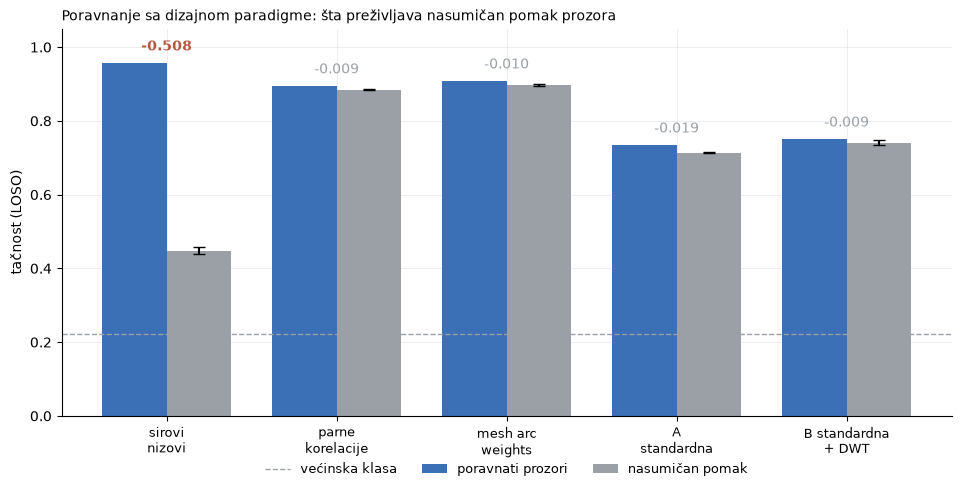

In [68]:
# Naslovna figura rada: šta preživljava nasumičan pomak prozora. Sirovi vremenski nizovi žive
# od poravnanja sa dizajnom paradigme, dok su sva obeležja koja se u radu koriste nezavisna od
# položaja prozora. Stubac „poravnato" je LOSO prosek, stubac „pomereno" je prosek preko tri
# ponavljanja, a njegova greška je standardna devijacija među ponavljanjima; standardna
# devijacija po ispitanicima navedena je u tabeli ispod figure, jer su to dve različite
# veličine i ne mešaju se na istoj osi.
SETS = [("sirovi\nnizovi",       base_acc["nizovi", "A0"], np.array(jit["nizovi"])),
        ("parne\nkorelacije",    base_acc["korel",  "A0"], np.array(jit["korel"])),
        ("mesh arc\nweights",    base_acc["mesh",   "A0"], np.array(jit["mesh"])),
        ("A\nstandardna",        res["A standardna"],        np.array(jit2["A standardna"])),
        ("B standardna\n+ DWT",  res["B standardna+DWT"],    np.array(jit2["B standardna+DWT"]))]

x, w = np.arange(len(SETS)), 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.8), layout="constrained")
ax.bar(x - w / 2, [s[1].mean() for s in SETS], w, color=ACCENT, label="poravnati prozori")
ax.bar(x + w / 2, [s[2].mean() for s in SETS], w, yerr=[s[2].std() for s in SETS],
       color=MUTED, capsize=4, label="nasumičan pomak")
for xi, (_, al, ji) in zip(x, SETS):
    d = ji.mean() - al.mean()
    ax.annotate(f"{d:+.3f}", (xi, max(al.mean(), ji.mean()) + 0.035), ha="center",
                fontsize=10, fontweight="bold" if d < -0.05 else "normal",
                color="#b6553b" if d < -0.05 else MUTED)
ax.axhline(CHANCE, lw=1, color=MUTED, ls="--", label="većinska klasa")
ax.set_xticks(x); ax.set_xticklabels([s[0] for s in SETS], fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel("tačnost (LOSO)")
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper center",
          bbox_to_anchor=(0.5, -0.09))
ax.set_title("Poravnanje sa dizajnom paradigme: šta preživljava nasumičan pomak prozora")

print(f"{'skup obeležja':22s} {'poravnato':>16s} {'pomereno':>16s} {'pad':>8s}")
for nm, al, ji in SETS:
    nm = nm.replace("\n", " ")
    print(f"{nm:22s} {al.mean():.3f} ± {al.std():.3f}   {ji.mean():.3f} ± {ji.std():.3f}   "
          f"{ji.mean() - al.mean():+8.3f}")
print(f"{'većinska klasa':22s} {CHANCE:9.3f}")
print("\n± poravnato = po ispitanicima (LOSO);  ± pomereno = po ponavljanjima")

**Kako se čita.** Zbirna tabela svih skupova. Rasipanje uz `poravnato` je po ispitanicima, a uz `pomereno` po ponavljanjima, dve različite vrste rasipanja, kako i stoji u fusnoti ispisa.

Skuplja sva glavna poređenja i primenjuje Benjamini-Hochberg korekciju.

In [69]:
# Notebook sprovodi desetine uparenih testova nad istim podacima, pa se p-vrednosti ne smeju
# čitati pojedinačno. Ovde se sva glavna poređenja skupljaju na jedno mesto i uz njih se daje
# Benjamini-Hochberg korekcija (kontrola očekivanog udela lažnih otkrića).
# `res` se prazni u ćeliji 'F_nob = ...', a LR ključevi se upisuju dve ćelije kasnije; ako se
# ta ćelija pokrene sama, ovde bi pukao KeyError na sredini liste. Bolje odmah i sa porukom.
_treba = ["A standardna", "B standardna+DWT", "bez band_*", "bez band_* + DWT",
          "B2 standardna+DWT_lok", "LR A standardna", "LR B standardna+DWT"]
_fali  = [k for k in _treba if k not in res]
assert not _fali, f"u `res` nedostaje {_fali} — pokreni ponovo ćelije od 'F_nob = ...' naniže"
assert "red" in globals(), "pokreni ćeliju o redukciji dimenzije pre ove"

TESTS = [("B - A (NB)",                 res["B standardna+DWT"],   res["A standardna"]),
         ("B - A (LR)",                 res["LR B standardna+DWT"], res["LR A standardna"]),
         ("bez opsega +DWT - bez opsega", res["bez band_* + DWT"],  res["bez band_*"]),
         ("vremenska lokalizacija - A",  res["B2 standardna+DWT_lok"], res["A standardna"]),
         ("B - A pri k=50",             sel_curve["B standardna+DWT", 50], sel_curve["A standardna", 50]),
         ("B - A pri k=400",            sel_curve["B standardna+DWT", 400], sel_curve["A standardna", 400]),
         ("mesh - korel (top-p)",       sel_acc["top-p"],  base_acc["korel", "A0"]),
         ("mesh - korel (OMP)",         sel_acc["OMP"],    base_acc["korel", "A0"]),
         ("mesh - korel (τ=0.4)",       sel_acc["τ=0.4"],  base_acc["korel", "A0"]),
         ("mesh - korel (τ=0.5)",       sel_acc["τ=0.5"],  base_acc["korel", "A0"]),
         ("mesh - korel (τ=0.6)",       sel_acc["τ=0.6"],  base_acc["korel", "A0"]),
         ("HMMN - A (NB)",              hmmn_rad,          res["A standardna"]),
         ("HMMN - A (LR)",              hmmn_rad,          res["LR A standardna"]),
         ("globalni signal - bez obrade", prep["3 + globalni signal"], prep["0 kako jeste"]),
         (f"PCA {NPC_MODEL} - bez redukcije (A)", red["A standardna", f"PCA {NPC_MODEL}"],
                                                  red["A standardna", "bez redukcije"]),
         (f"PCA {NPC_MODEL} - bez redukcije (B)", red["B standardna+DWT", f"PCA {NPC_MODEL}"],
                                                  red["B standardna+DWT", "bez redukcije"]),
         (f"LDA {NLDA} - bez redukcije (A)",      red["A standardna", f"LDA {NLDA}"],
                                                  red["A standardna", "bez redukcije"]),
         (f"LDA {NLDA} - bez redukcije (B)",      red["B standardna+DWT", f"LDA {NLDA}"],
                                                  red["B standardna+DWT", "bez redukcije"])]

# `nms`, a ne `names`: `names` je globalna lista od 87 regiona i ne sme da se prepiše.
nms, dd, pp_ = [], [], []
for nm, a1, a2 in TESTS:
    d_ = np.asarray(a1) - np.asarray(a2)
    nms.append(nm); dd.append(d_.mean())
    pp_.append(1.0 if np.allclose(d_, 0) else
               wilcoxon(np.asarray(a1), np.asarray(a2), zero_method="zsplit").pvalue)

pp_ = np.array(pp_); m_ = len(pp_)
o_ = np.argsort(pp_)
q_ = np.minimum.accumulate((pp_[o_] * m_ / np.arange(1, m_ + 1))[::-1])[::-1]
qq = np.empty(m_); qq[o_] = np.minimum(q_, 1.0)

print(f"{'poređenje':32s} {'razlika':>9s} {'p':>8s} {'p (BH)':>9s}")
for i_ in np.argsort(pp_):
    zn = "  *" if qq[i_] < 0.05 else ""
    print(f"{nms[i_]:32s} {dd[i_]:+9.3f} {pp_[i_]:8.3f} {qq[i_]:9.3f}{zn}")
print(f"\nukupno poređenja: {m_}   preživljava BH na 0.05: {(qq < 0.05).sum()}")

poređenje                          razlika        p    p (BH)
HMMN - A (NB)                       +0.176    0.000     0.000  *
LDA 6 - bez redukcije (B)           +0.100    0.000     0.001  *
mesh - korel (τ=0.4)                -0.040    0.000     0.001  *
mesh - korel (τ=0.5)                -0.034    0.000     0.001  *
HMMN - A (LR)                       +0.075    0.001     0.003  *
LDA 6 - bez redukcije (A)           +0.084    0.002     0.007  *
B - A (LR)                          +0.023    0.005     0.012  *
mesh - korel (τ=0.6)                -0.021    0.012     0.028  *
mesh - korel (OMP)                  +0.026    0.014     0.028  *
bez opsega +DWT - bez opsega        +0.022    0.054     0.093
vremenska lokalizacija - A          +0.019    0.060     0.093
B - A pri k=50                      -0.025    0.062     0.093
B - A (NB)                          +0.016    0.114     0.157
PCA 60 - bez redukcije (B)          +0.036    0.231     0.298
mesh - korel (top-p)                +0.013 

**Kako se čita.** Redovi su sortirani po sirovoj p-vrednosti. `razlika` je prosečna uparena razlika, `p` sirova p-vrednost Wilcoxonovog testa, a `p (BH)` vrednost posle Benjamini-Hochberg korekcije. Zvezdica označava redove koji i posle korekcije ostaju ispod praga 0.05.

Snima sve figure iz sveske u `figure/`, kao PNG za pregled i PDF za prelom rada.

In [70]:
# Snima sve figure koje su ostale žive posle punog prolaza. Ime se izvodi iz naslova figure,
# pa fajlovi izlaze čitljivi i u istom redosledu kao u svesci. PDF je za prelom rada.
FIGS = ROOT / "figure"
FIGS.mkdir(exist_ok=True)

def _ime(f, i):
    t = f.get_suptitle() or (f.axes[0].get_title() if f.axes else "")
    t = _re.sub(r"[^\w\s-]", "", t).strip().lower()
    t = _re.sub(r"[\s_]+", "-", t)[:60]
    return f"{i:02d}-{t or 'slika'}"

nums = sorted(plt.get_fignums())
for i, num in enumerate(nums, 1):
    f  = plt.figure(num)
    nm = _ime(f, i)
    f.savefig(FIGS / f"{nm}.png", dpi=200, bbox_inches="tight")
    f.savefig(FIGS / f"{nm}.pdf", bbox_inches="tight")
    print(f"  {nm}")
print(f"\nsnimljeno {len(nums)} figura u {FIGS}")

  01-l-precentral-language-ispitanik-125424


/var/folders/x4/kkf4wpvx5r15pszlqgd9q0yc0000gn/T/ipykernel_25614/2335975360.py:16: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  f.savefig(FIGS / f"{nm}.png", dpi=200, bbox_inches="tight")
/var/folders/x4/kkf4wpvx5r15pszlqgd9q0yc0000gn/T/ipykernel_25614/2335975360.py:17: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  f.savefig(FIGS / f"{nm}.pdf", bbox_inches="tight")


  02-slika
  03-125424-tfmri-language-lr-z-score-po-regionu
  04-125424-tfmri-language-lr
  05-spektar-po-zadatku-l-precentral-sivo-prosek-svih
  06-emd-razlaganje-l-precentral
  07-oblik-talasića-i-selektivnost-filtara-zašto-db4-a-ne-haar
  08-razlaganje-talasićima-db4-l-4
  09-vremensko-frekvencijski-prikaz-l-precentral
  10-slika
  11-pca-nad-skupom-b-standardna-dwt
  12-lda-nad-skupom-b-posle-pca-na-60-komponenti
  13-analiza-obeležja-samo-trening-skup
  14-slika
  15-slika
  16-slika
  17-roc-jedna-klasa-protiv-ostalih-out-of-fold-verovatnoće-loso
  18-slika
  19-slika
  20-hmmn-tačnost-po-podopsegu-i-posle-fuzije
  21-slika

snimljeno 21 figura u /Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/figure


/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
